<a href="https://colab.research.google.com/github/sdg331/BDA/blob/main/10w_data_vis_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 10주차 파이썬 데이터 시각화

## 0. 기본 준비

In [ ]:
# 한글 처리 패키지 설치
!pip install koreanize-matplotlib
import koreanize_matplotlib

# 그래프 선명도 설정
%config InlineBackend.figure_format = 'retina'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 43.0 MB/s eta 0:00:00


In [ ]:
# pydataset 설치
!pip install pydataset

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 42.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pydataset: filename=pydataset-0.2.0-py3-none-any.whl size=15939415 sha256=c5aa26cf7f4754c34e79273786ac82b076f75c03cba3862f450d3fb7694be250
  Stored in directory: /root/.cache/pip/wheels/4c/82/ad/f04abc617222b10438b1285ab9b5cfaecd180c10a7c81cff54
Successfully built pydataset


In [ ]:
# 기본 라이브러리
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pydataset import data

# 그래프 크기 설정
plt.rcParams['figure.figsize'] = (5, 3)

initiated datasets repo at: /root/.pydataset/


In [ ]:
# figure 크기 확인
plt.rcParams['figure.figsize']

[5.0, 3.0]

## 1. iris 데이터 확인

In [ ]:
# iris 데이터 불러오기
iris = data('iris')
iris.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 1 to 150
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal.Length  150 non-null    float64
 1   Sepal.Width   150 non-null    float64
 2   Petal.Length  150 non-null    float64
 3   Petal.Width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 7.0+ KB


In [ ]:
# 기초 통계
iris.describe()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
# 문자형 포함 기초 통계
iris.describe(include='all')

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.057333,3.758000,1.199333,NaN
std,0.828066,0.435866,1.765298,0.762238,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


In [ ]:
# 데이터프레임을 나란히 보기 위한 함수
from IPython.display import display_html

def display_side_by_side(*args):
    html_str = ''
    for df in args:
        html_str += df.to_html() + '&nbsp;' * 4
    display_html(html_str.replace('table', 'table style="display:inline"'), raw=True)

In [ ]:
# 시리즈를 나란히 보기 위한 함수
from IPython.display import display_html

def display_series_side_by_side(*args, names=None):
    html_str = ''
    for i, s in enumerate(args):
        title = names[i] if names is not None else s.name
        html_str += f'<div style="display:inline-block; vertical-align:top; margin-right:20px;">'
        html_str += f'<b>{title}</b>'
        html_str += s.to_frame().to_html()
        html_str += '</div>'
    display_html(html_str, raw=True)

In [ ]:
# head와 tail을 같이 확인
display_side_by_side(iris.head(), iris.tail())

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
146,6.7,3.0,5.2,2.3,virginica
147,6.3,2.5,5.0,1.9,virginica
148,6.5,3.0,5.2,2.0,virginica
149,6.2,3.4,5.4,2.3,virginica


In [ ]:
# 두 개의 시리즈 나란히 확인
display_series_side_by_side(iris['Sepal.Length'][:5], iris['Petal.Width'][-5:])

,Sepal.Length
1,5.1
2,4.9
3,4.7
4,4.6
5,5.0
,Petal.Width
146,2.3
147,1.9
148,2.0
149,2.3


In [ ]:
# 시리즈를 데이터프레임으로 바꿔서 확인
display_side_by_side(iris['Sepal.Length'][:5].to_frame(), iris['Petal.Width'][-5:].to_frame())

,Sepal.Length
1,5.1
2,4.9
3,4.7
4,4.6
5,5.0
,Petal.Width
146,2.3
147,1.9
148,2.0
149,2.3


## 9.1 산점도와 막대 그래프

### 산점도 개요와 scatter()

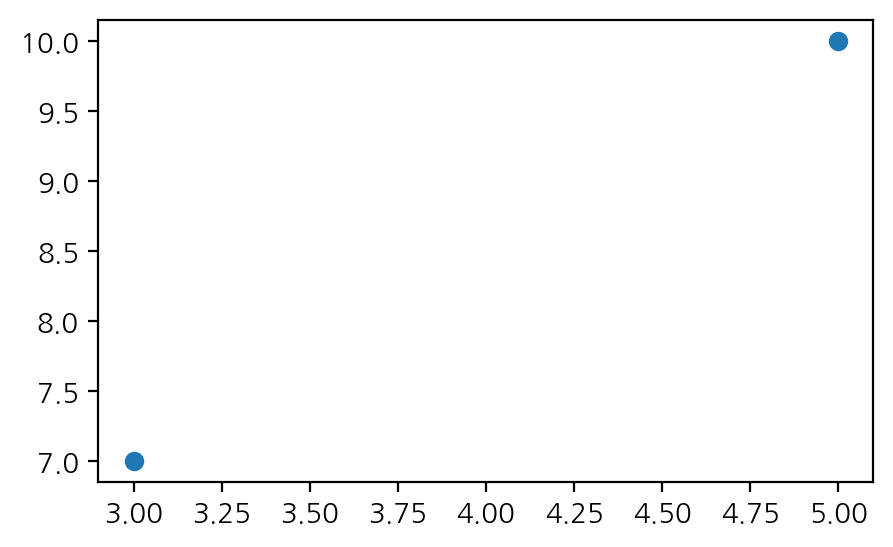

In [ ]:
# 간단한 산점도
plt.scatter([3, 5], [7, 10])
plt.show()

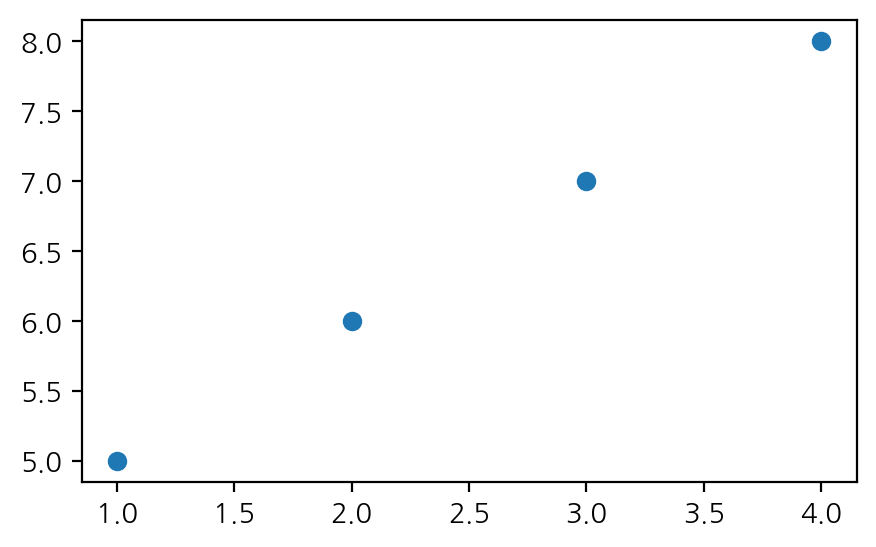

In [ ]:
# range() 결과로 산점도 그리기
plt.scatter(range(1, 5), range(5, 9))
plt.show()

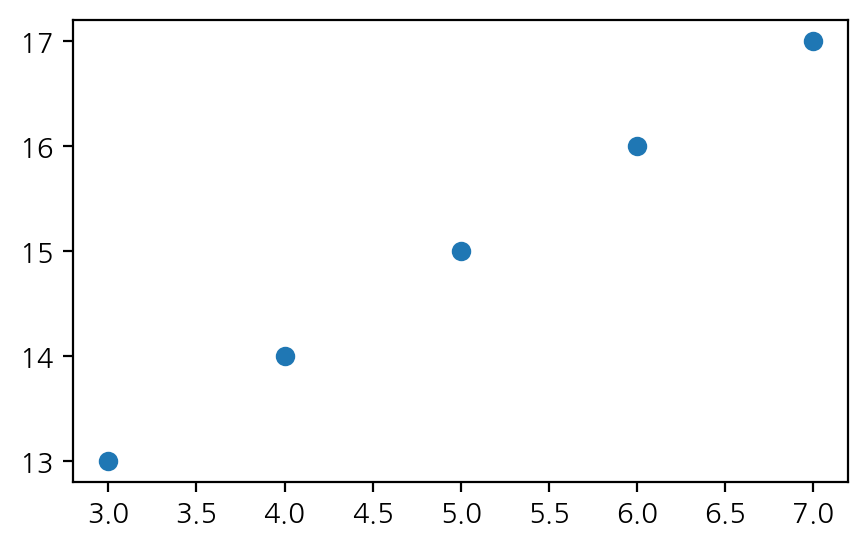

In [ ]:
# range()의 시작값을 바꿔 산점도 그리기
plt.scatter(range(3, 8), range(13, 18))
plt.show()

### ToothGrowth 데이터

In [ ]:
# ToothGrowth 데이터 불러오기
tg = data('ToothGrowth')
tg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60 entries, 1 to 60
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   len     60 non-null     float64
 1   supp    60 non-null     object 
 2   dose    60 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.9+ KB


In [ ]:
# 앞부분 확인
tg.head()

,len,supp,dose
1,4.2,VC,0.5
2,11.5,VC,0.5
3,7.3,VC,0.5
4,5.8,VC,0.5
5,6.4,VC,0.5


In [ ]:
# 기초 통계
tg.describe()

,len,dose
count,60.000000,60.000000
mean,18.813333,1.166667
std,7.649315,0.628872
min,4.200000,0.500000
25%,13.075000,0.500000
50%,19.250000,1.000000
75%,25.275000,2.000000
max,33.900000,2.000000


In [ ]:
# 보충제 종류 확인
tg.supp.value_counts()

,count
supp,
VC,30
OJ,30


In [ ]:
# 용량 수준 확인
tg.dose.value_counts()

,count
dose,
0.5,20
1.0,20
2.0,20


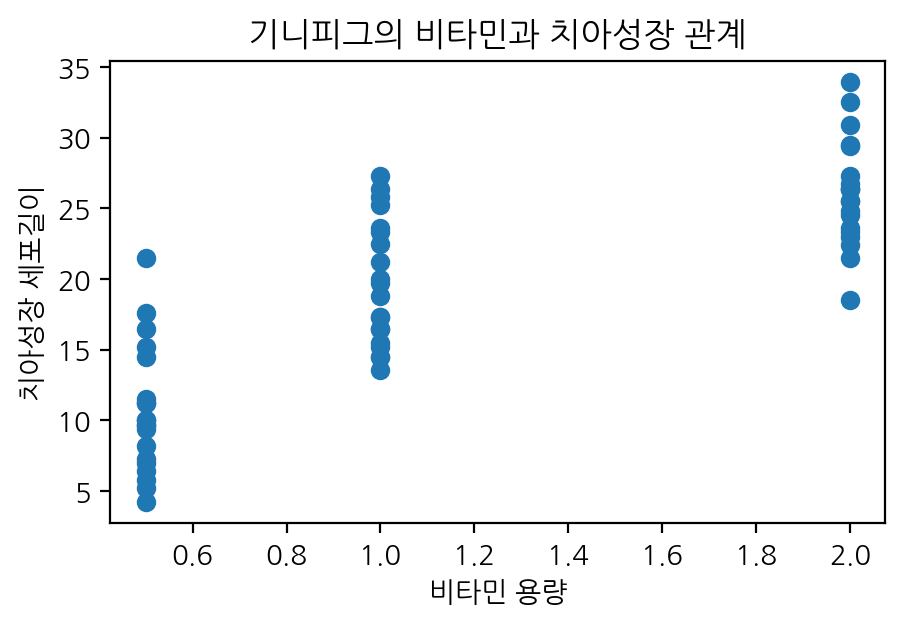

In [ ]:
# dose와 len의 관계 산점도
plt.scatter(tg.dose, tg.len)
plt.title('기니피그의 비타민과 치아성장 관계')
plt.xlabel('비타민 용량')
plt.ylabel('치아성장 세포길이')
plt.show()

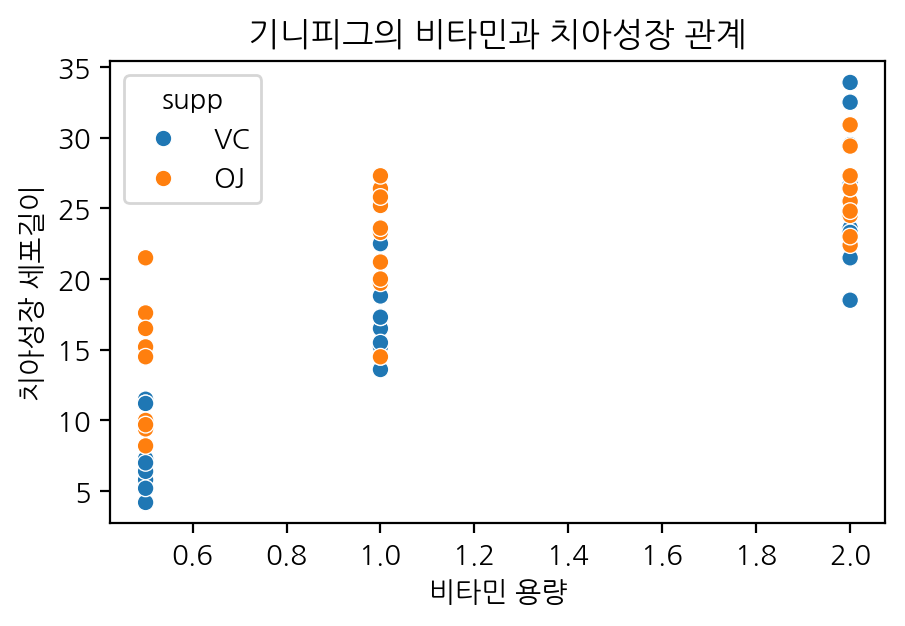

In [ ]:
# 비타민 종류에 따라 색상 구분
sns.scatterplot(data=tg, x='dose', y='len', hue='supp')
plt.title('기니피그의 비타민과 치아성장 관계')
plt.xlabel('비타민 용량')
plt.ylabel('치아성장 세포길이')
plt.show()

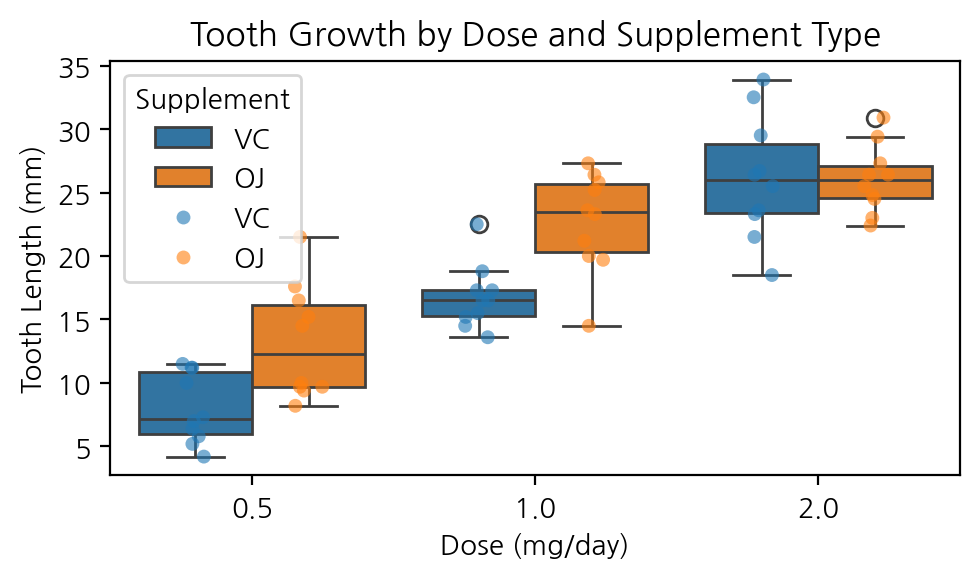

In [ ]:
# 상자그림과 점 표시
sns.boxplot(data=tg, x='dose', y='len', hue='supp')
sns.stripplot(data=tg, x='dose', y='len', hue='supp',
              dodge=True, alpha=0.6)

# sns.stripplot(data=tg, x='dose', y='len', hue='supp', alpha=0.6)

plt.title('Tooth Growth by Dose and Supplement Type')
plt.ylabel('Tooth Length (mm)')
plt.xlabel('Dose (mg/day)')
plt.legend(title='Supplement')
plt.tight_layout()
plt.show()

### 선 그래프 plot()

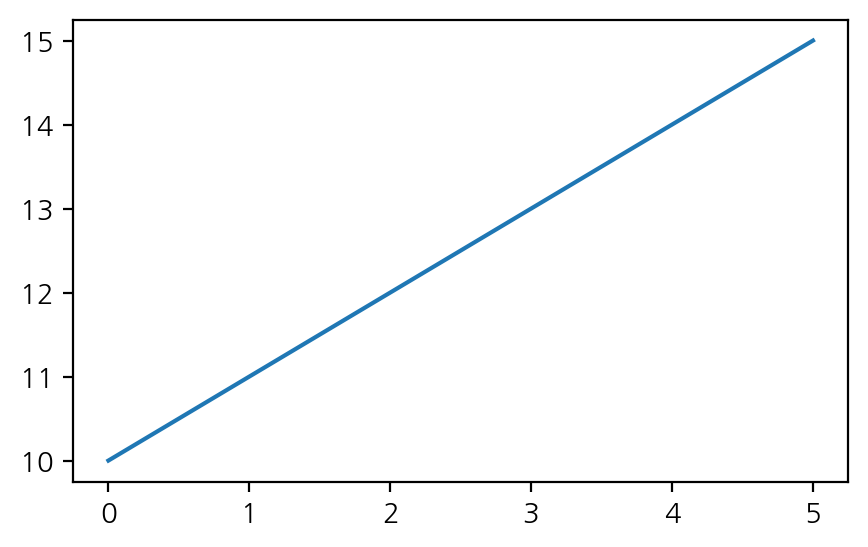

In [ ]:
# 기본 선 그래프
plt.plot(range(10, 16))
plt.show()

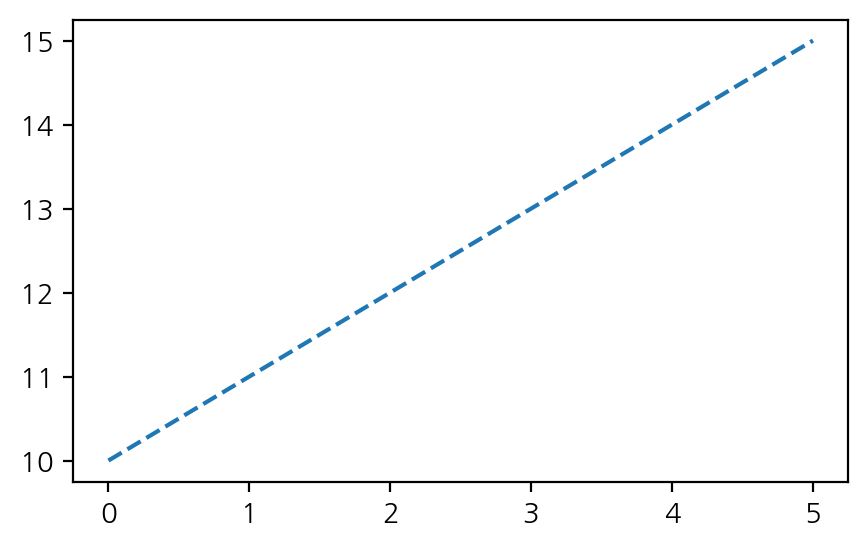

In [ ]:
# 점선 그래프
plt.plot(range(10, 16), linestyle='--')
plt.show()

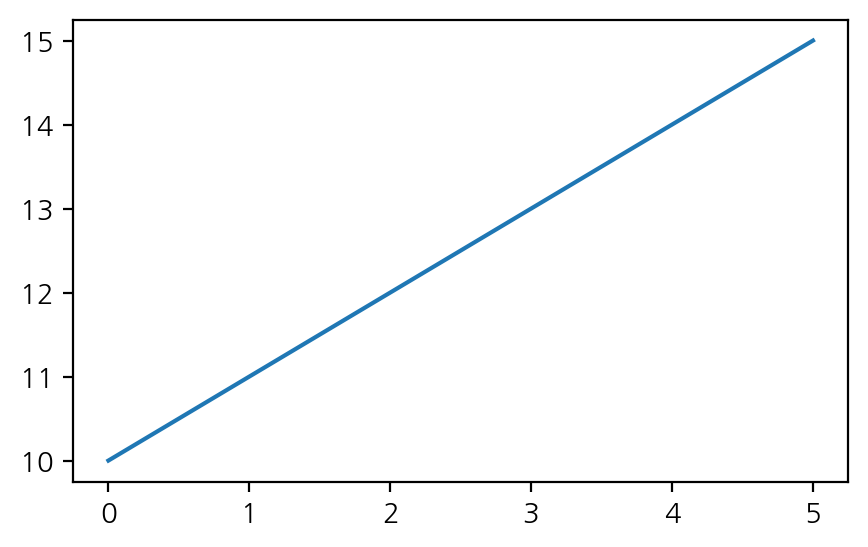

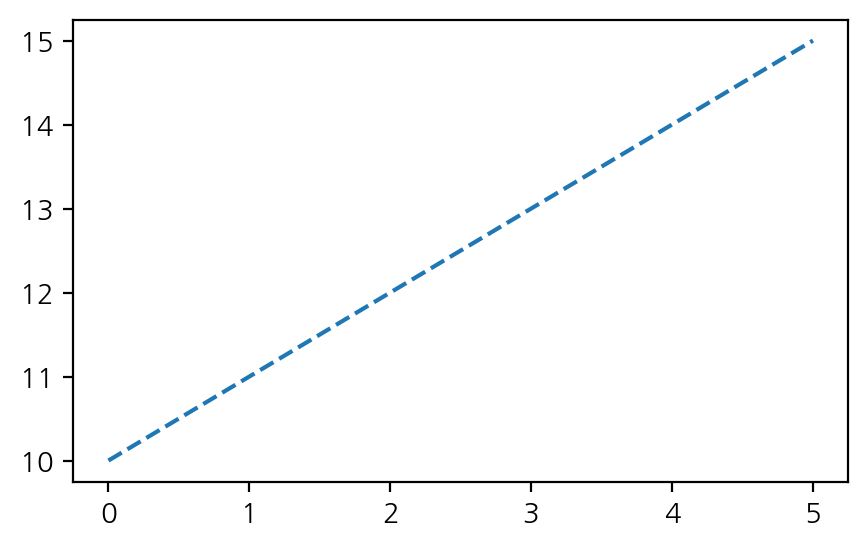

In [ ]:
# 한 셀에서 두 그래프 표시
plt.plot(range(10, 16))
plt.show()

plt.plot(range(10, 16), linestyle='--')
plt.show()

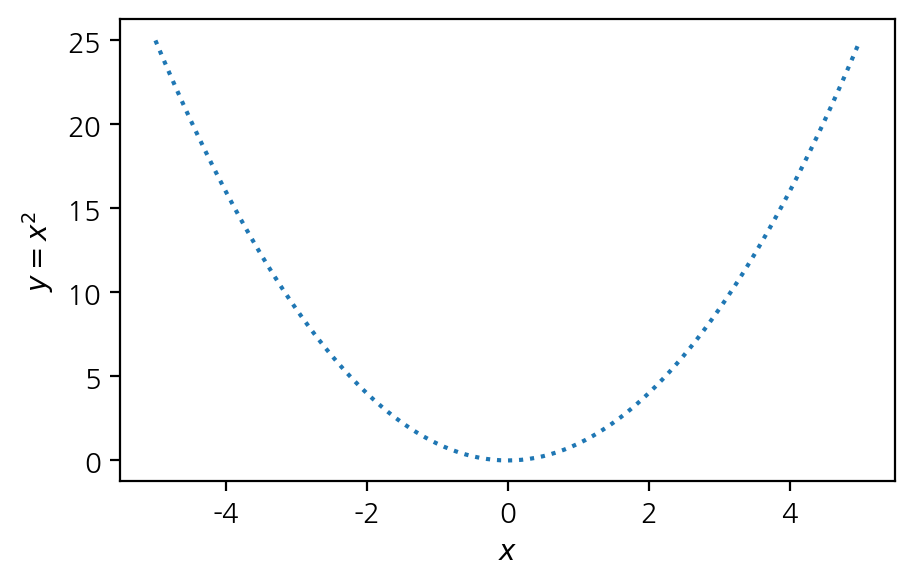

In [ ]:
# y = x^2 그래프
x = np.arange(-5, 5.1, 0.1)

plt.plot(x, x**2, ls=':')
plt.xlabel('$x$')
plt.ylabel('$y=x^2$')
plt.show()

### AirPassengers 데이터

In [ ]:
# AirPassengers 데이터 불러오기
airpsngr = data('AirPassengers')
airpsngr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 144 entries, 1 to 144
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   time           144 non-null    float64
 1   AirPassengers  144 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 3.4 KB


In [ ]:
# 앞부분 확인
airpsngr.head()

,time,AirPassengers
1,1949.000000,112
2,1949.083333,118
3,1949.166667,132
4,1949.250000,129
5,1949.333333,121


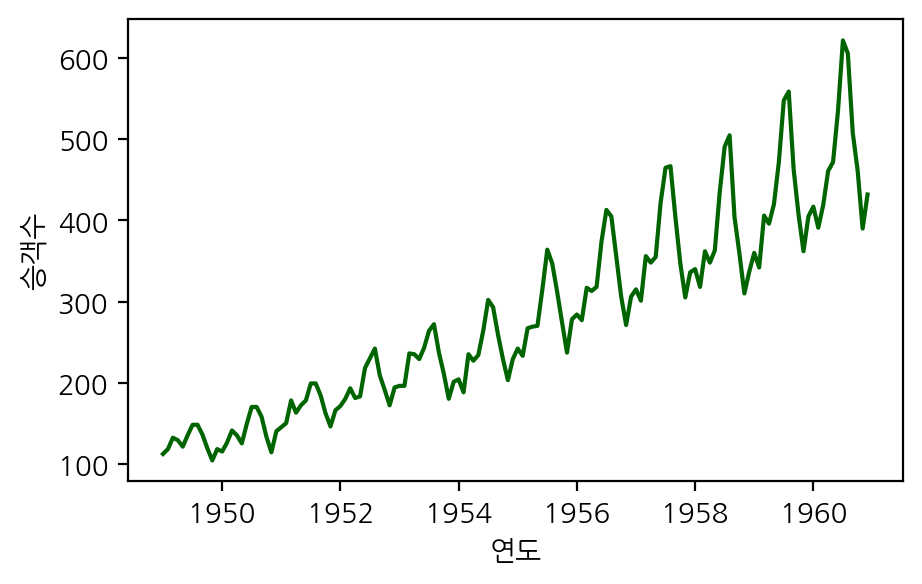

In [ ]:
# 월별 국제선 승객 수
plt.plot(airpsngr.time, airpsngr.AirPassengers, color='darkgreen')
plt.xlabel('연도')
plt.ylabel('승객수')
plt.show()

### linestyle과 marker

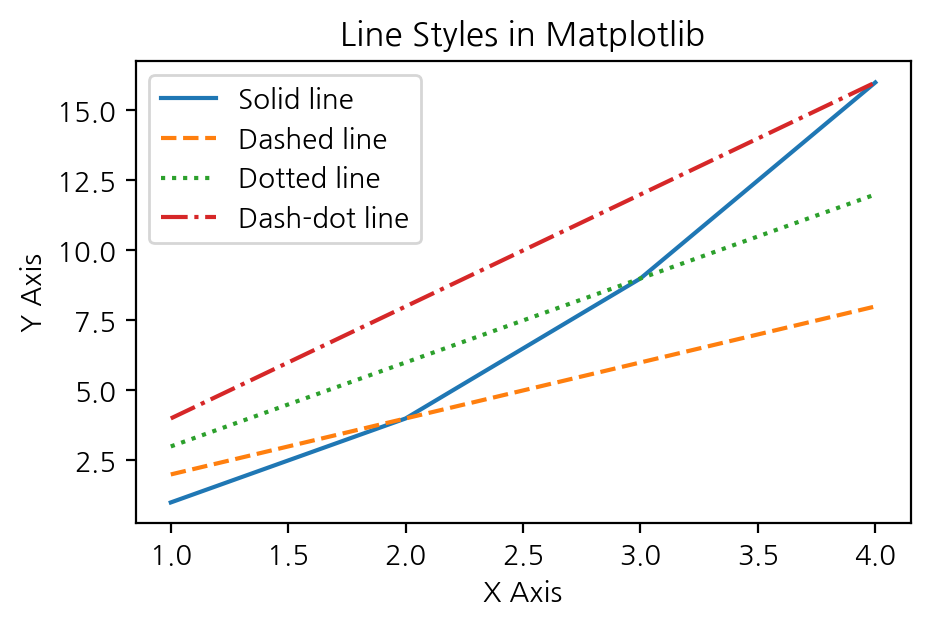

In [ ]:
# 4가지 선 종류
x = [1, 2, 3, 4]
y1 = [1, 4, 9, 16]
y2 = [2, 4, 6, 8]
y3 = [3, 6, 9, 12]
y4 = [4, 8, 12, 16]

plt.plot(x, y1, linestyle='-', label='Solid line')
plt.plot(x, y2, linestyle='--', label='Dashed line')
plt.plot(x, y3, linestyle=':', label='Dotted line')
plt.plot(x, y4, linestyle='-.', label='Dash-dot line')

plt.title('Line Styles in Matplotlib')
plt.xlabel('X Axis')
plt.ylabel('Y Axis')
plt.legend()
plt.show()

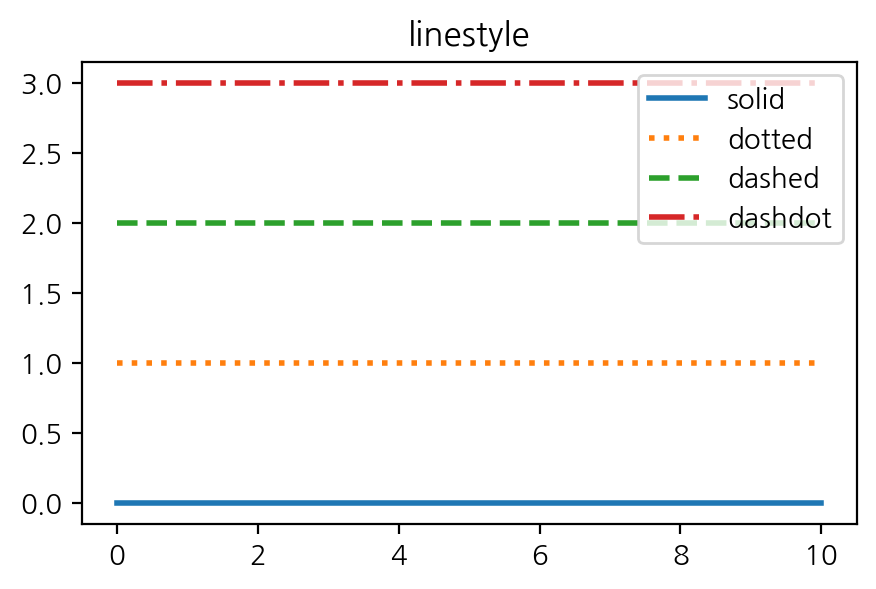

In [ ]:
# 선 종류 비교
x = np.linspace(0, 10, 100)
styles = ['solid', 'dotted', 'dashed', 'dashdot']

for i, style in enumerate(styles):
    plt.plot(x, [i] * len(x), linestyle=style, linewidth=2, label=style)

plt.title('linestyle')
plt.legend()
plt.show()

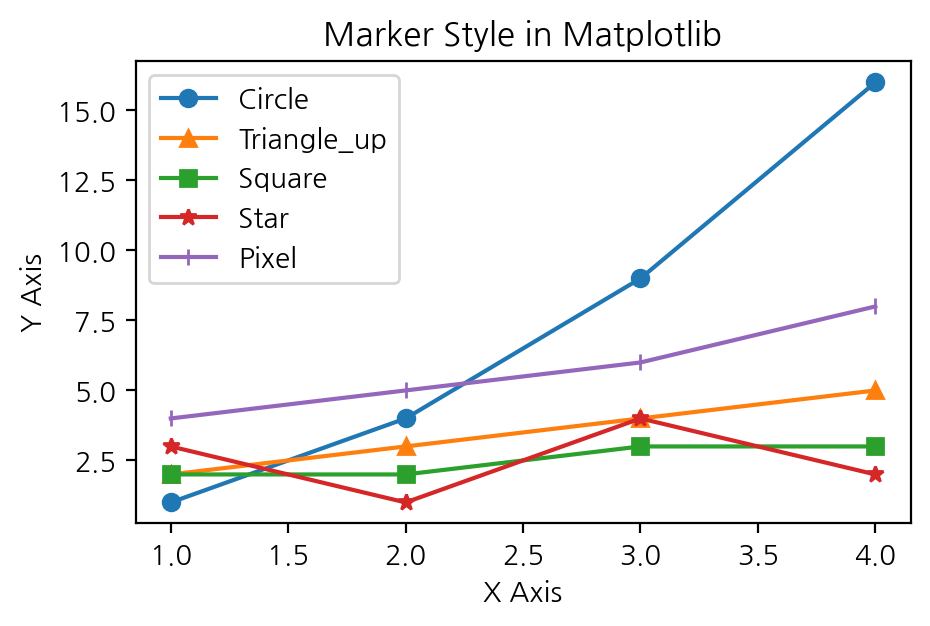

In [ ]:
# 5개 마커 사용
x = [1, 2, 3, 4]
y1 = [1, 4, 9, 16]
y2 = [2, 3, 4, 5]
y3 = [2, 2, 3, 3]
y4 = [3, 1, 4, 2]
y5 = [4, 5, 6, 8]

plt.plot(x, y1, marker='o', label='Circle')
plt.plot(x, y2, marker='^', label='Triangle_up')
plt.plot(x, y3, marker='s', label='Square')
plt.plot(x, y4, marker='*', label='Star')
plt.plot(x, y5, marker='|', label='Pixel')

plt.title('Marker Style in Matplotlib')
plt.xlabel('X Axis')
plt.ylabel('Y Axis')
plt.legend()
plt.show()

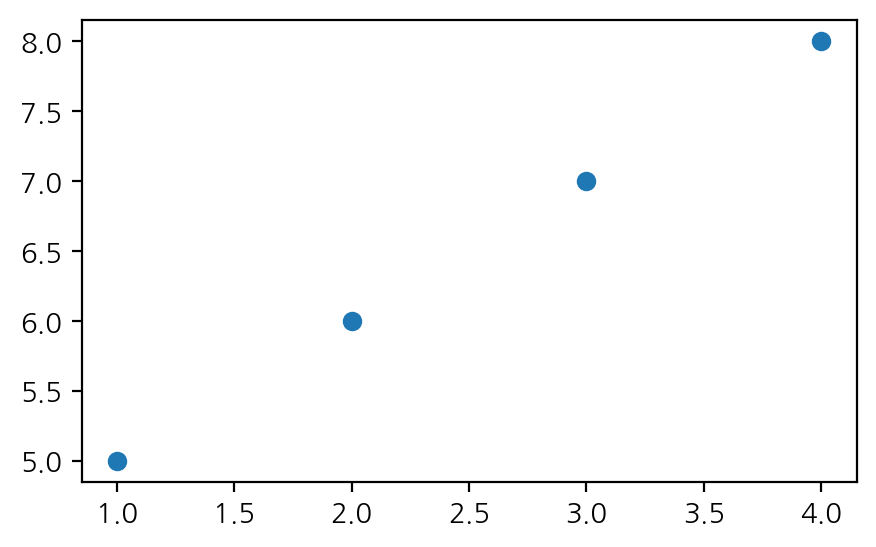

In [ ]:
# 선 없이 마커만 표시
plt.plot(range(1, 5), range(5, 9), ls=' ', marker='o')
plt.show()

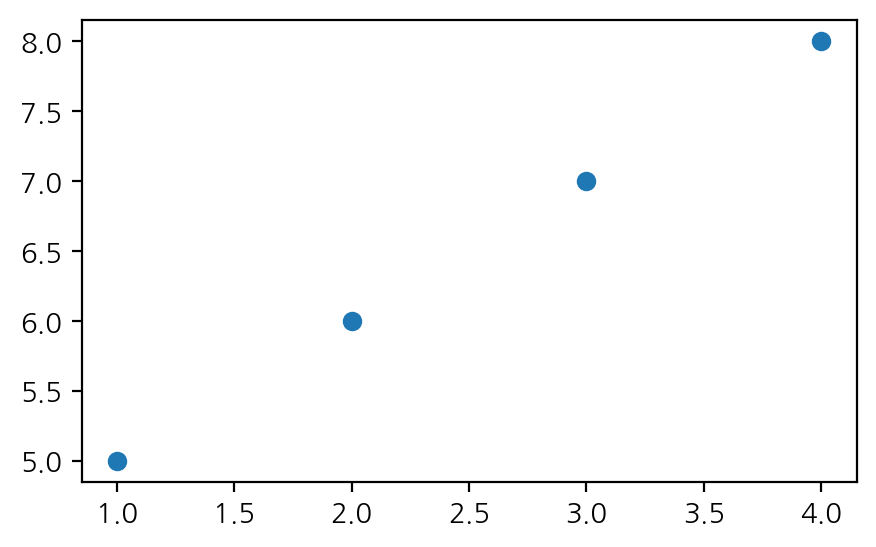

In [ ]:
# ls='' 사용
plt.plot(range(1, 5), range(5, 9), ls='', marker='o')
plt.show()

### 비타민 용량과 세포 길이

In [ ]:
# VC와 OJ 분리
vc = tg[tg.supp == "VC"][['len', 'dose']]
oj = tg[tg.supp == "OJ"][['len', 'dose']]

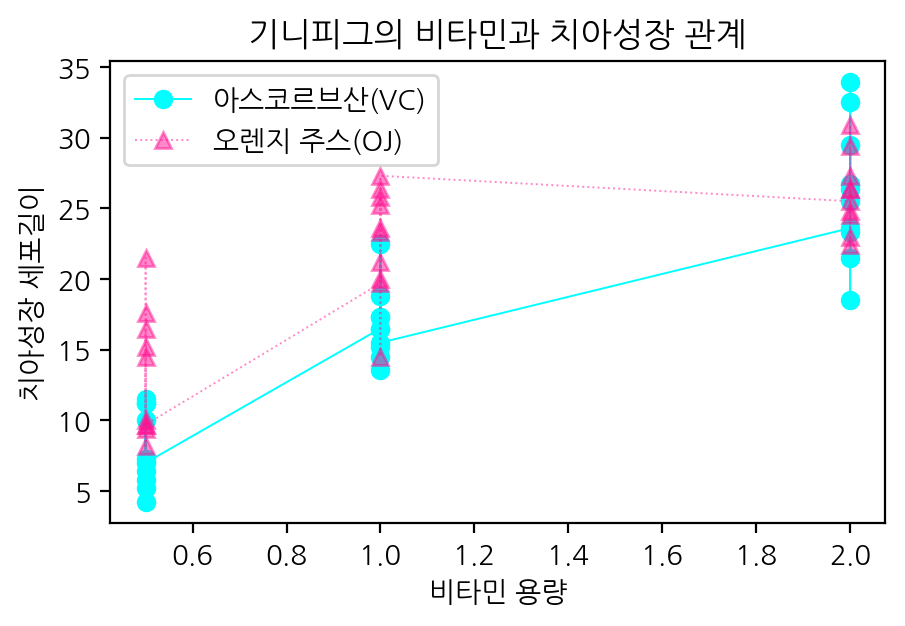

In [ ]:
# 비타민 종류별 그래프
plt.plot(vc.dose, vc.len, color='cyan', marker='o',
         label='아스코르브산(VC)', lw=.7)

plt.plot(oj.dose, oj.len, color='deeppink', marker='^',
         ls=':', label='오렌지 주스(OJ)', lw=.7, alpha=.5)

plt.title("기니피그의 비타민과 치아성장 관계")
plt.xlabel("비타민 용량")
plt.ylabel("치아성장 세포길이")
plt.legend()
plt.show()

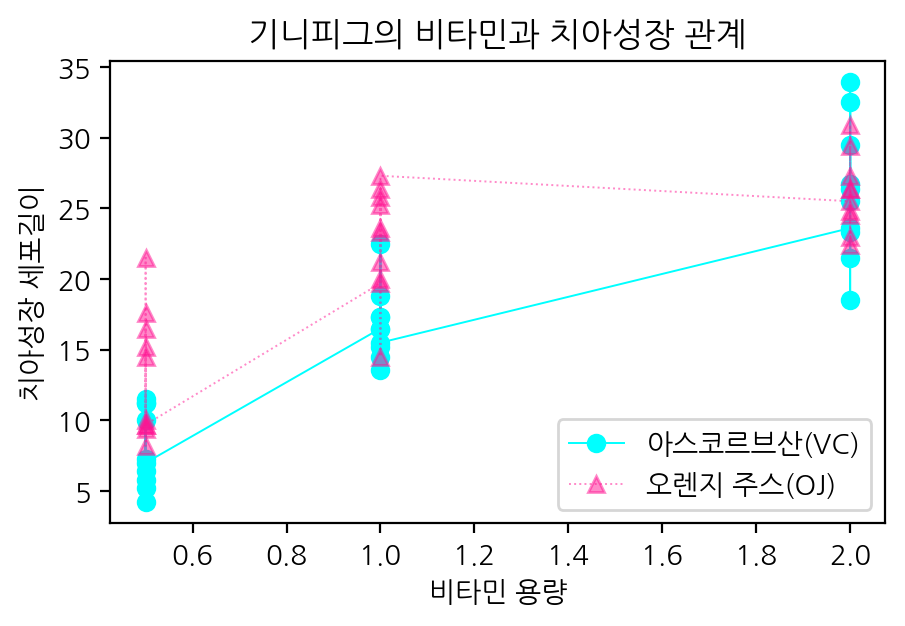

In [ ]:
# 범례 위치 지정
plt.plot(vc.dose, vc.len, color='cyan', marker='o',
         label='아스코르브산(VC)', lw=.7)

plt.plot(oj.dose, oj.len, color='deeppink', marker='^',
         ls=':', label='오렌지 주스(OJ)', lw=.7, alpha=.5)

plt.title("기니피그의 비타민과 치아성장 관계")
plt.xlabel("비타민 용량")
plt.ylabel("치아성장 세포길이")
plt.legend(loc='lower right')
plt.show()

### 막대 그래프 bar(), barh()

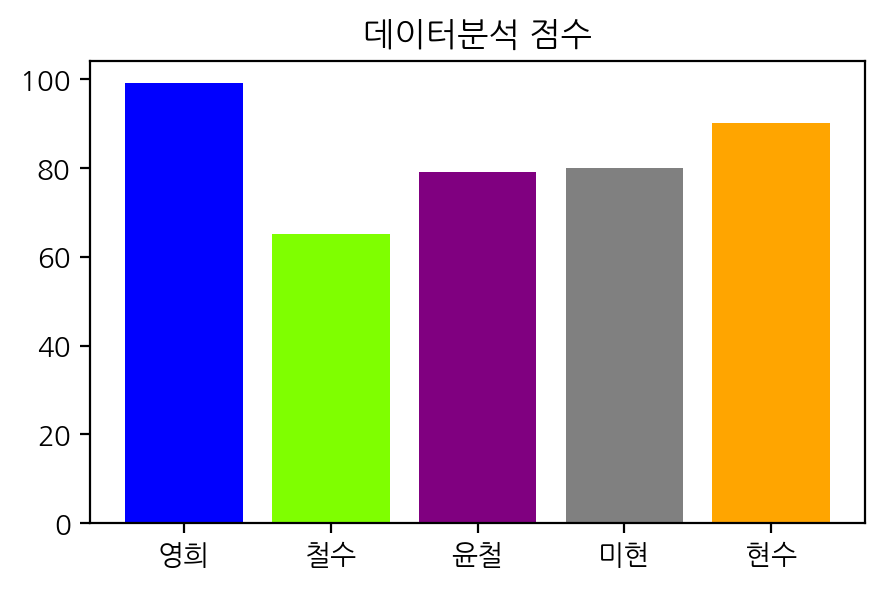

In [ ]:
# 세로 막대 그래프
point = [99, 65, 79, 80, 90]
name = ["영희", "철수", "윤철", "미현", "현수"]

plt.bar(name, point,
        color=["blue", "chartreuse", "purple", "grey", "orange"])
plt.title('데이터분석 점수')
plt.show()

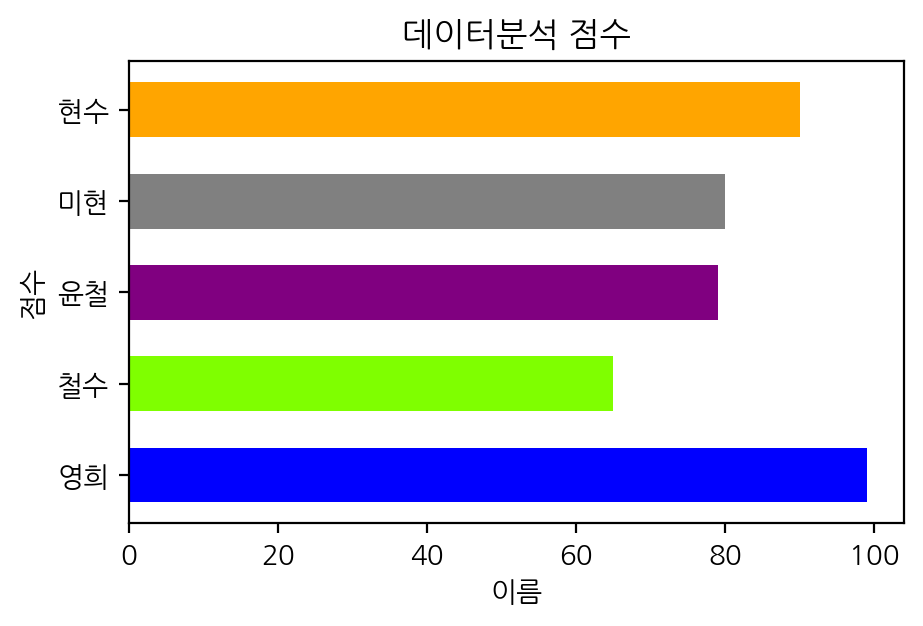

In [ ]:
# 가로 막대 그래프
plt.barh(name, point, height=.6,
         color=["blue", "chartreuse", "purple", "grey", "orange"])
plt.title('데이터분석 점수')
plt.xlabel('이름')
plt.ylabel('점수')
plt.show()

### LifeCycleSavings 데이터

In [ ]:
# LifeCycleSavings 데이터 불러오기
lcs = data('LifeCycleSavings')
lcs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, Australia to Malaysia
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sr      50 non-null     float64
 1   pop15   50 non-null     float64
 2   pop75   50 non-null     float64
 3   dpi     50 non-null     float64
 4   ddpi    50 non-null     float64
dtypes: float64(5)
memory usage: 2.3+ KB


In [ ]:
# 앞부분 확인
lcs.head()

,sr,pop15,pop75,dpi,ddpi
Australia,11.43,29.35,2.87,2329.68,2.87
Austria,12.07,23.32,4.41,1507.99,3.93
Belgium,13.17,23.80,4.43,2108.47,3.82
Bolivia,5.75,41.89,1.67,189.13,0.22
Brazil,12.88,42.19,0.83,728.47,4.56


In [ ]:
# 기초 통계
lcs.describe()

,sr,pop15,pop75,dpi,ddpi
count,50.000000,50.000000,50.000000,50.000000,50.000000
mean,9.671000,35.089600,2.293000,1106.758400,3.757600
std,4.480407,9.151727,1.290771,990.868889,2.869871
min,0.600000,21.440000,0.560000,88.940000,0.220000
25%,6.970000,26.215000,1.125000,288.207500,2.002500
50%,10.510000,32.575000,2.175000,695.665000,3.000000
75%,12.617500,44.065000,3.325000,1795.622500,4.477500
max,21.100000,47.640000,4.700000,4001.890000,16.710000


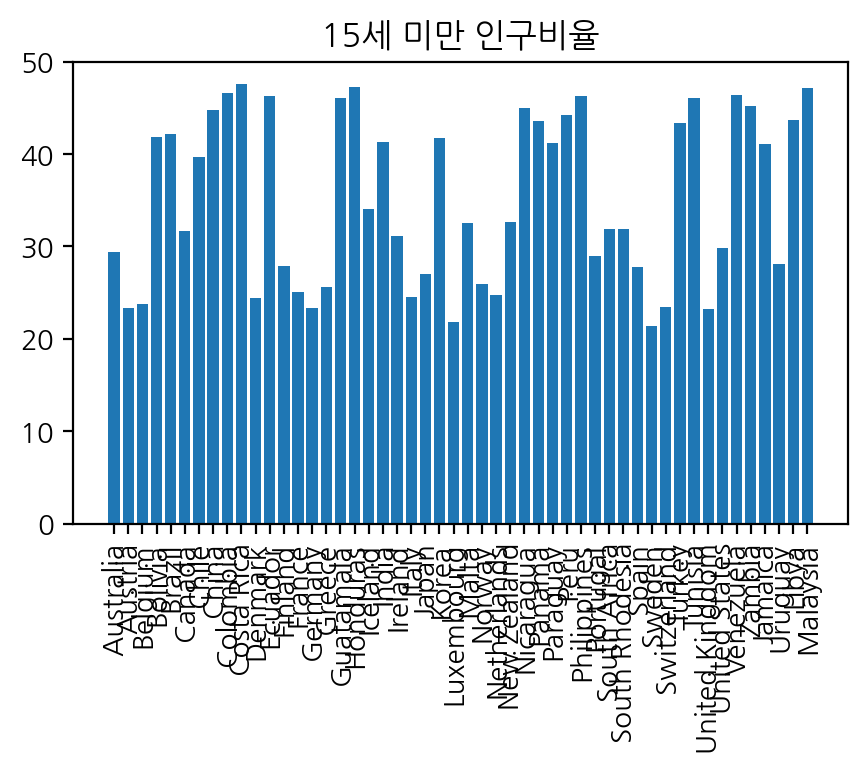

In [ ]:
# pop15 막대 그래프
plt.bar(lcs.index, lcs.pop15)
plt.title("15세 미만 인구비율")
plt.xticks(rotation=90)
plt.show()

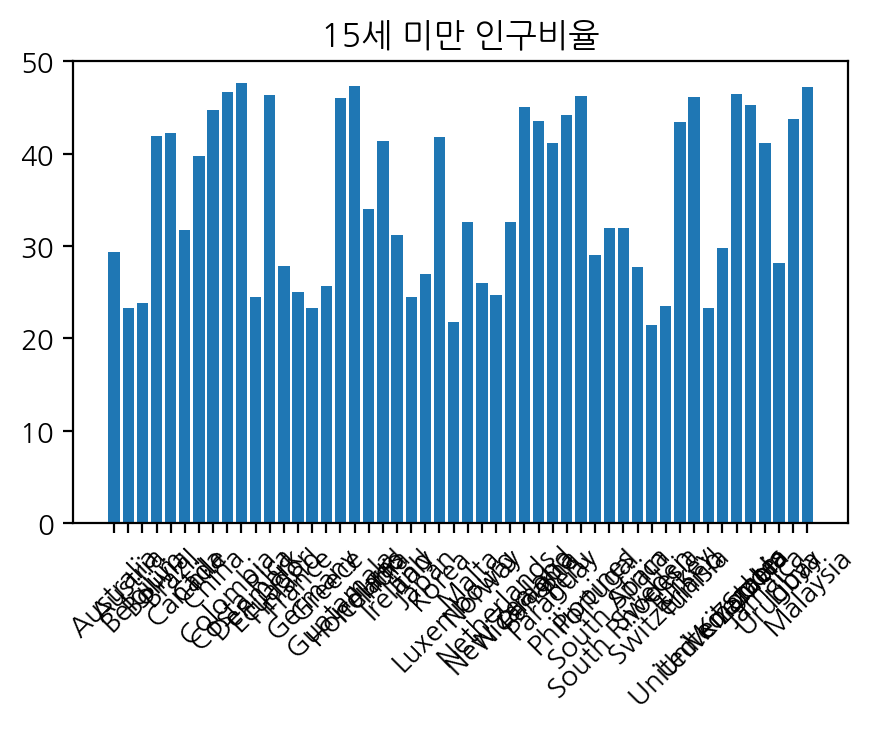

In [ ]:
# pop15 막대 그래프
plt.bar(lcs.index, lcs.pop15)
plt.title("15세 미만 인구비율")
plt.xticks(rotation=45)
plt.show()

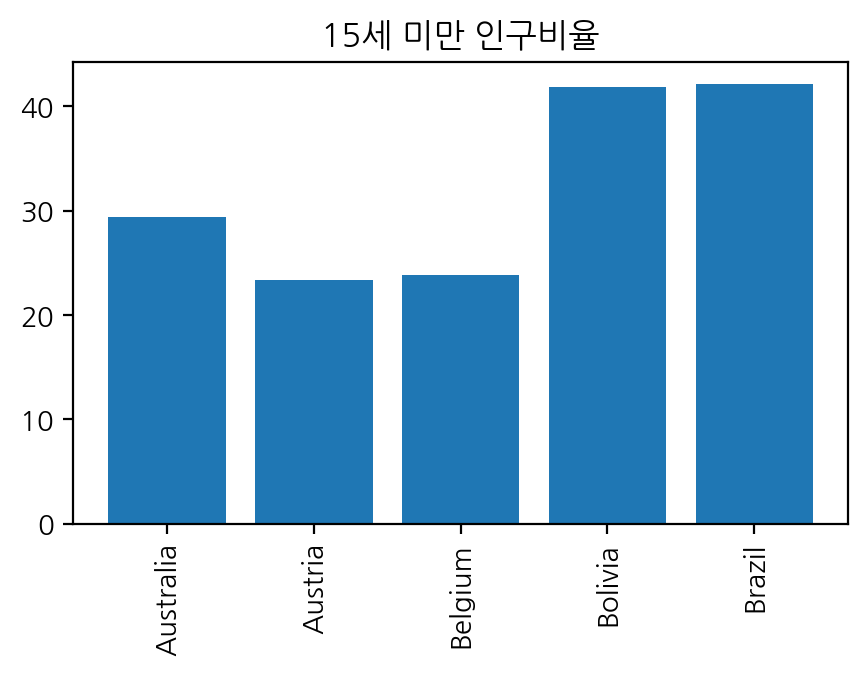

In [135]:
# 앞부분 일부만 막대 그래프로 확인
lcs5 = lcs.head()
plt.bar(lcs5.index, lcs5.pop15)
plt.title("15세 미만 인구비율")
plt.xticks(rotation=90)
plt.show()

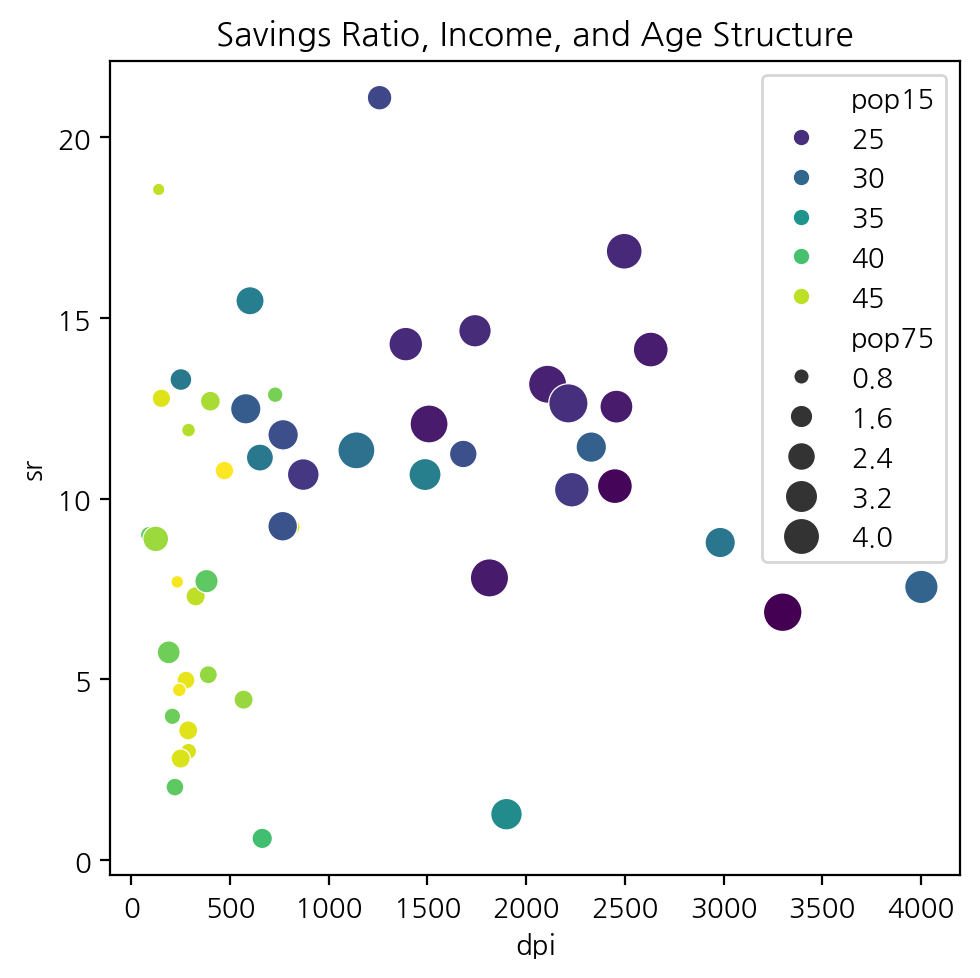

In [ ]:
# 저축률, 소득, 연령 구조 시각화
plt.figure(figsize=(5, 5))

sns.scatterplot(data=lcs, x='dpi', y='sr', hue='pop15',
                palette='viridis', size='pop75', sizes=(20, 200))

plt.title('Savings Ratio, Income, and Age Structure')
plt.xlabel('dpi')
plt.ylabel('sr')
plt.tight_layout()
plt.show()

### mtcars 데이터와 막대 그래프

In [ ]:
# mtcars 데이터 불러오기
mtc = data('mtcars')
mtc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, Mazda RX4 to Volvo 142E
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mpg     32 non-null     float64
 1   cyl     32 non-null     int64  
 2   disp    32 non-null     float64
 3   hp      32 non-null     int64  
 4   drat    32 non-null     float64
 5   wt      32 non-null     float64
 6   qsec    32 non-null     float64
 7   vs      32 non-null     int64  
 8   am      32 non-null     int64  
 9   gear    32 non-null     int64  
 10  carb    32 non-null     int64  
dtypes: float64(5), int64(6)
memory usage: 3.0+ KB


In [ ]:
# 앞부분과 뒷부분 확인
display_side_by_side(mtc.head(), mtc.tail())

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Lotus Europa,30.4,4,95.1,113,3.77,1.513,16.9,1,1,5,2
Ford Pantera L,15.8,8,351.0,264,4.22,3.170,14.5,0,1,5,4
Ferrari Dino,19.7,6,145.0,175,3.62,2.770,15.5,0,1,5,6
Maserati Bora,15.0,8,301.0,335,3.54,3.570,14.6,0,1,5,8


In [ ]:
# cyl 빈도수
mtc.cyl.value_counts()

,count
cyl,
8,14
4,11
6,7


In [ ]:
# cyl 빈도수 정렬
mtc.cyl.value_counts().sort_index()

,count
cyl,
4,11
6,7
8,14


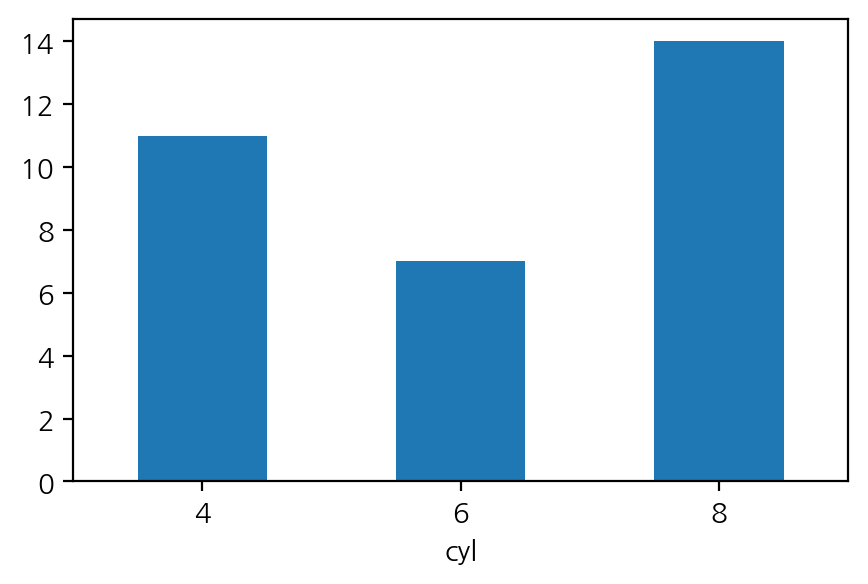

In [ ]:
# value_counts() 결과로 막대 그래프
mtc.cyl.value_counts().sort_index().plot.bar()
plt.xticks(rotation=360)
plt.show()

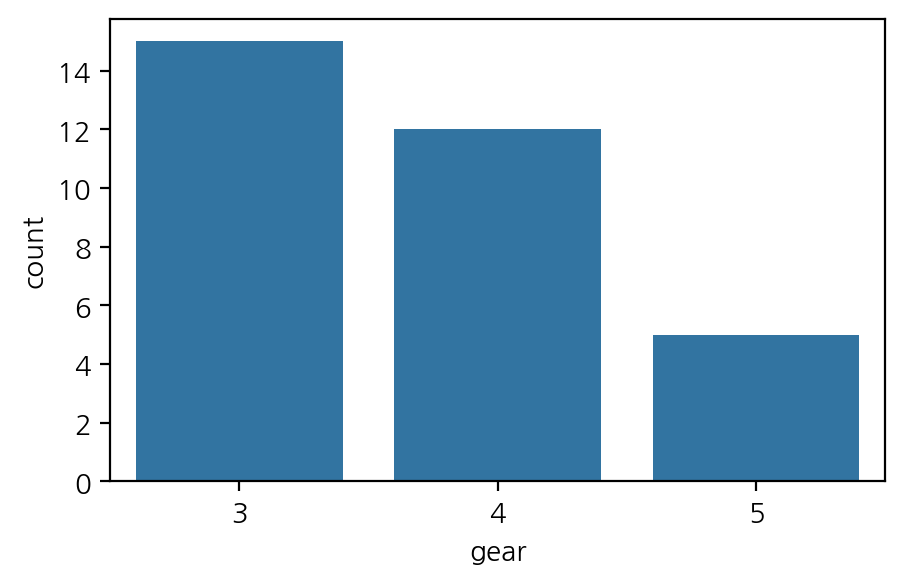

In [ ]:
# seaborn countplot
sns.countplot(mtc, x='gear')
plt.show()

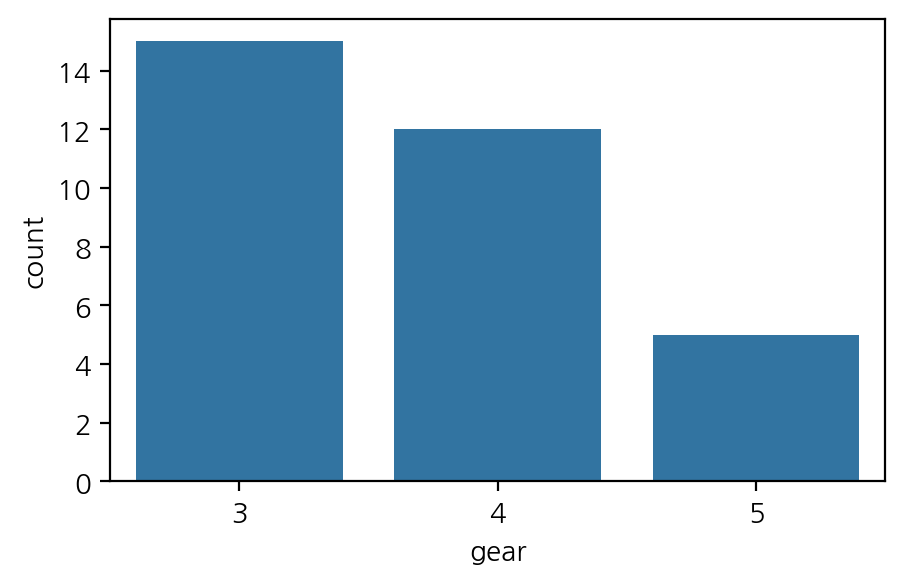

In [ ]:
# countplot 반환 객체 활용
ax = sns.countplot(data=mtc, x='gear')
plt.show()

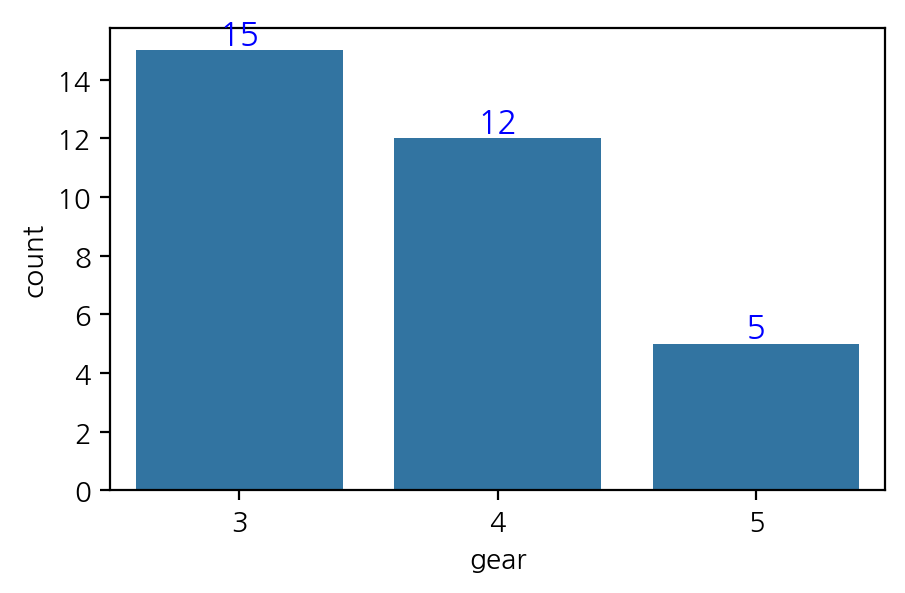

In [ ]:
# 빈도수 값을 막대 위에 표시
ax = sns.countplot(data=mtc, x='gear')

for p in ax.patches:
    height = p.get_height()
    ax.text(x=(p.get_x() + p.get_width() / 2.),
            y=(height + .2),
            s=int(height),
            ha='center',
            size=12,
            color='blue')

plt.show()

## 9.2 상자그림과 히스토그램

### 사분위수와 상자그림

In [ ]:
# mpg 사분위수
mtc.mpg.quantile([0., .25, .50, .75, 1])

,mpg
0.00,10.400
0.25,15.425
0.50,19.200
0.75,22.800
1.00,33.900


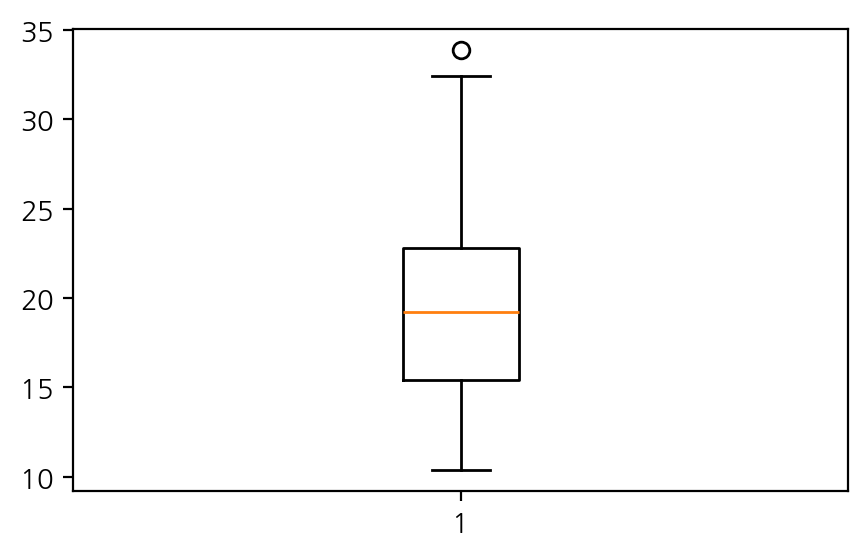

In [ ]:
# mpg 상자그림
plt.boxplot(mtc.mpg)
plt.show()

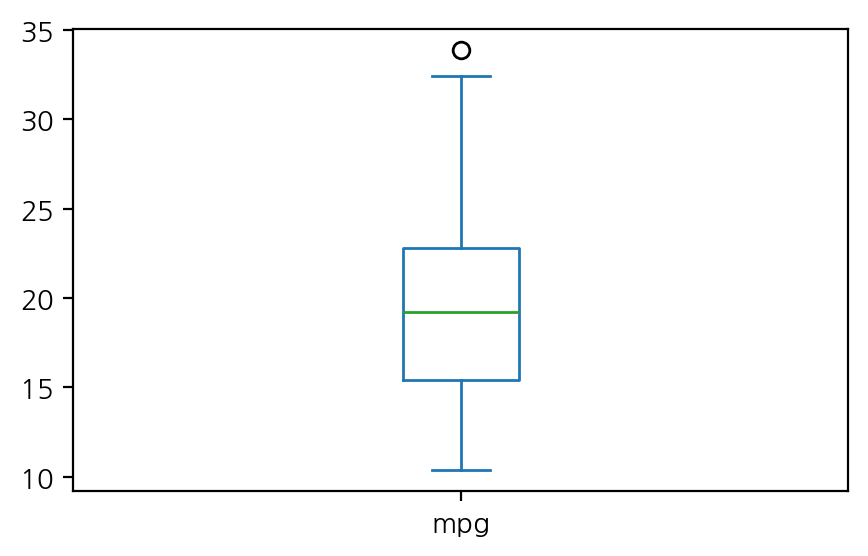

In [ ]:
# plot.box()
mtc.mpg.plot.box()
plt.show()

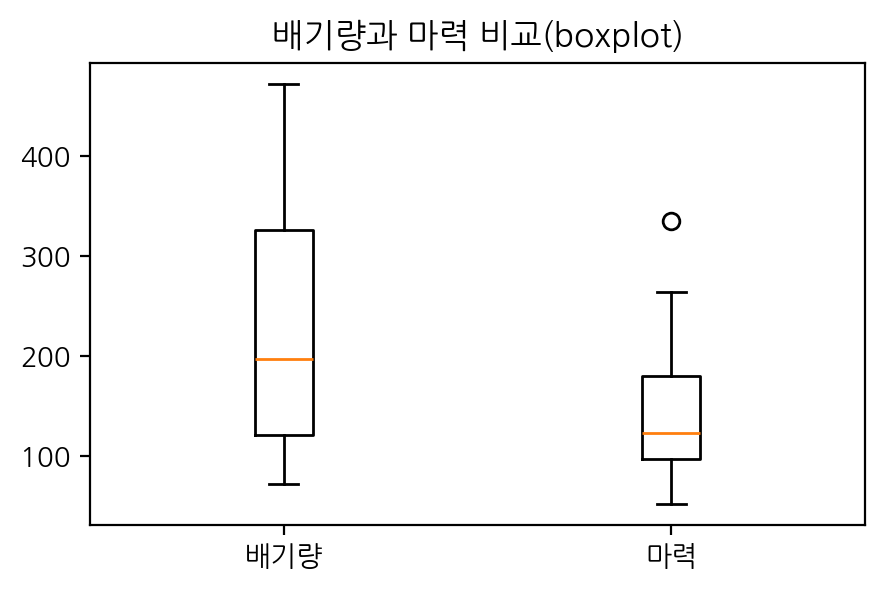

In [ ]:
# disp와 hp 상자그림
plt.boxplot([mtc.disp, mtc.hp])
plt.title("배기량과 마력 비교(boxplot)")
plt.xticks(ticks=np.arange(1, 3), labels=["배기량", "마력"])
plt.show()

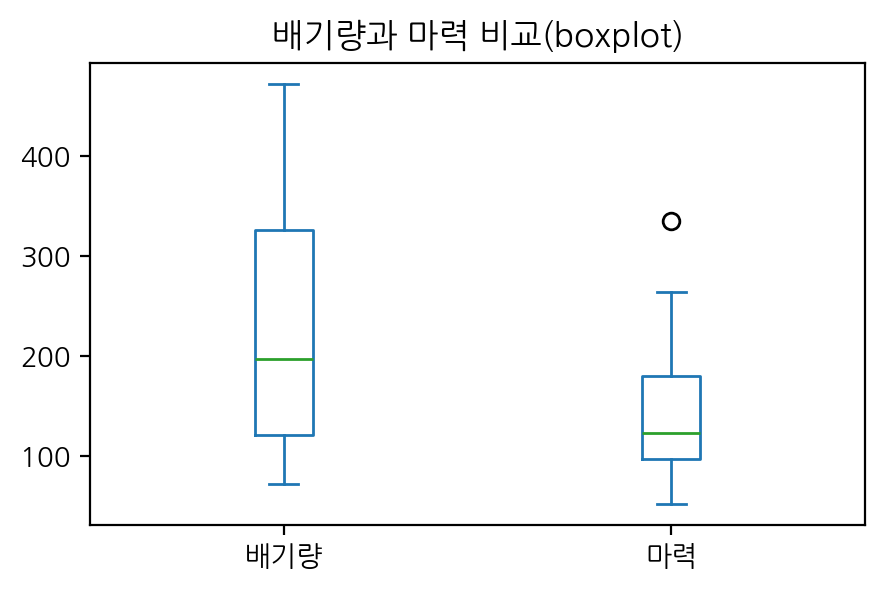

In [ ]:
# DataFrame plot으로 상자그림
mtc[['disp', 'hp']].plot(title="배기량과 마력 비교(boxplot)", kind='box')
plt.xticks(ticks=np.arange(1, 3), labels=["배기량", "마력"])
plt.show()

### 히스토그램 hist()

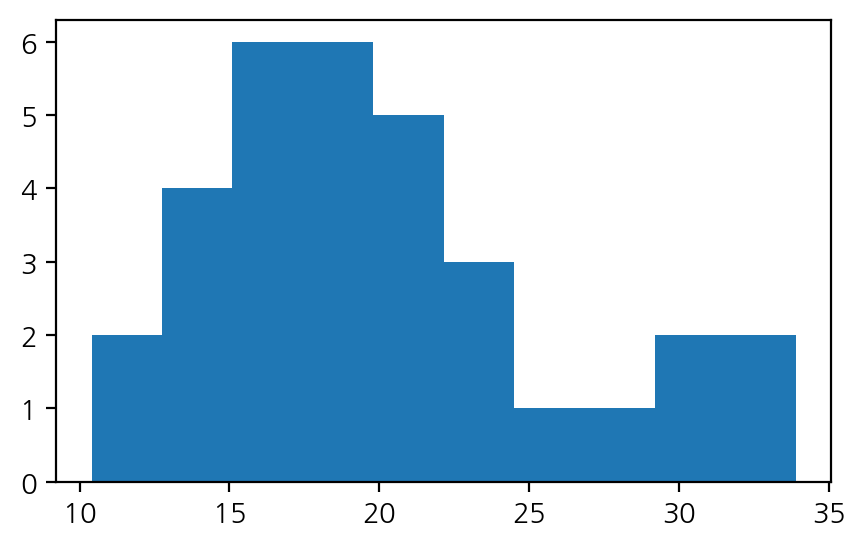

In [ ]:
# mpg 히스토그램
plt.hist(mtc.mpg)
plt.show()

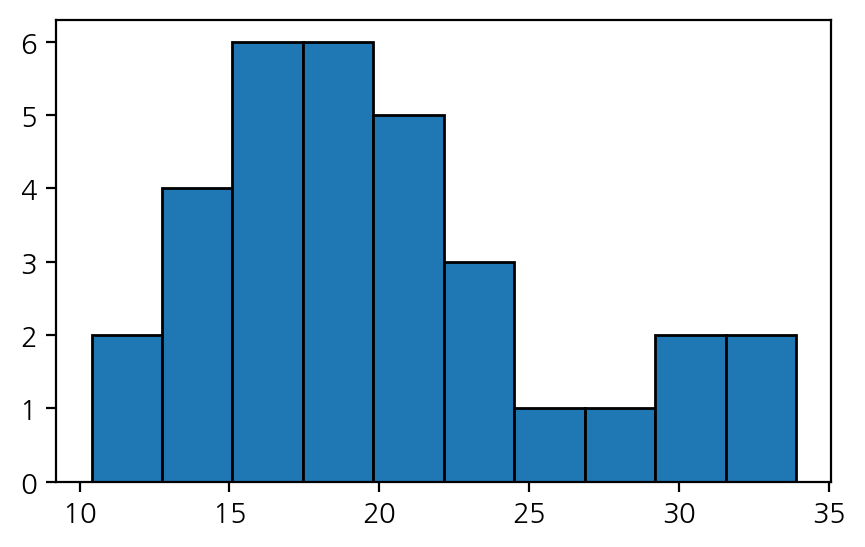

In [ ]:
# edgecolor 지정
plt.hist(mtc.mpg, edgecolor='black')
plt.show()

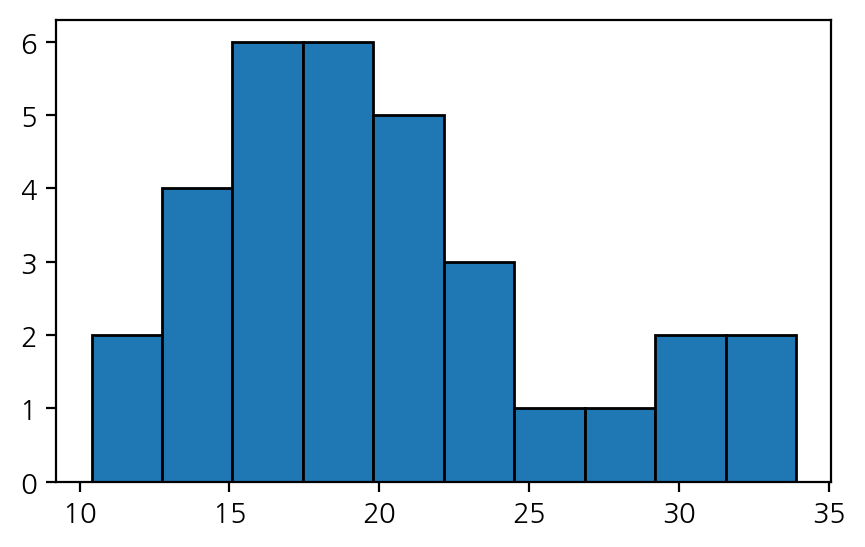

In [ ]:
# 세미콜론 사용
plt.hist(mtc.mpg, edgecolor='black');

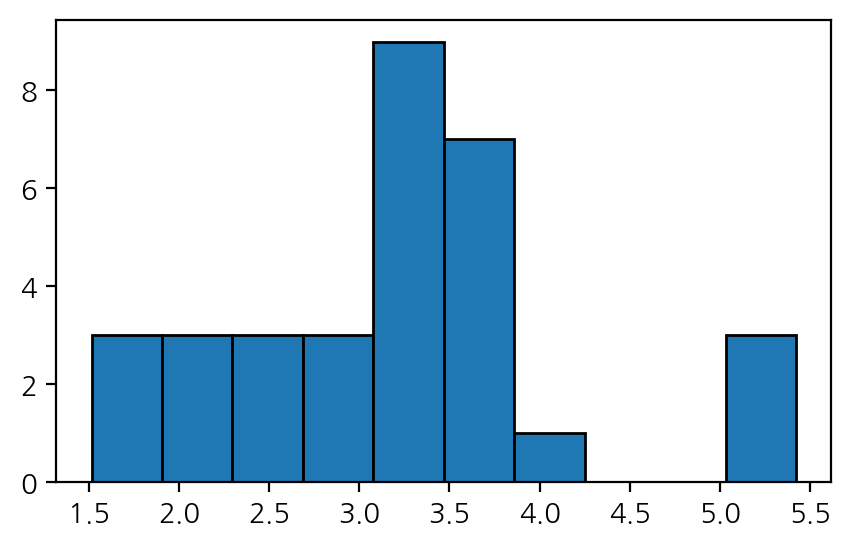

In [ ]:
# wt 히스토그램
plt.hist(mtc.wt, edgecolor='black')
plt.show()

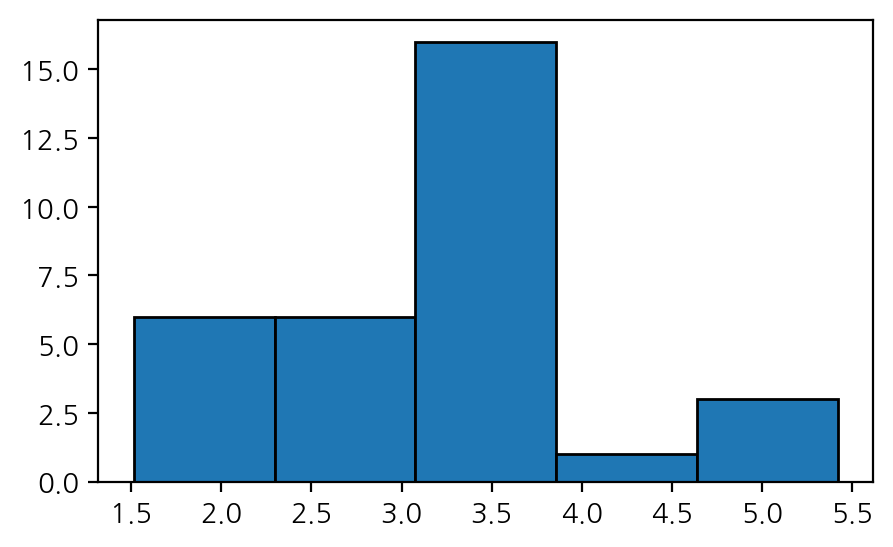

In [ ]:
# wt 히스토그램 bins=5
plt.hist(mtc.wt, bins=5, edgecolor='black')
plt.show()

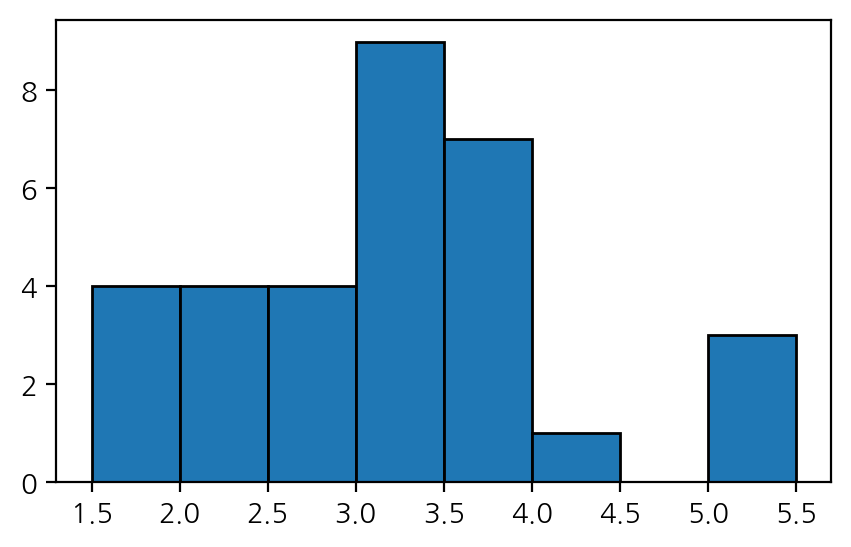

In [ ]:
# bins 직접 지정
plt.hist(mtc.wt, bins=np.arange(1.5, 5.6, 0.5), edgecolor='black')
plt.show()

In [ ]:
# bins 배열 확인
np.arange(1.5, 5.6, 0.5)

array([1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5])

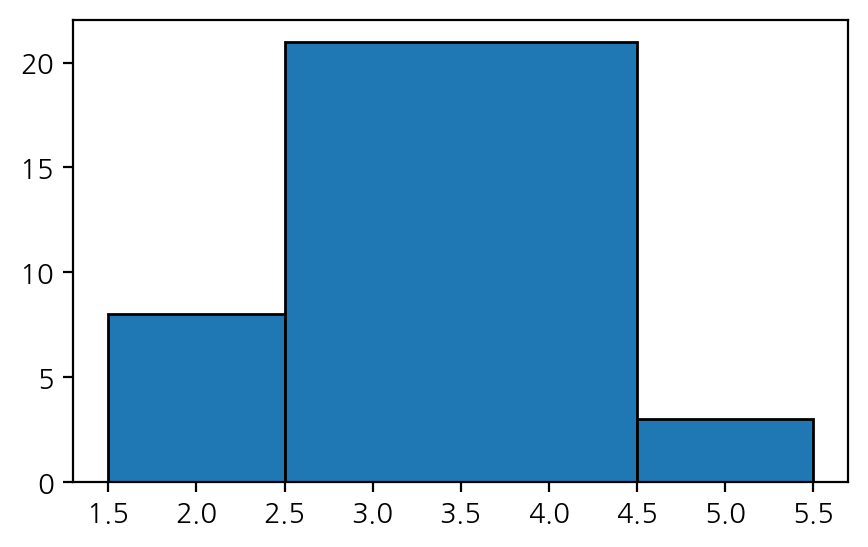

In [ ]:
# 간격이 일정하지 않은 bins
plt.hist(mtc.wt, bins=[1.5, 2.5, 4.5, 5.5], edgecolor='black')
plt.show()

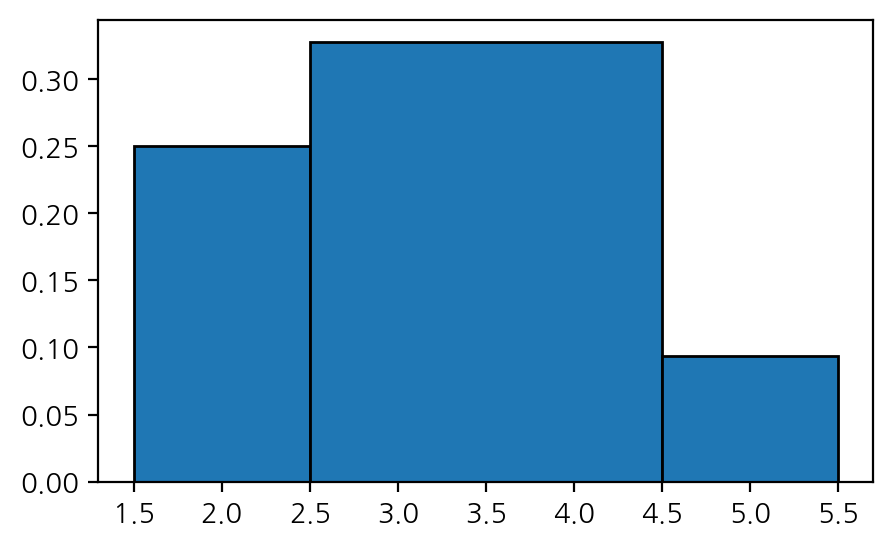

In [ ]:
# density=True
plt.hist(mtc.wt, bins=[1.5, 2.5, 4.5, 5.5],
         density=True, edgecolor='black')
plt.show()

### iris 히스토그램과 밀도

In [ ]:
# iris 품종 확인
iris.Species.unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [ ]:
# iris 정보 확인
iris.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 1 to 150
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal.Length  150 non-null    float64
 1   Sepal.Width   150 non-null    float64
 2   Petal.Length  150 non-null    float64
 3   Petal.Width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 7.0+ KB


[ 4.  5.  7. 16.  9.  5. 13. 14. 10.  6. 10. 16.  7. 11.  4.  2.  4.  1.
  5.  1.]
[4.3  4.48 4.66 4.84 5.02 5.2  5.38 5.56 5.74 5.92 6.1  6.28 6.46 6.64
 6.82 7.   7.18 7.36 7.54 7.72 7.9 ]
<BarContainer object of 20 artists>


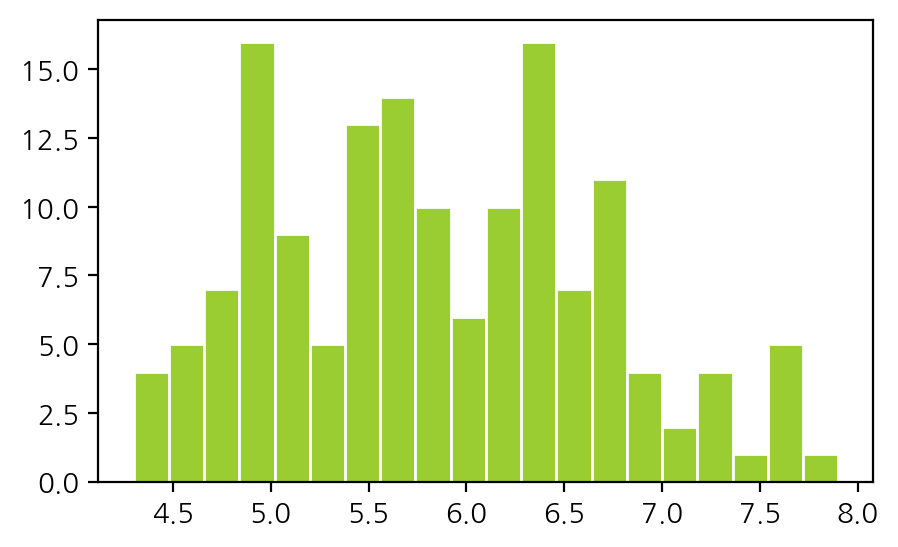

In [ ]:
# hist 반환 값 처리
n, bins, patches = plt.hist(iris['Sepal.Length'],
                            bins=20,
                            color='yellowgreen',
                            edgecolor='white')
print(n)
print(bins)
print(patches)
plt.show()

In [ ]:
# n 확인
n

array([ 4.,  5.,  7., 16.,  9.,  5., 13., 14., 10.,  6., 10., 16.,  7.,
       11.,  4.,  2.,  4.,  1.,  5.,  1.])

In [ ]:
# bins 확인
bins

array([4.3 , 4.48, 4.66, 4.84, 5.02, 5.2 , 5.38, 5.56, 5.74, 5.92, 6.1 ,
       6.28, 6.46, 6.64, 6.82, 7.  , 7.18, 7.36, 7.54, 7.72, 7.9 ])

In [ ]:
# patches 확인
patches

<BarContainer object of 20 artists>

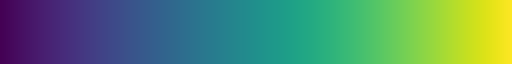

In [ ]:
# viridis 색상맵
plt.cm.viridis

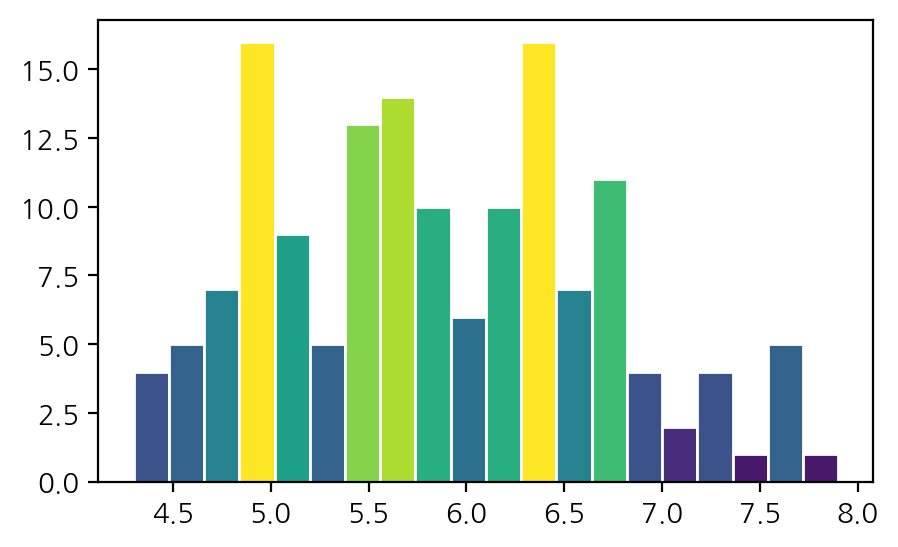

In [ ]:
# 값에 따라 막대 색상 수정
n, bins, patches = plt.hist(iris['Sepal.Length'],
                            bins=20,
                            color='yellowgreen',
                            edgecolor='white')

for i in range(len(patches)):
    patches[i].set_facecolor(plt.cm.viridis(n[i] / max(n)))

plt.show()

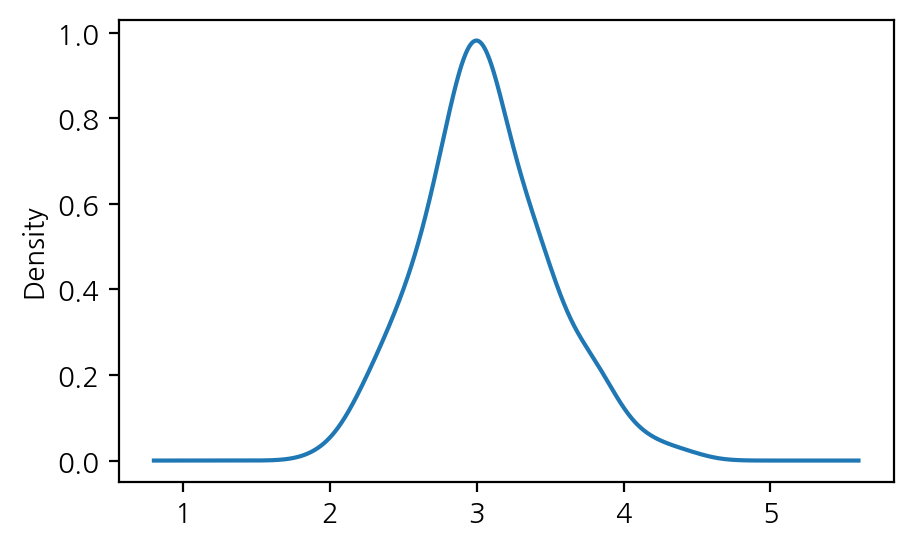

In [ ]:
# density 그래프
iris['Sepal.Width'].plot.density()
plt.show()

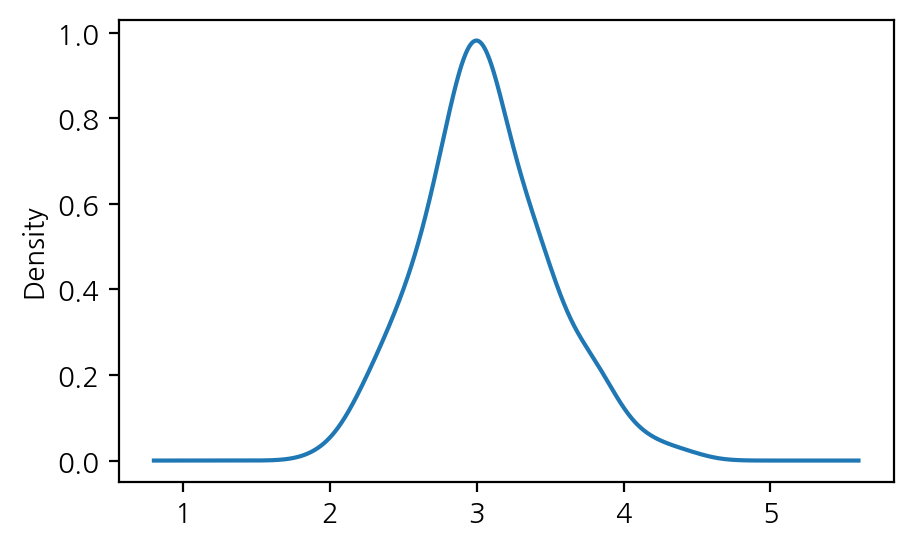

In [ ]:
# kde 그래프
iris['Sepal.Width'].plot.kde()
plt.show()

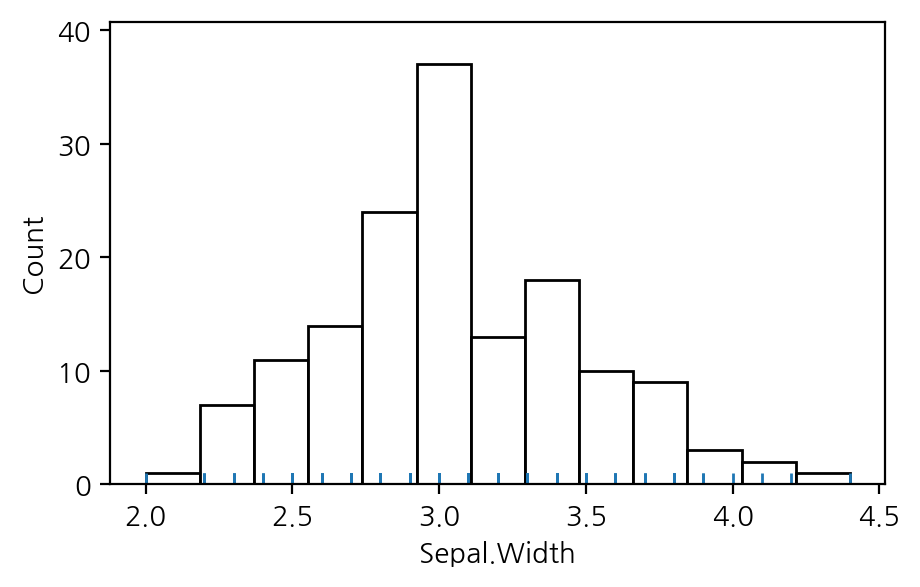

In [ ]:
# histplot과 rugplot
sns.histplot(data=iris, x=iris['Sepal.Width'], color='white')
sns.rugplot(data=iris, x=iris['Sepal.Width'])
plt.show()

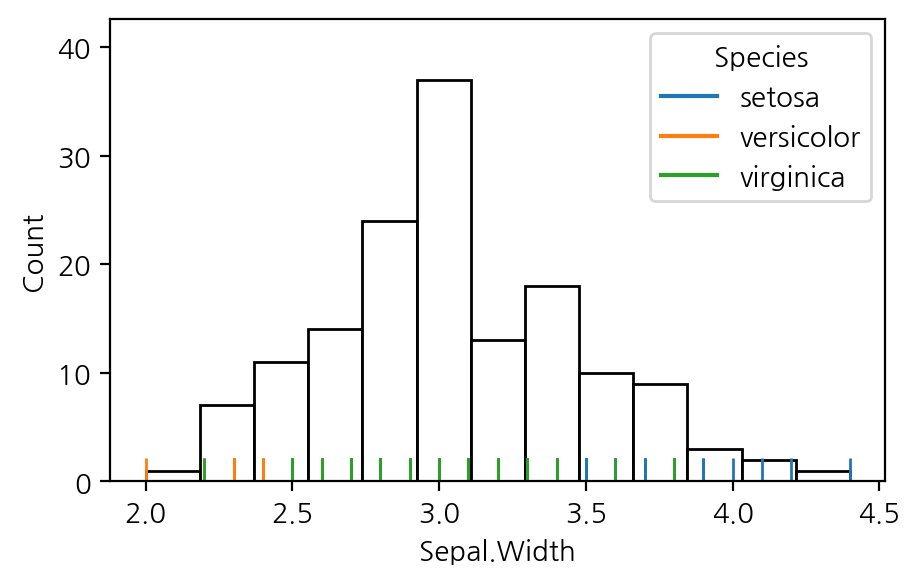

In [ ]:
# 품종별 rugplot
sns.histplot(data=iris, x=iris['Sepal.Width'], color='white')
sns.rugplot(data=iris, x=iris['Sepal.Width'],
            height=0.05, hue='Species')
plt.show()

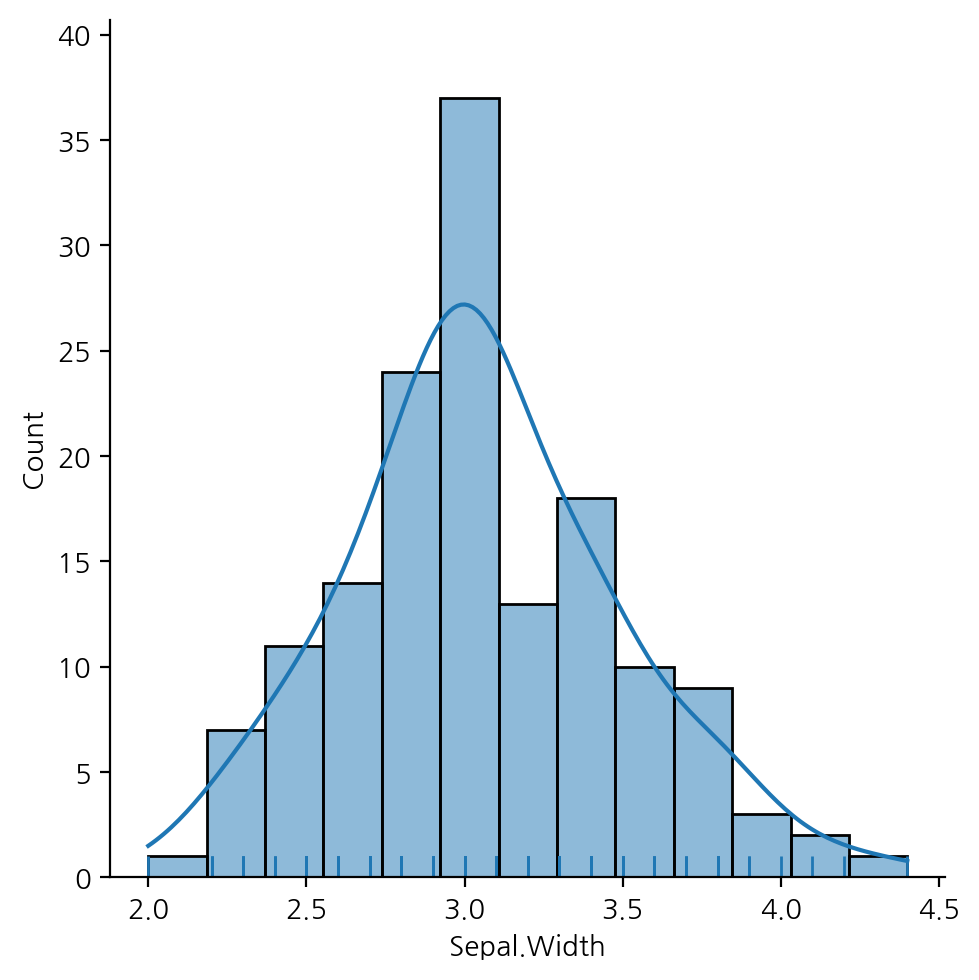

In [ ]:
# displot
sns.displot(data=iris, x=iris['Sepal.Width'], kde=True, rug=True)
plt.show()

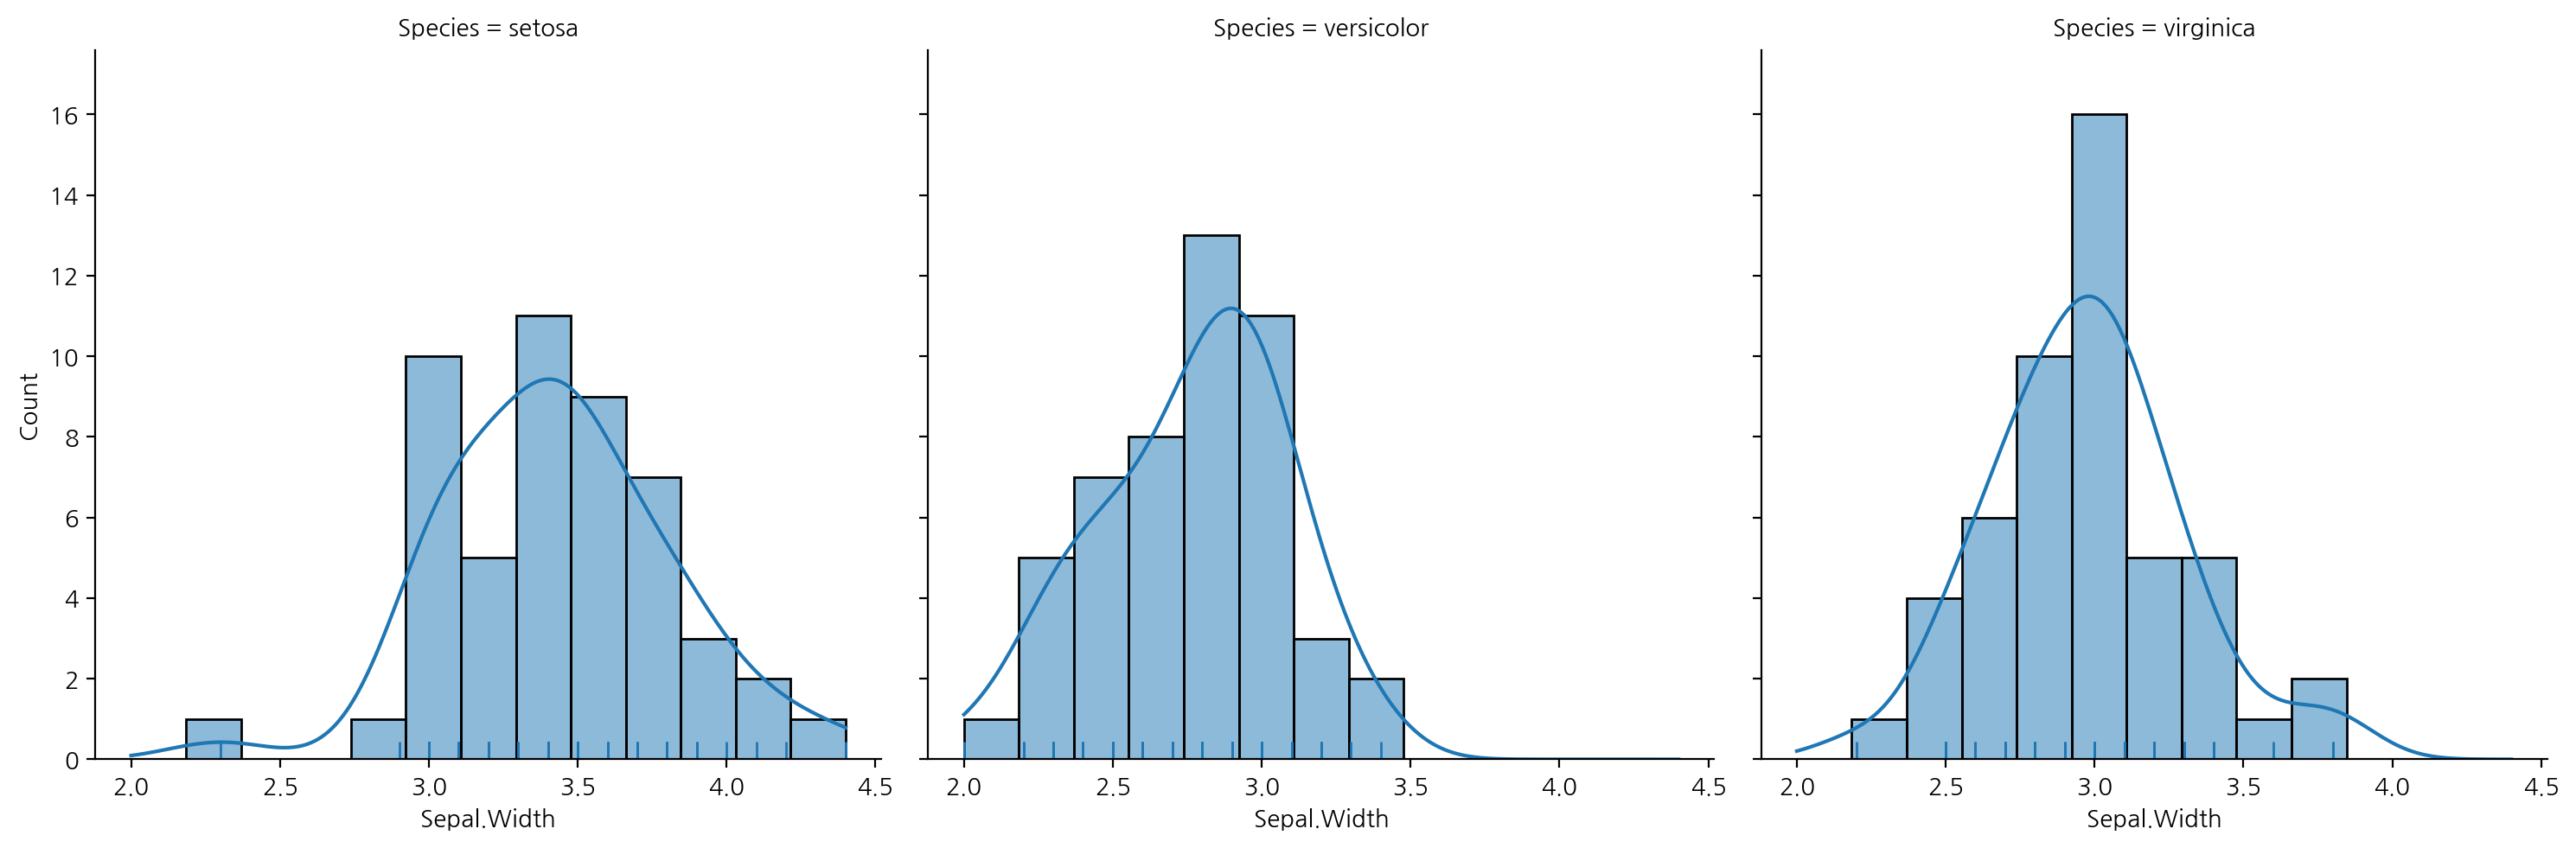

In [ ]:
# 품종별 displot
sns.displot(data=iris, x=iris['Sepal.Width'], col="Species",
            kde=True, rug=True)
plt.show()

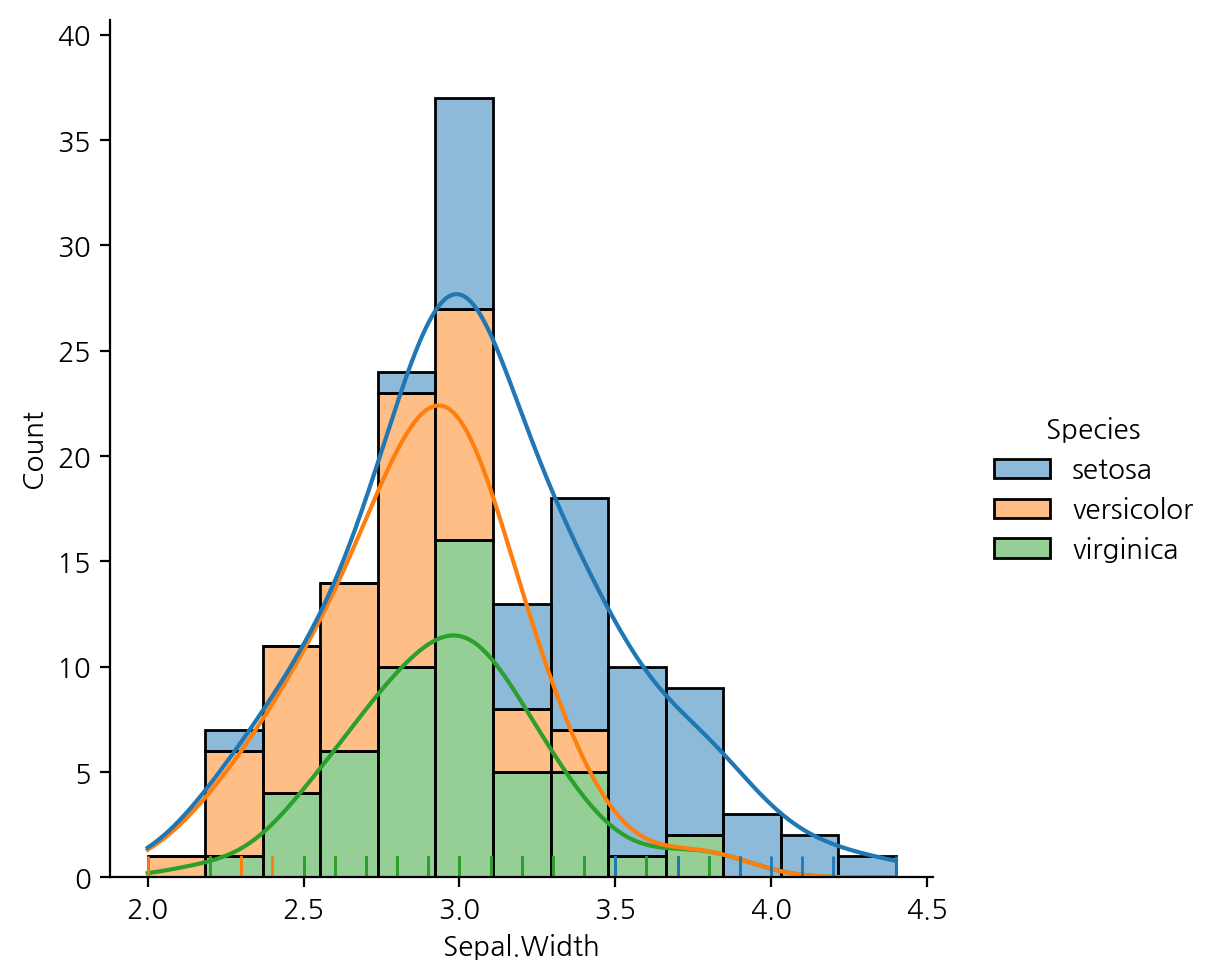

In [ ]:
# stacked displot
sns.displot(data=iris, x=iris['Sepal.Width'], hue="Species",
            kde=True, rug=True, multiple="stack")
plt.show()

### 파이 차트

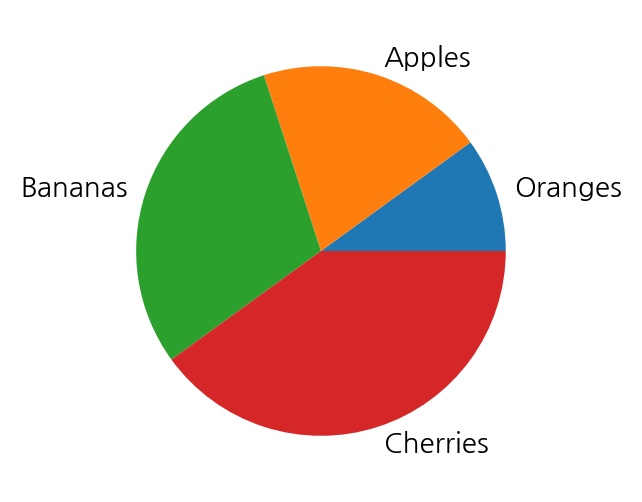

In [ ]:
# 기본 파이 차트
fruits = ['Oranges', 'Apples', 'Bananas', 'Cherries']
plt.pie([10, 20, 30, 40], labels=fruits)
plt.show()

In [ ]:
# cyl 인덱스 확인
mtc.cyl.value_counts().sort_index().index

Index([4, 6, 8], dtype='int64', name='cyl')

In [ ]:
# cyl 라벨 생성
txt = [str(i) + '기통' for i in mtc.cyl.value_counts().sort_index().index]
txt

['4기통', '6기통', '8기통']

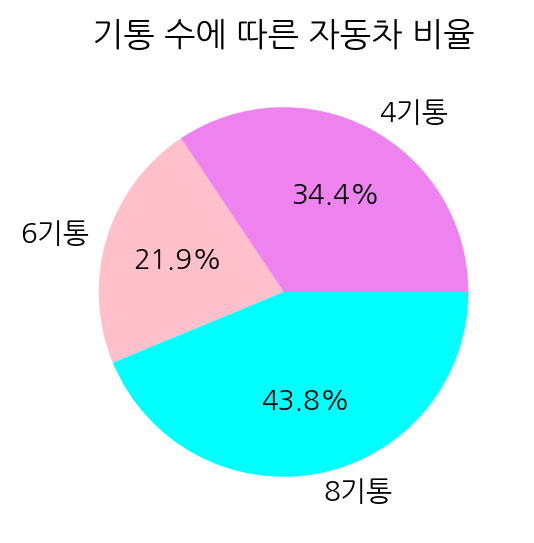

In [ ]:
# cyl 파이 차트
plt.pie(mtc.cyl.value_counts().sort_index(),
        colors=["violet", "pink", "aqua"],
        autopct='%.1f%%',
        labels=txt)

plt.title("기통 수에 따른 자동차 비율")
plt.show()

In [ ]:
# gear 빈도수
mtc.gear.value_counts().sort_index()

,count
gear,
3,15
4,12
5,5


In [ ]:
# gear 라벨 생성
labels = [str(i) + '기어' for i in mtc.gear.value_counts().sort_index().index]
labels

['3기어', '4기어', '5기어']

In [ ]:
# Dark2 색상 팔레트
sns.color_palette('Dark2', 10)

[(0.10588235294117647, 0.6196078431372549, 0.4666666666666667),
 (0.8509803921568627, 0.37254901960784315, 0.00784313725490196),
 (0.4588235294117647, 0.4392156862745098, 0.7019607843137254),
 (0.9058823529411765, 0.1607843137254902, 0.5411764705882353),
 (0.4, 0.6509803921568628, 0.11764705882352941),
 (0.9019607843137255, 0.6705882352941176, 0.00784313725490196),
 (0.6509803921568628, 0.4627450980392157, 0.11372549019607843),
 (0.4, 0.4, 0.4),
 (0.10588235294117647, 0.6196078431372549, 0.4666666666666667),
 (0.8509803921568627, 0.37254901960784315, 0.00784313725490196)]

In [ ]:
# Accent 색상 팔레트
colors = sns.color_palette('Accent', len(labels))
colors

[(0.4980392156862745, 0.788235294117647, 0.4980392156862745),
 (0.7450980392156863, 0.6823529411764706, 0.8313725490196079),
 (0.9921568627450981, 0.7529411764705882, 0.5254901960784314)]

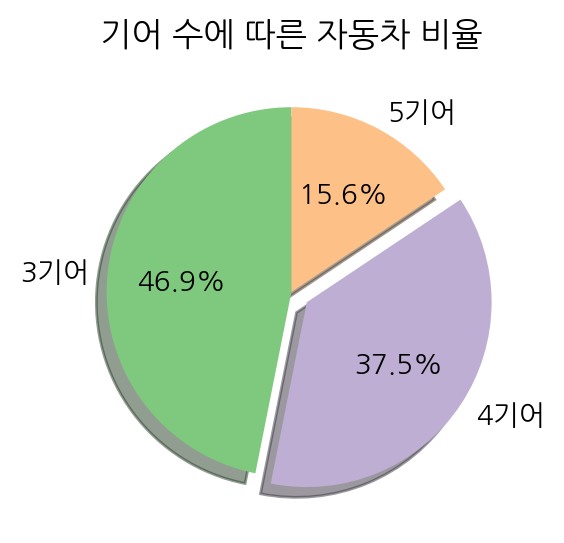

In [ ]:
# shadow, startangle 사용 파이 차트
colors = sns.color_palette('Accent', len(labels))

plt.pie(mtc.gear.value_counts().sort_index(),
        colors=colors,
        explode=[0, .1, 0],
        shadow=True,
        startangle=90,
        autopct='%.1f%%',
        labels=labels)

plt.title("기어 수에 따른 자동차 비율")
plt.show()

## 9.3 바이올린과 상관관계 시각화

### 바이올린 플롯

In [ ]:
# 정규분포 난수 생성
data_v = np.random.randn(100000)

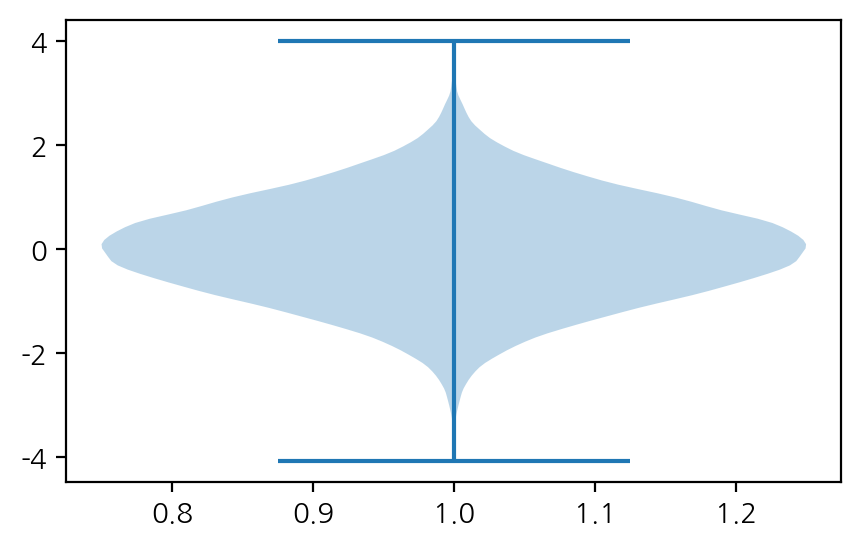

In [ ]:
# 기본 바이올린 플롯
plt.violinplot(data_v)
plt.show()

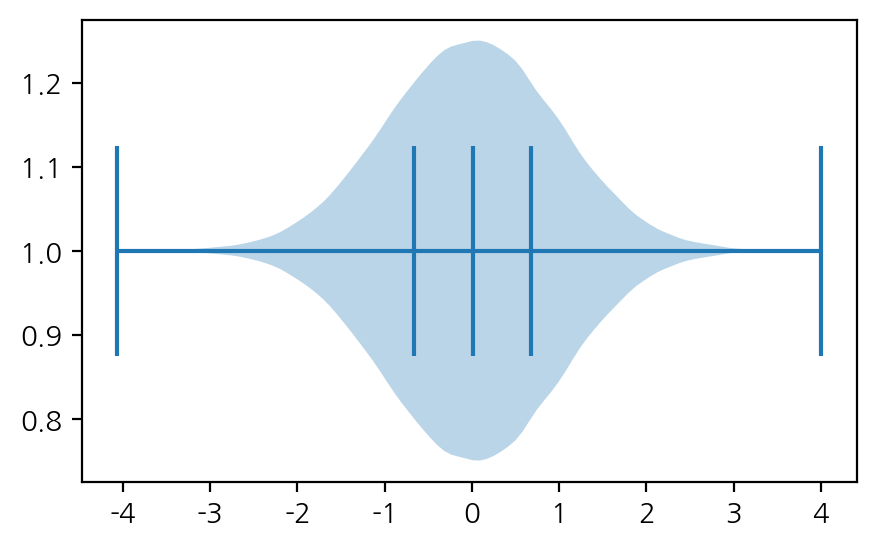

In [ ]:
# 가로 바이올린과 사분위수 표시
plt.violinplot(data_v, vert=False, quantiles=[.25, .5, .75])
plt.show()

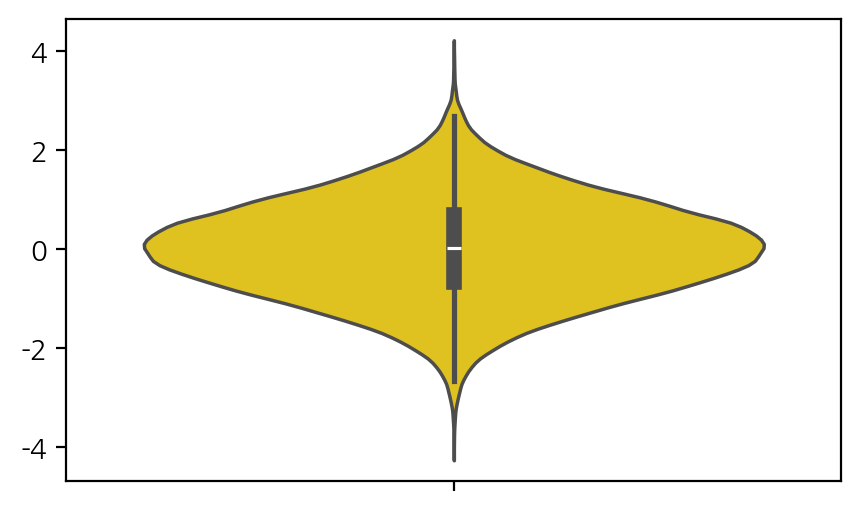

In [ ]:
# seaborn violinplot
sns.violinplot(data_v, color='gold')
plt.show()

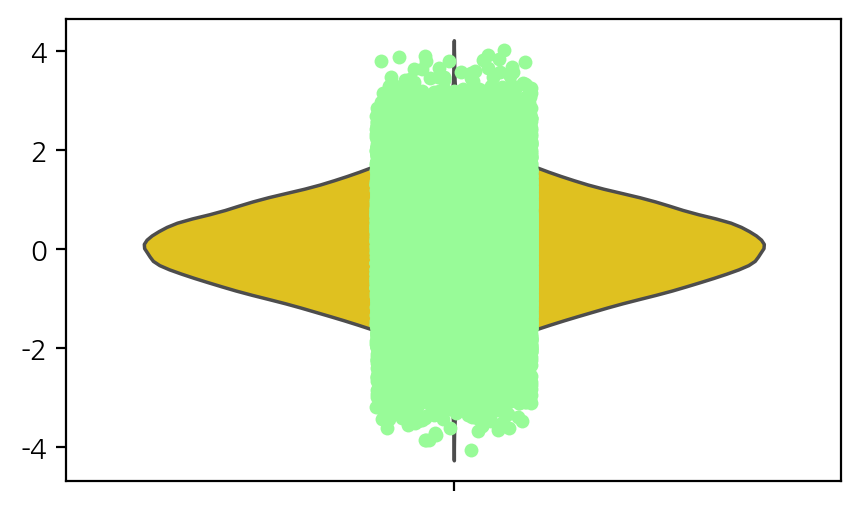

In [ ]:
# violinplot과 stripplot
sns.violinplot(data_v, color='gold')
sns.stripplot(data_v, color='palegreen')
plt.show()

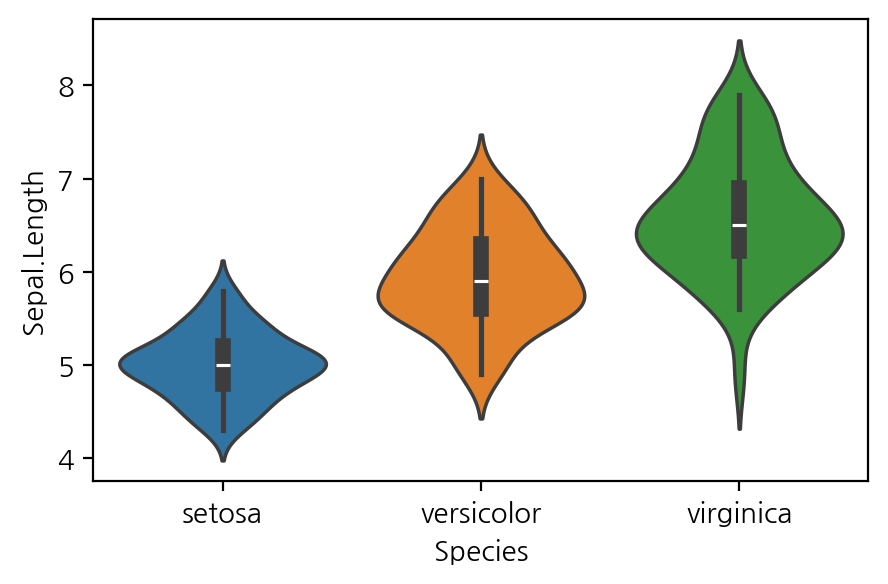

In [ ]:
# iris 품종별 Sepal.Length 바이올린 플롯
sns.violinplot(data=iris, x='Species', y='Sepal.Length', hue='Species')
plt.show()

### pairplot과 상관관계

In [ ]:
# mtcars 앞 4개 변수
mincars = mtc.iloc[:, :4]
mincars.head()

,mpg,cyl,disp,hp
Mazda RX4,21.0,6,160.0,110
Mazda RX4 Wag,21.0,6,160.0,110
Datsun 710,22.8,4,108.0,93
Hornet 4 Drive,21.4,6,258.0,110
Hornet Sportabout,18.7,8,360.0,175


In [ ]:
# 열 이름 확인
mtc.columns[:4].to_list()

['mpg', 'cyl', 'disp', 'hp']

In [ ]:
# 열 이름으로 앞 4개 변수 선택
mcar = mtc[mtc.columns[:4].to_list()]
display_side_by_side(mincars.head(), mcar.head())

,mpg,cyl,disp,hp
Mazda RX4,21.0,6,160.0,110
Mazda RX4 Wag,21.0,6,160.0,110
Datsun 710,22.8,4,108.0,93
Hornet 4 Drive,21.4,6,258.0,110
Hornet Sportabout,18.7,8,360.0,175
,mpg,cyl,disp,hp
Mazda RX4,21.0,6,160.0,110
Mazda RX4 Wag,21.0,6,160.0,110
Datsun 710,22.8,4,108.0,93
Hornet 4 Drive,21.4,6,258.0,110


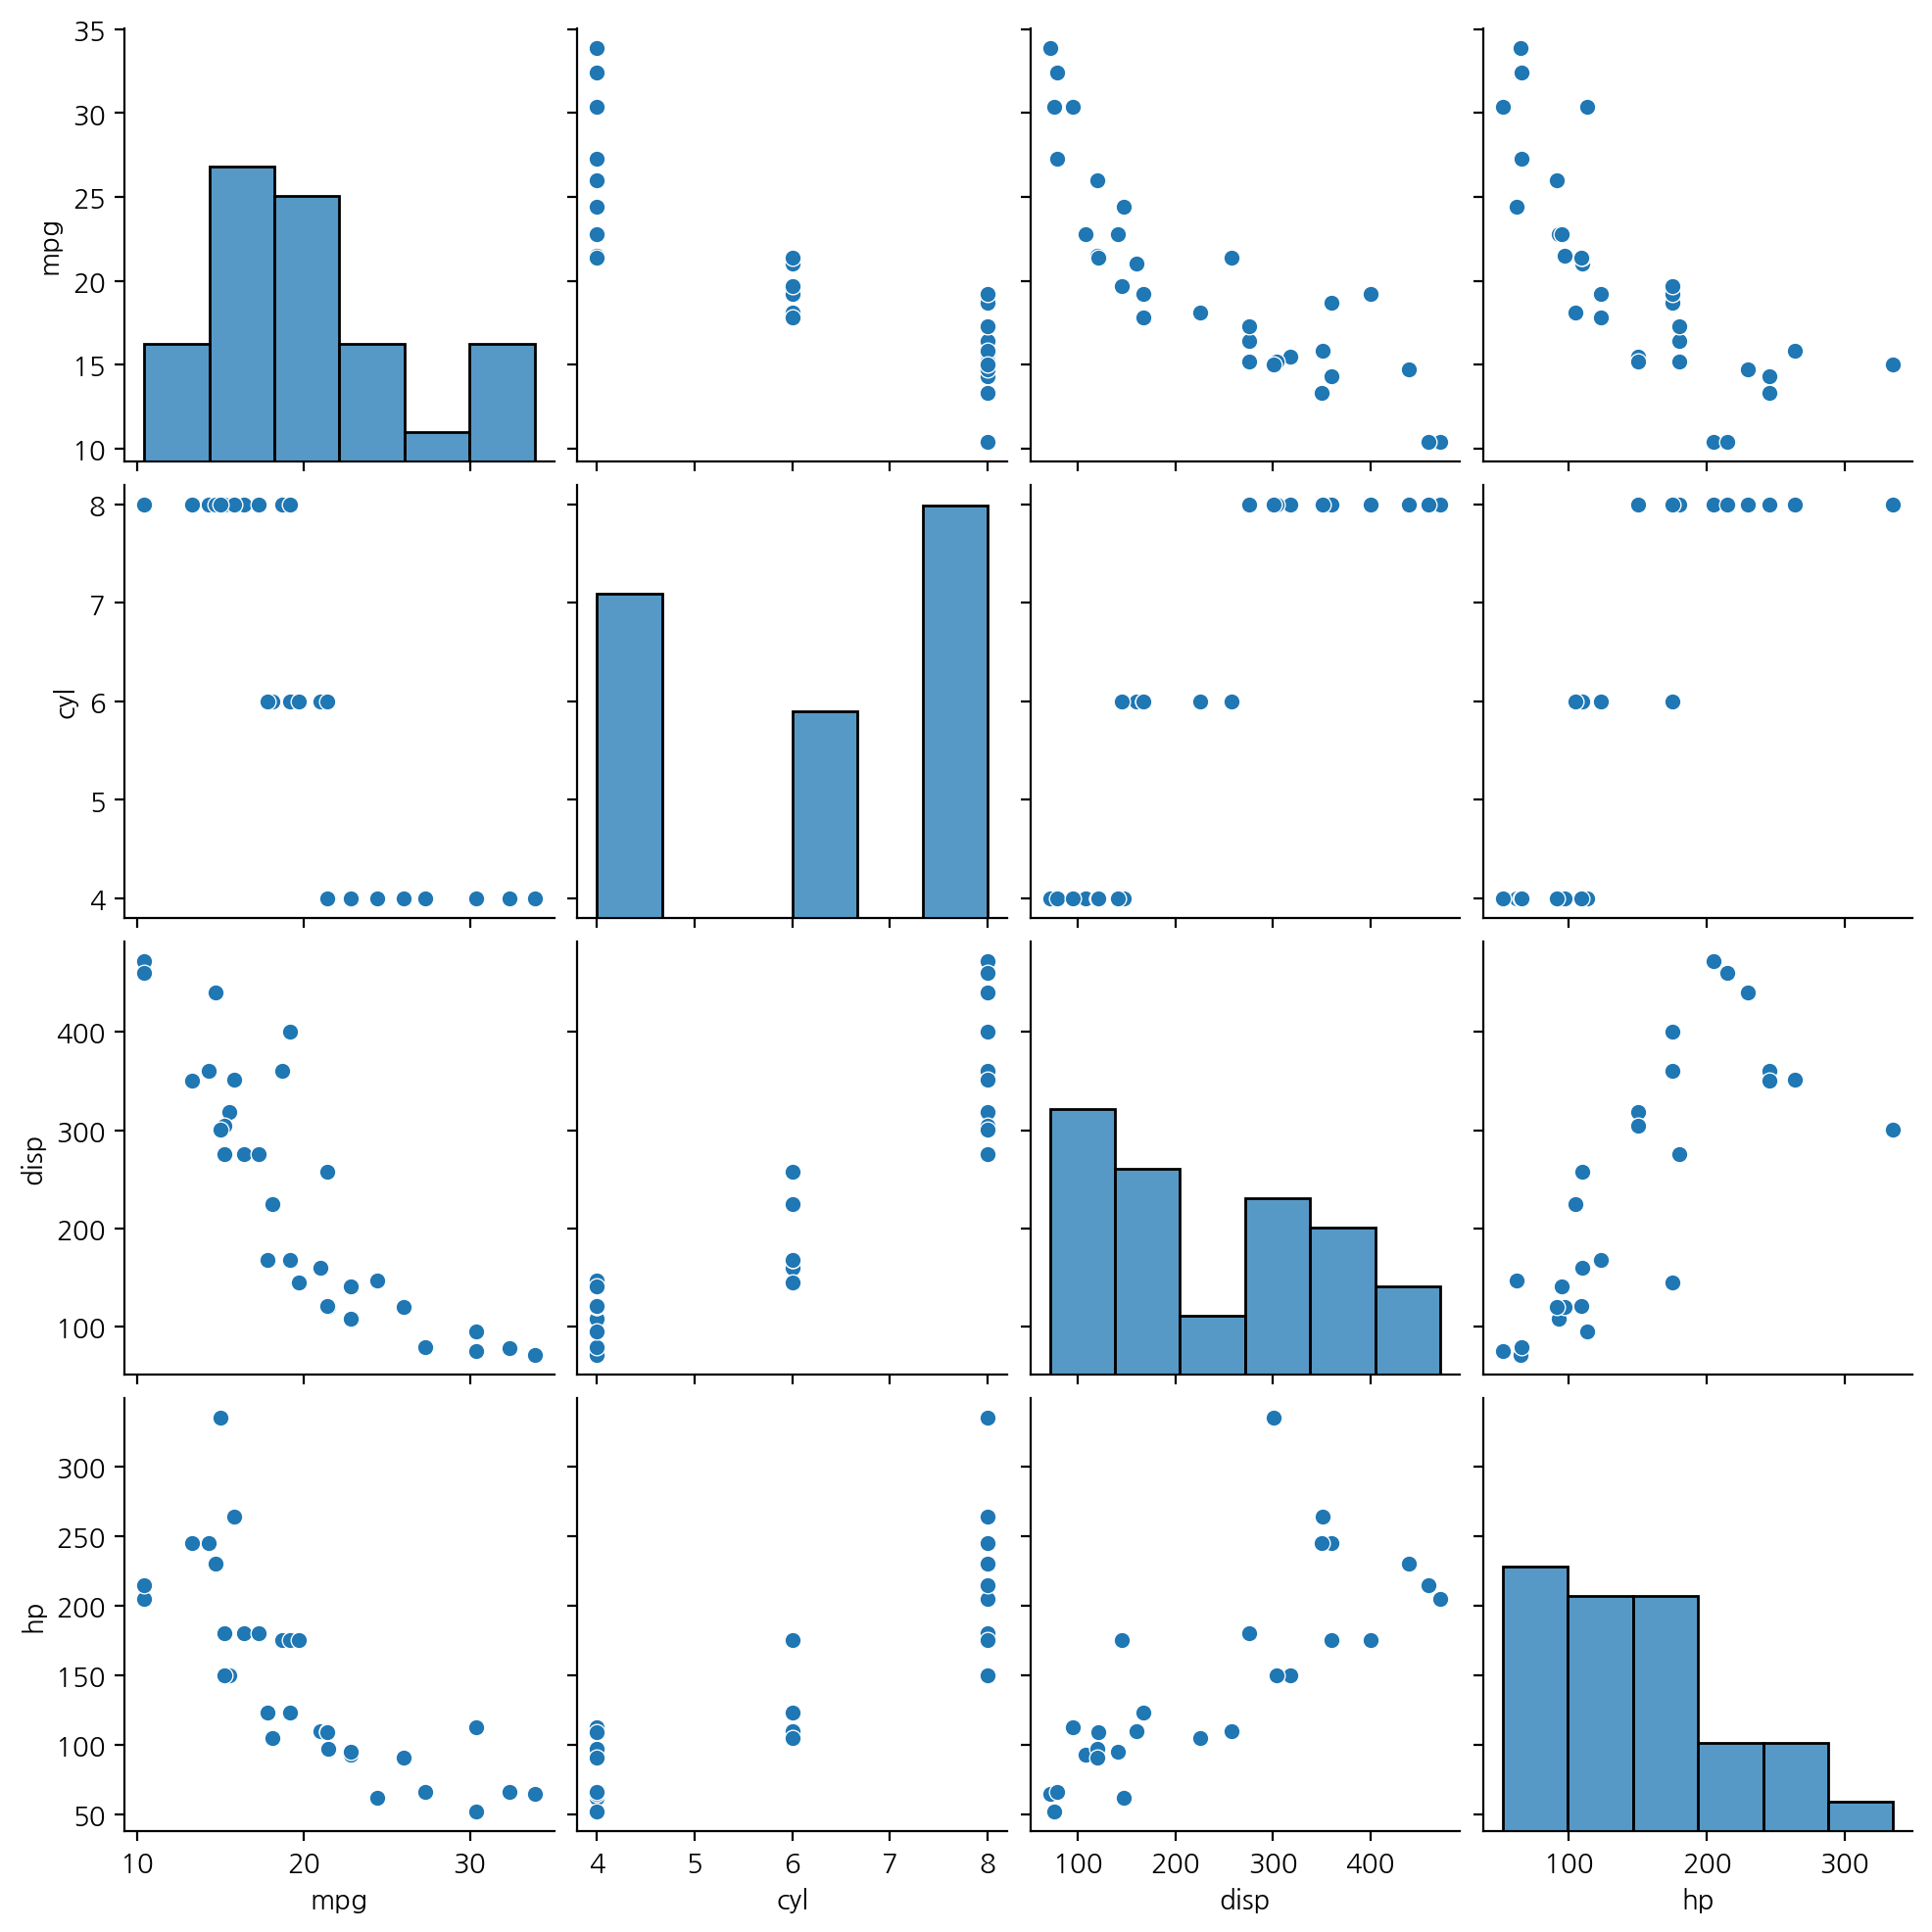

In [ ]:
# 기본 pairplot
sns.pairplot(mincars)
plt.show()

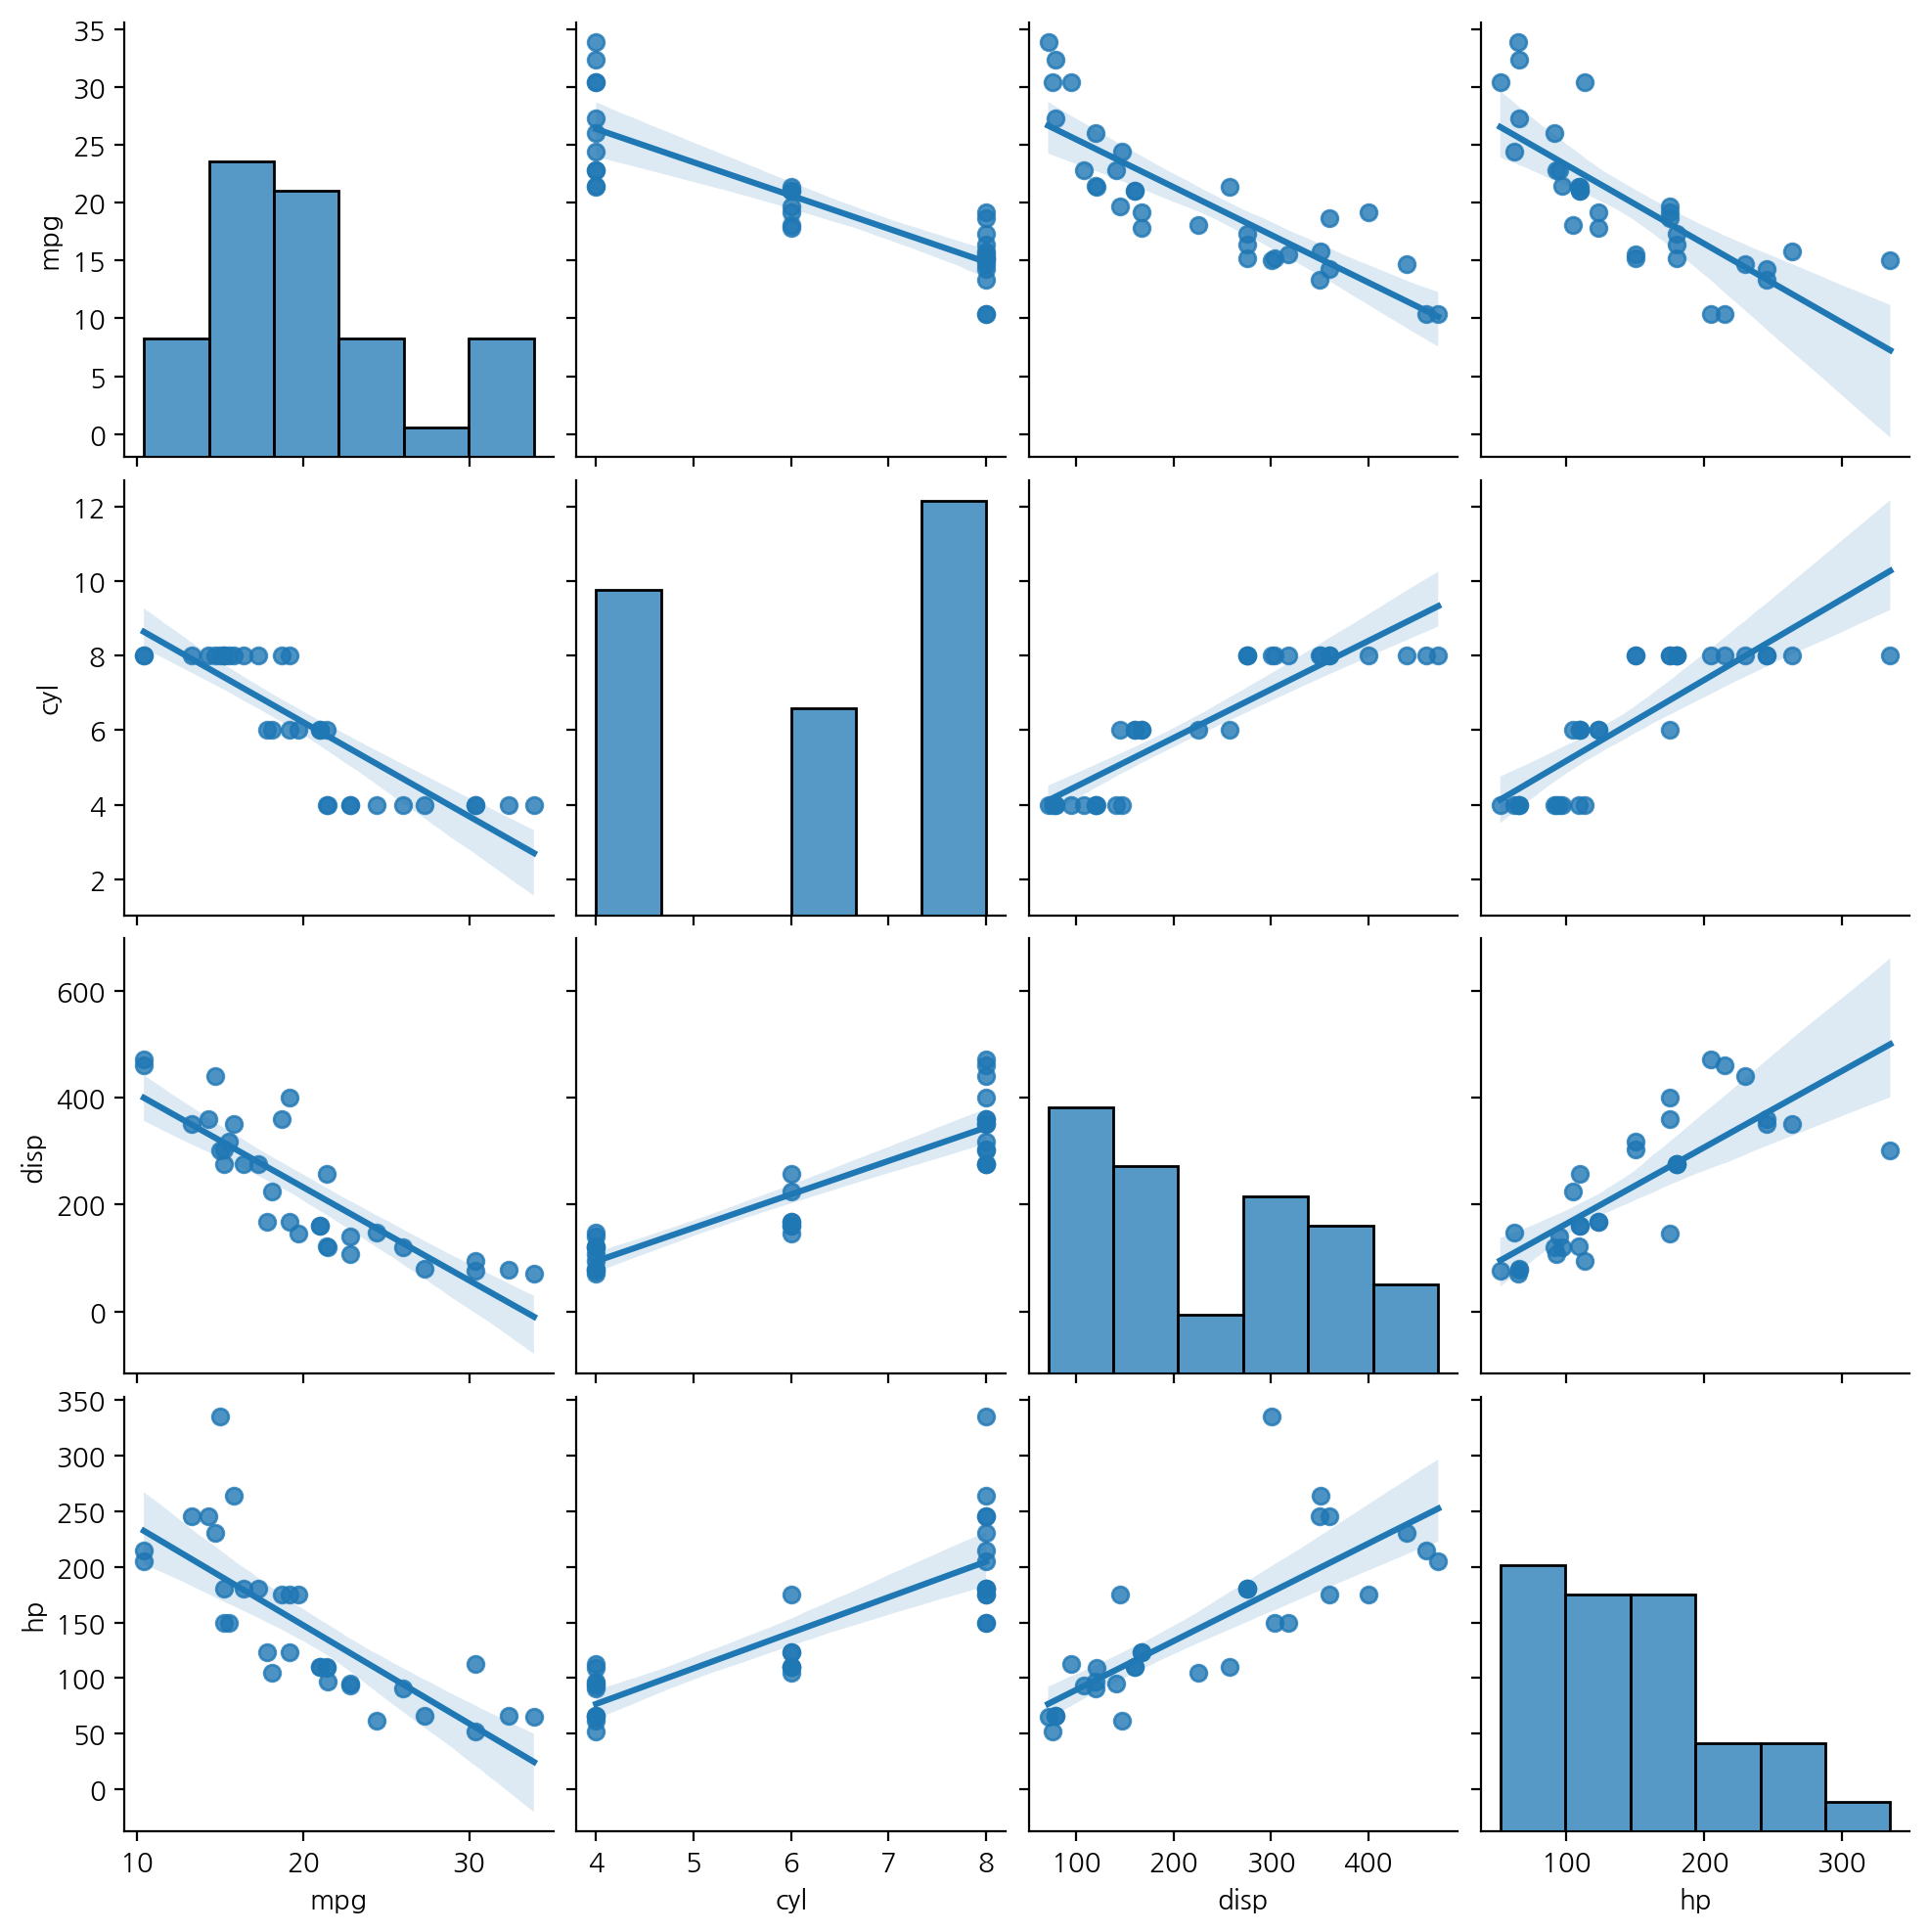

In [ ]:
# kind='reg'
sns.pairplot(mcar, kind='reg')
plt.show()

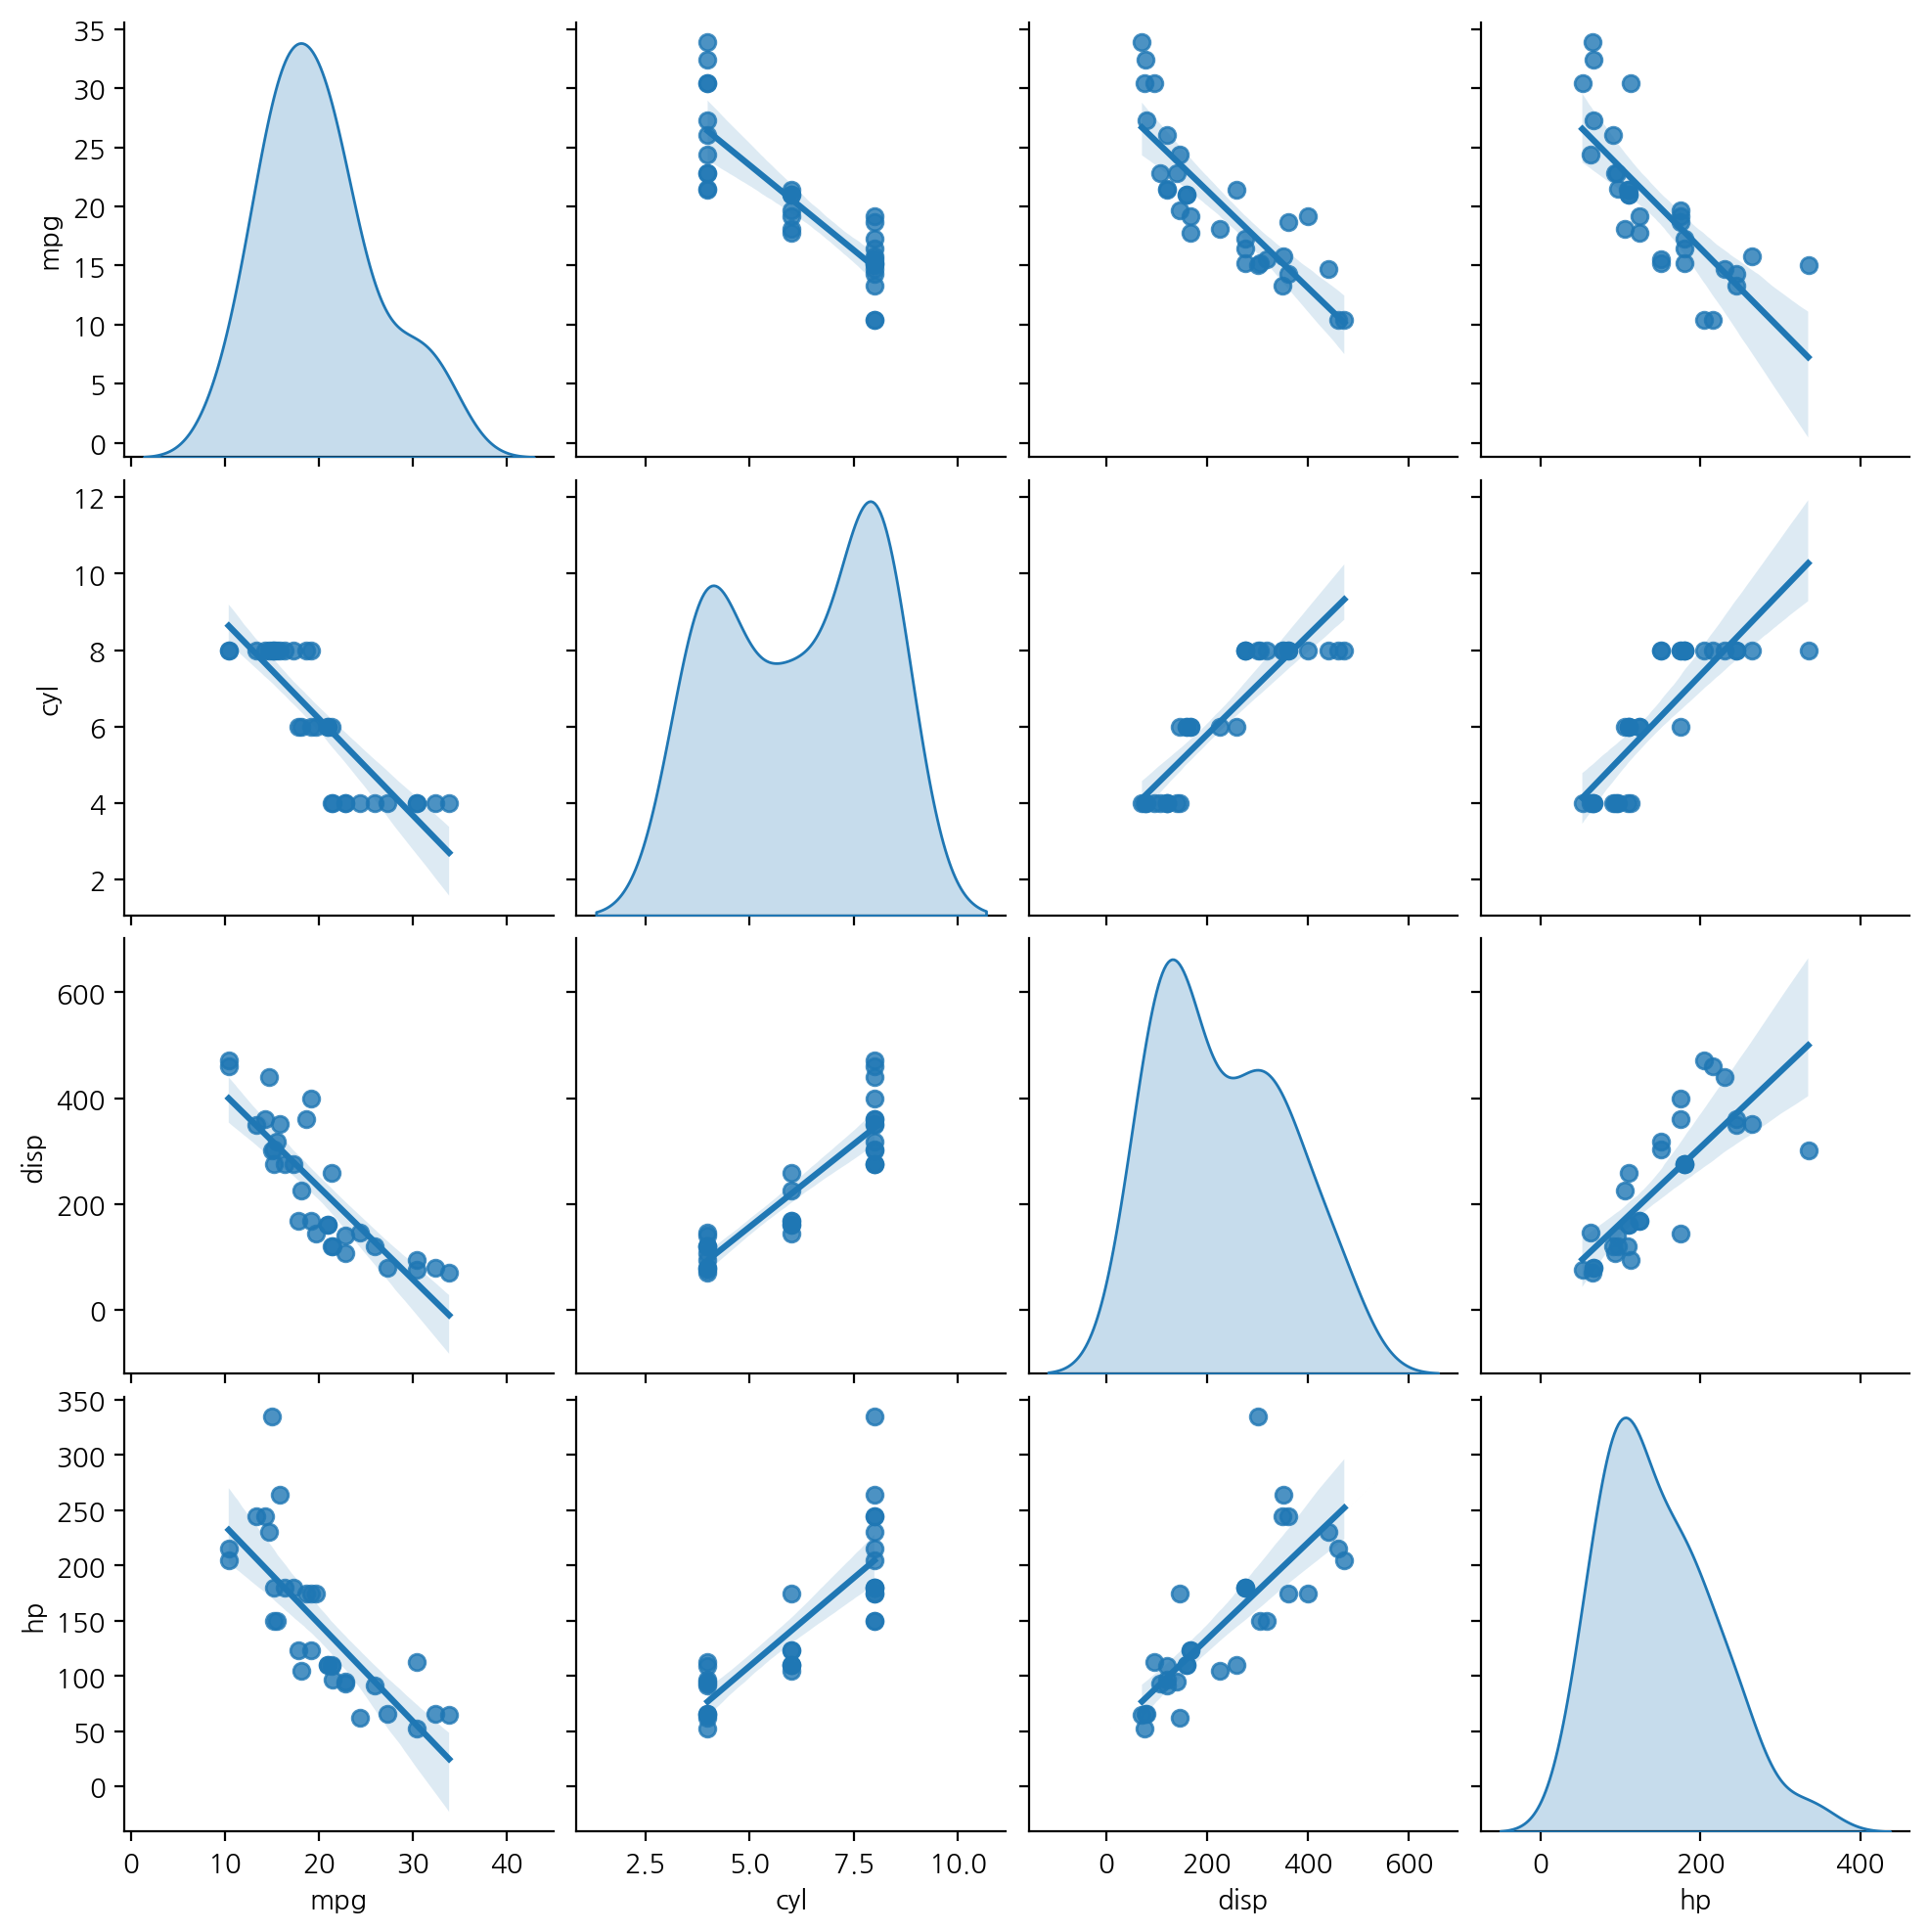

In [ ]:
# diag_kind='kde'
sns.pairplot(mcar, kind='reg', diag_kind='kde')
plt.show()

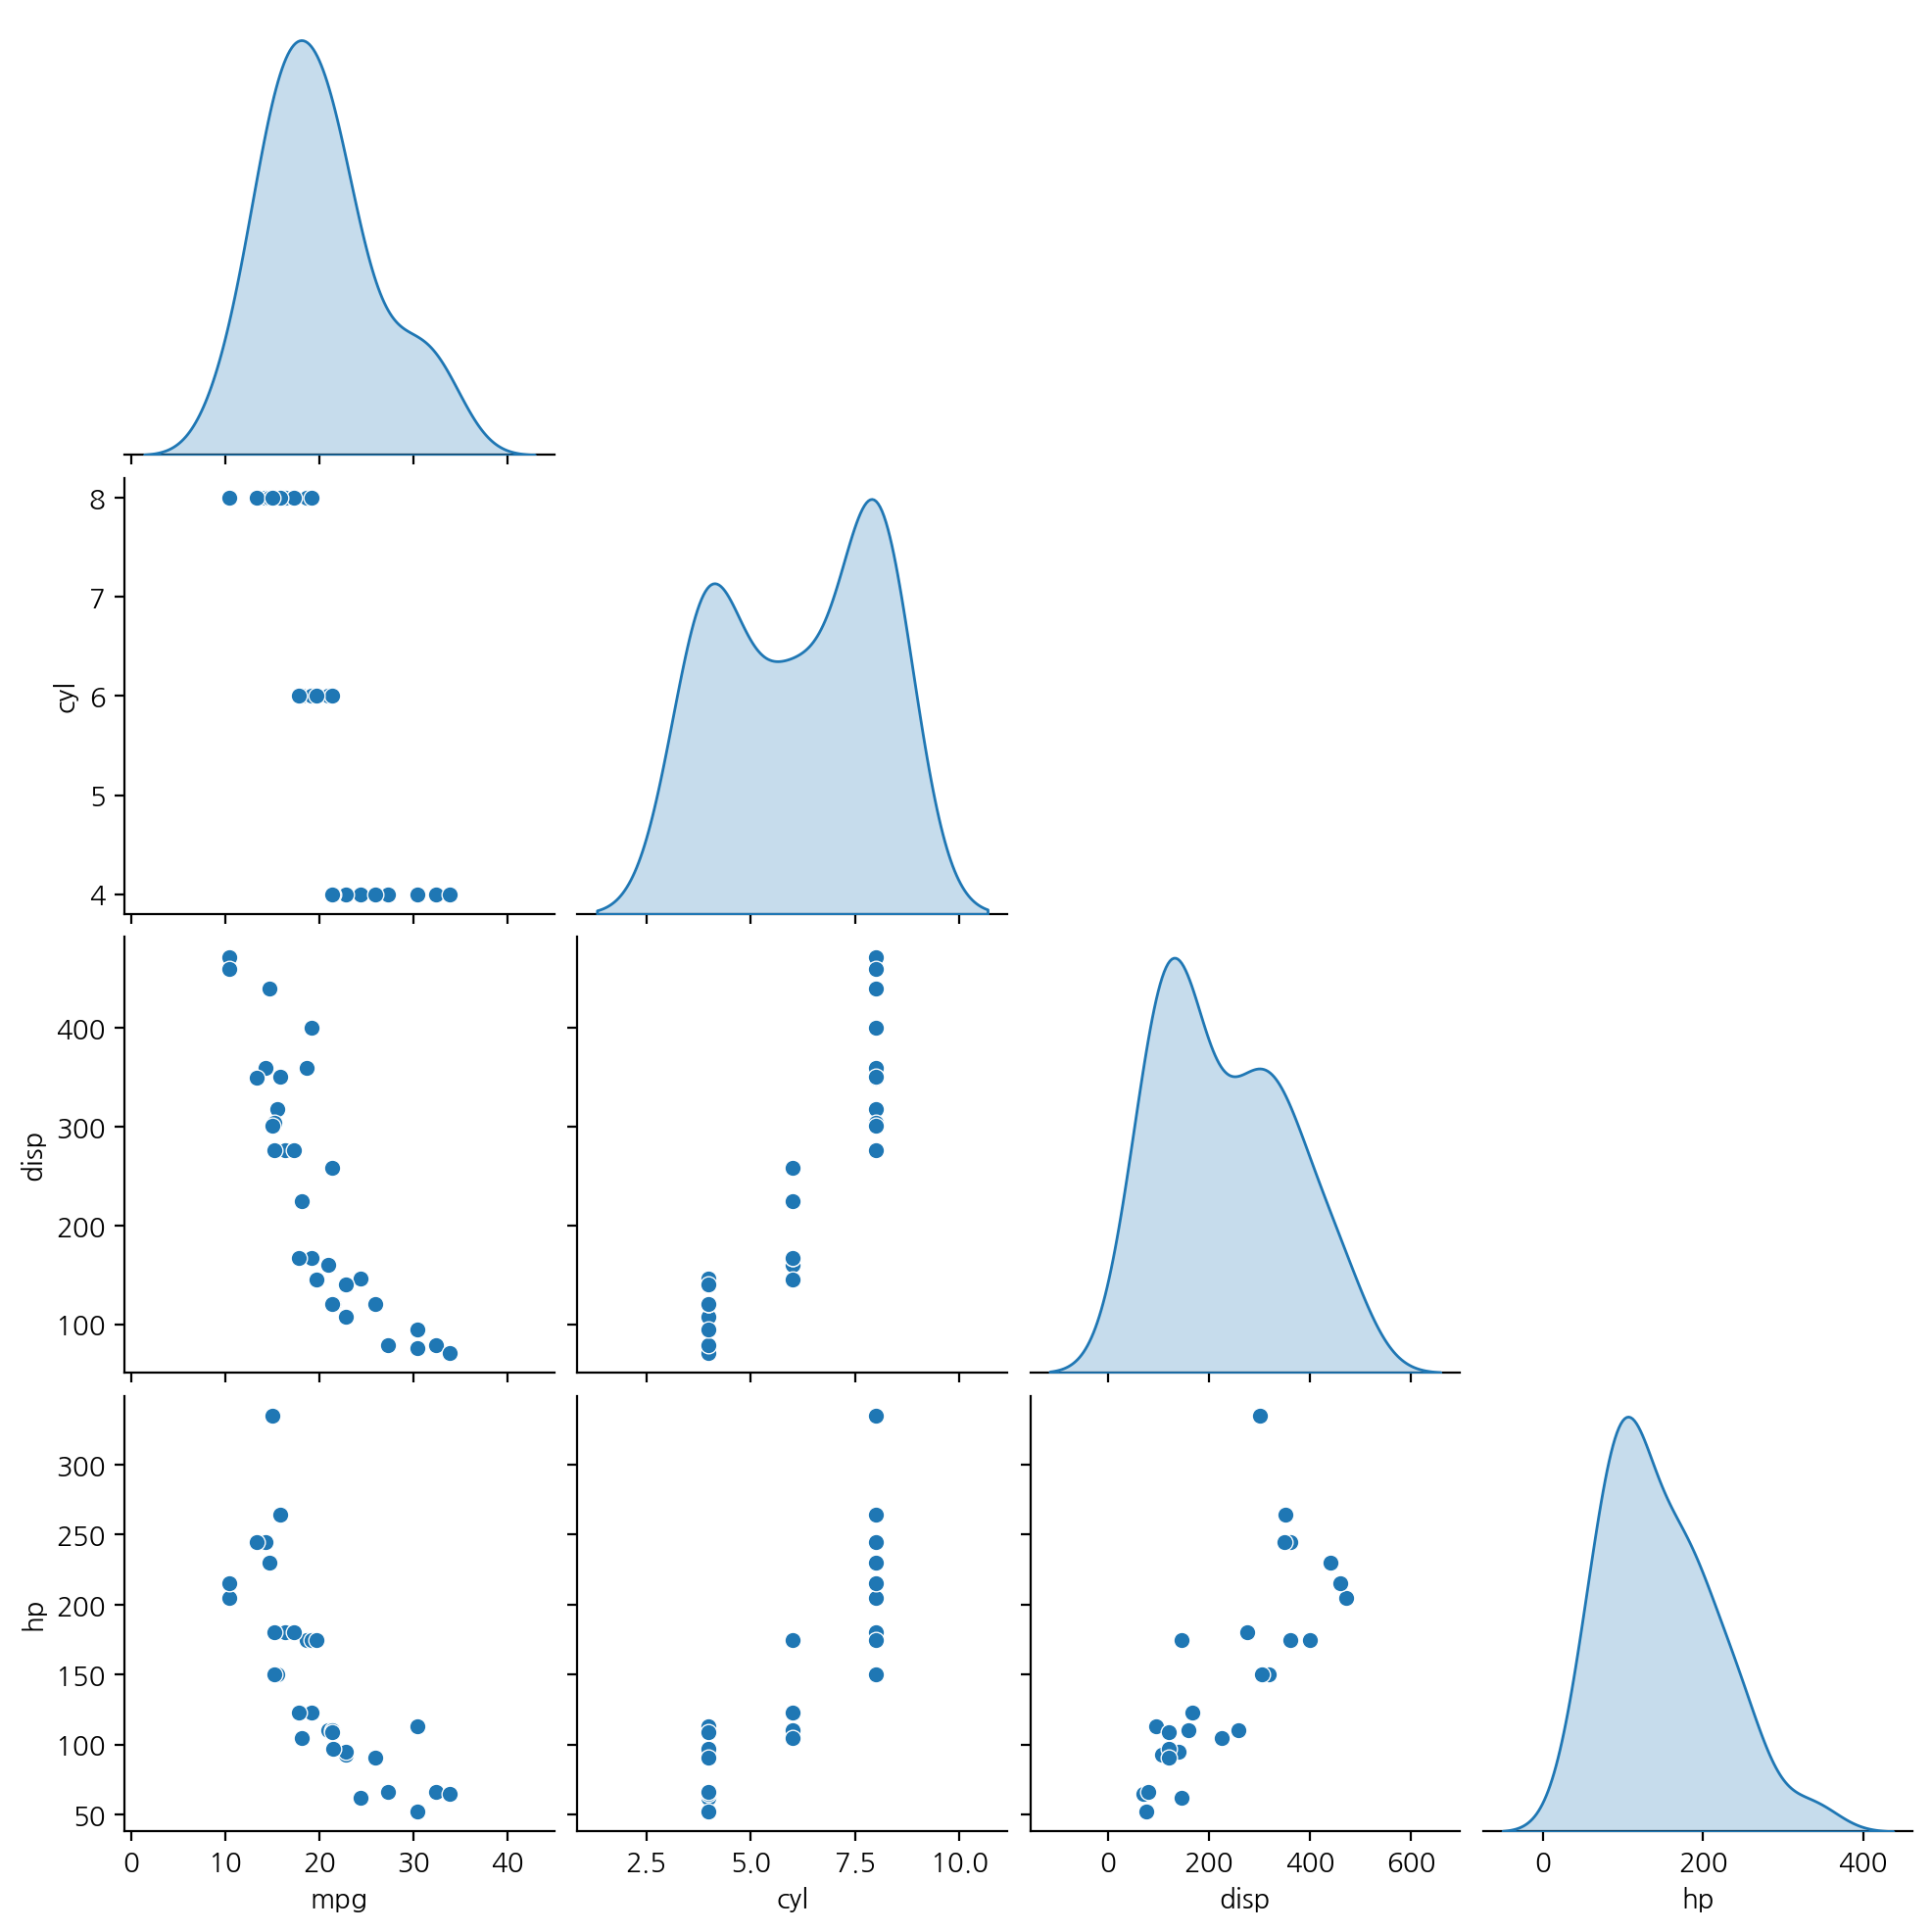

In [ ]:
# corner=True
sns.pairplot(mcar, diag_kind='kde', corner=True)
plt.show()

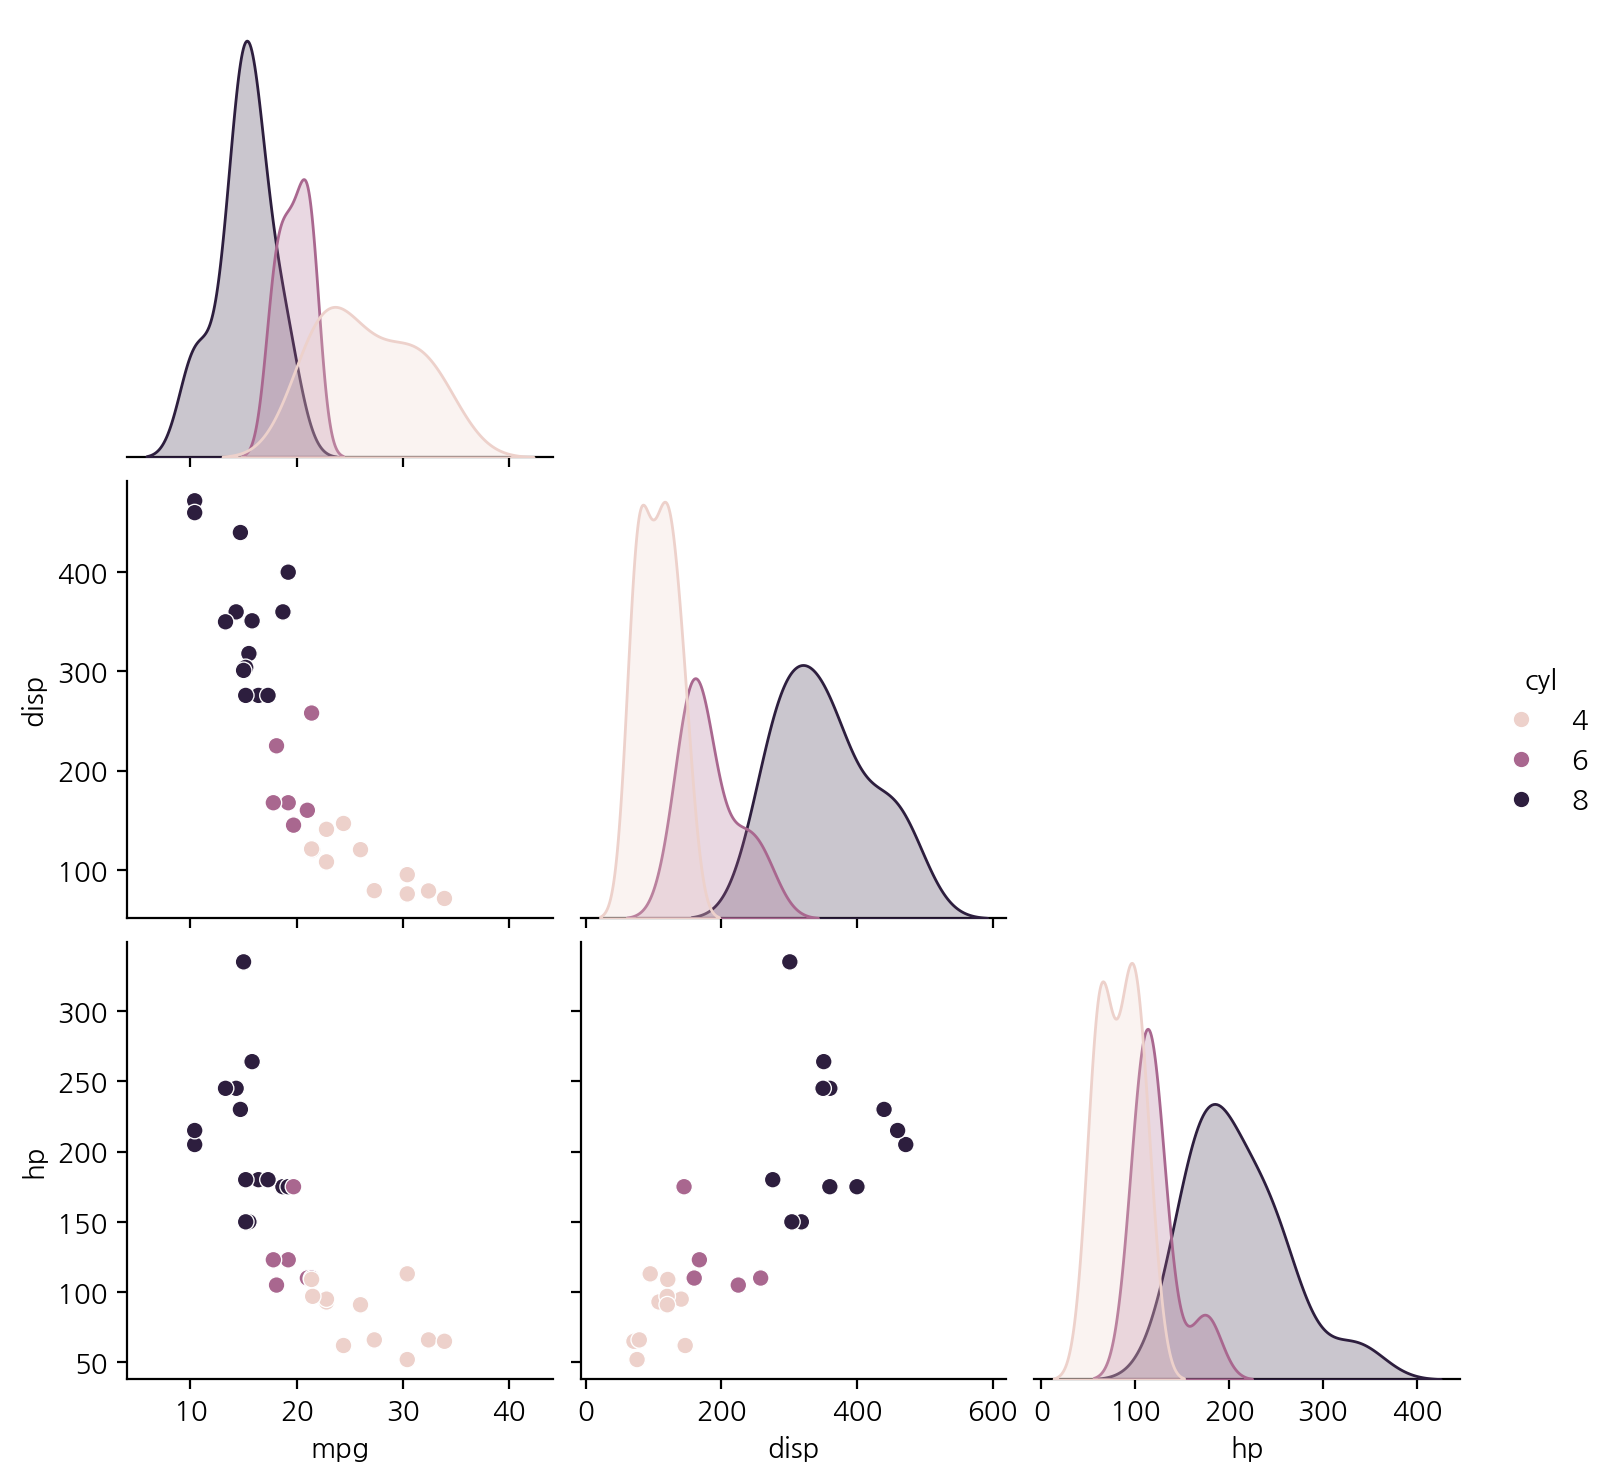

In [ ]:
# hue='cyl'
sns.pairplot(mcar, diag_kind='kde', corner=True, hue='cyl')
plt.show()

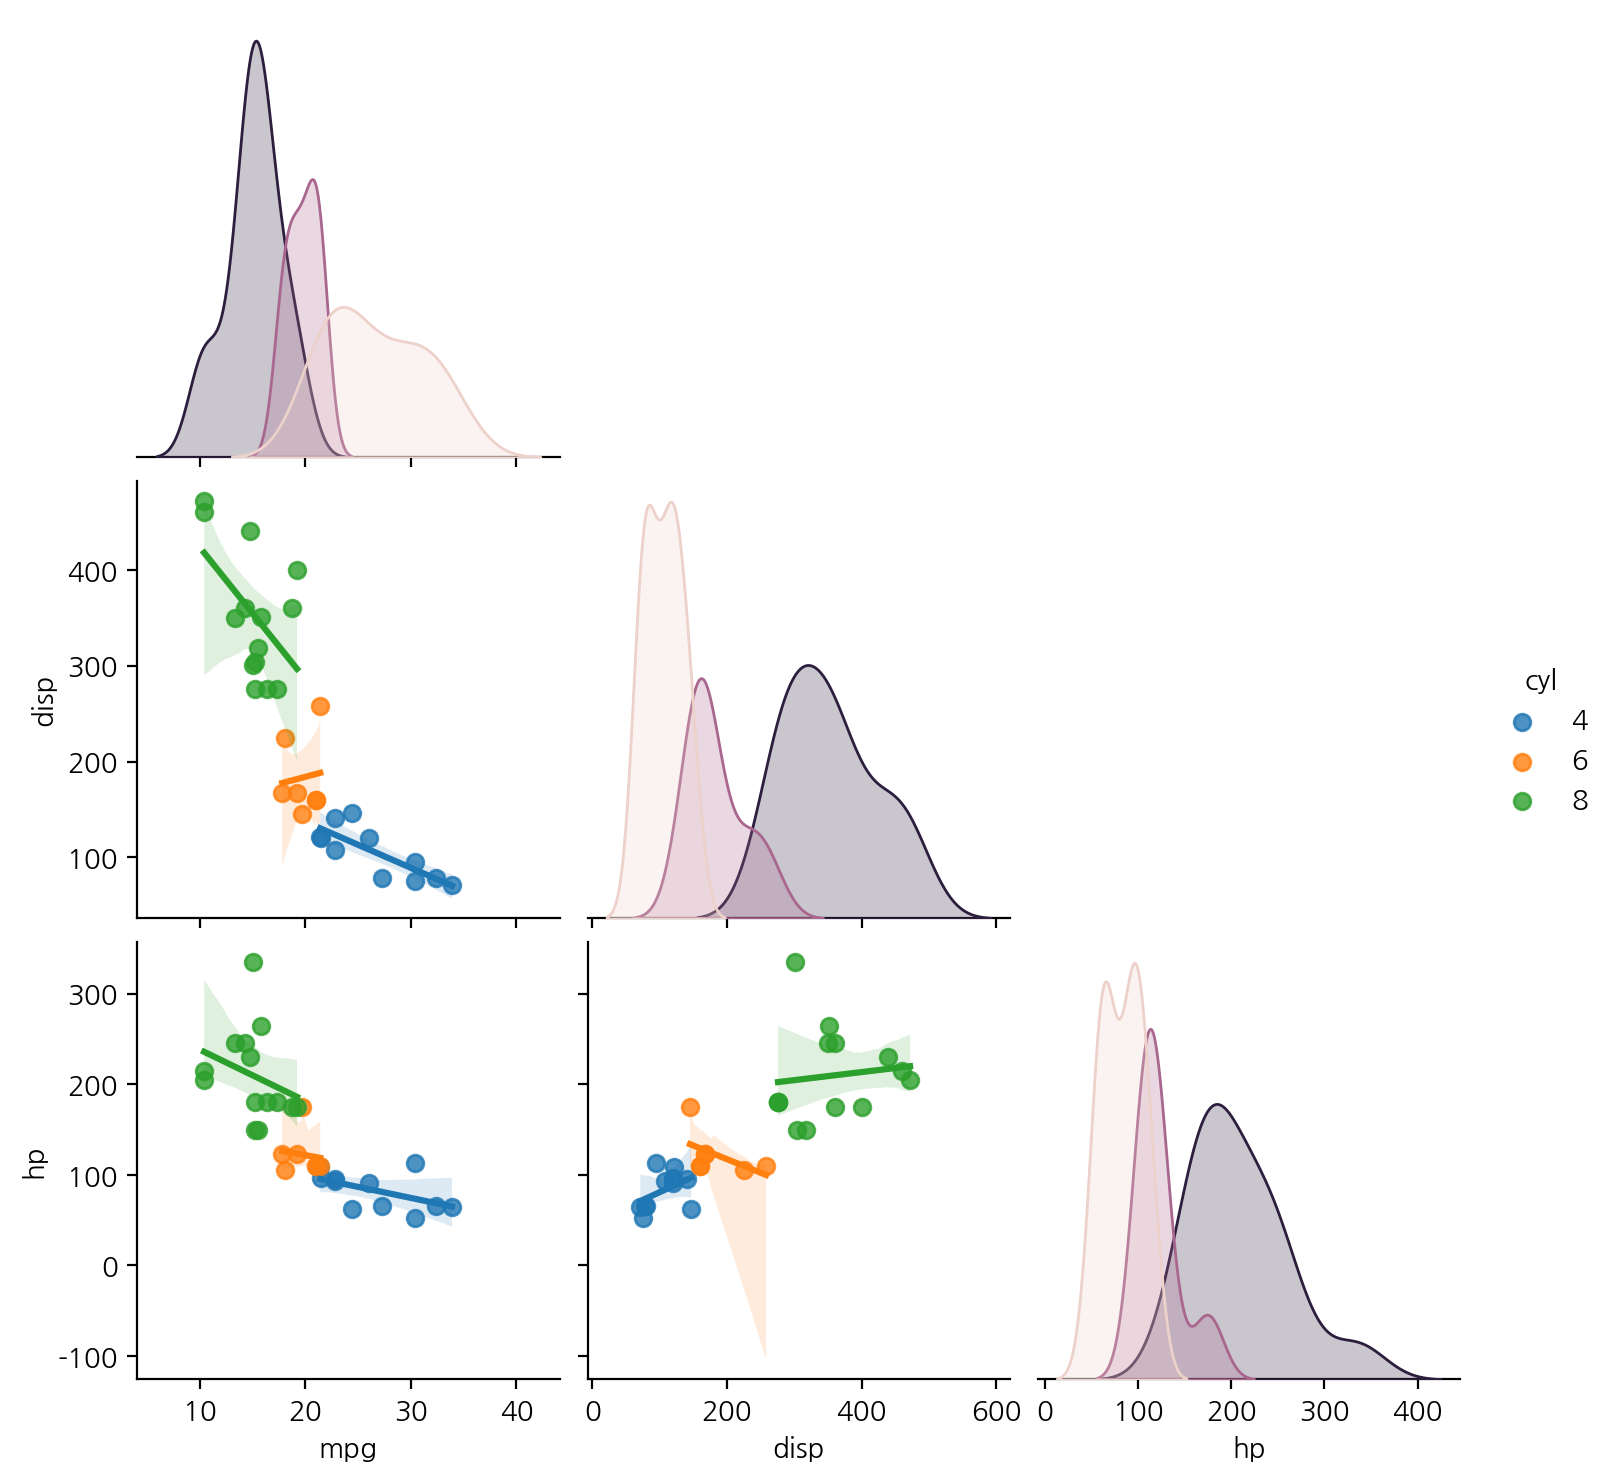

In [ ]:
# 회귀선과 hue 함께 사용
sns.pairplot(mcar, diag_kind='kde', kind='reg', corner=True, hue='cyl')
plt.show()

### seaborn iris와 상관관계

In [ ]:
# seaborn iris 데이터
iris = sns.load_dataset('iris')
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
# 숫자형 열만 확인
iris[iris.columns[:-1].to_list()].head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
# 상관계수 반환
iris[iris.columns[:-1].to_list()].corr()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


In [ ]:
# 표시 소수점 조정
pd.set_option('display.precision', 3)

corr = iris[iris.columns[:-1].to_list()].corr()
corr

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000,-0.118,0.872,0.818
sepal_width,-0.118,1.000,-0.428,-0.366
petal_length,0.872,-0.428,1.000,0.963
petal_width,0.818,-0.366,0.963,1.000


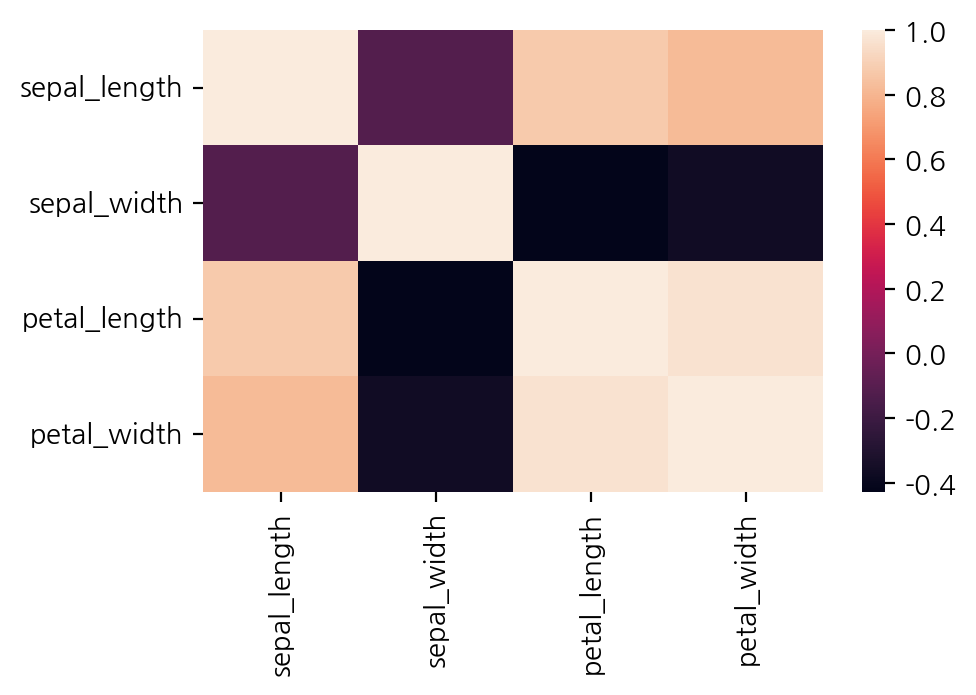

In [ ]:
# 기본 heatmap
sns.heatmap(corr)
plt.show()

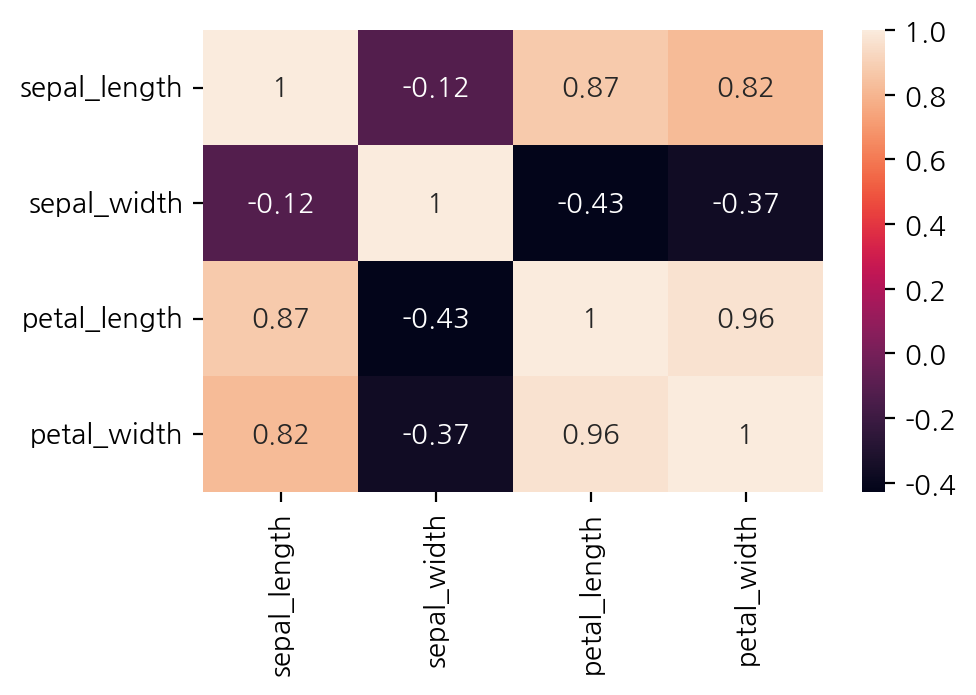

In [ ]:
# annot=True
sns.heatmap(corr, annot=True)
plt.show()

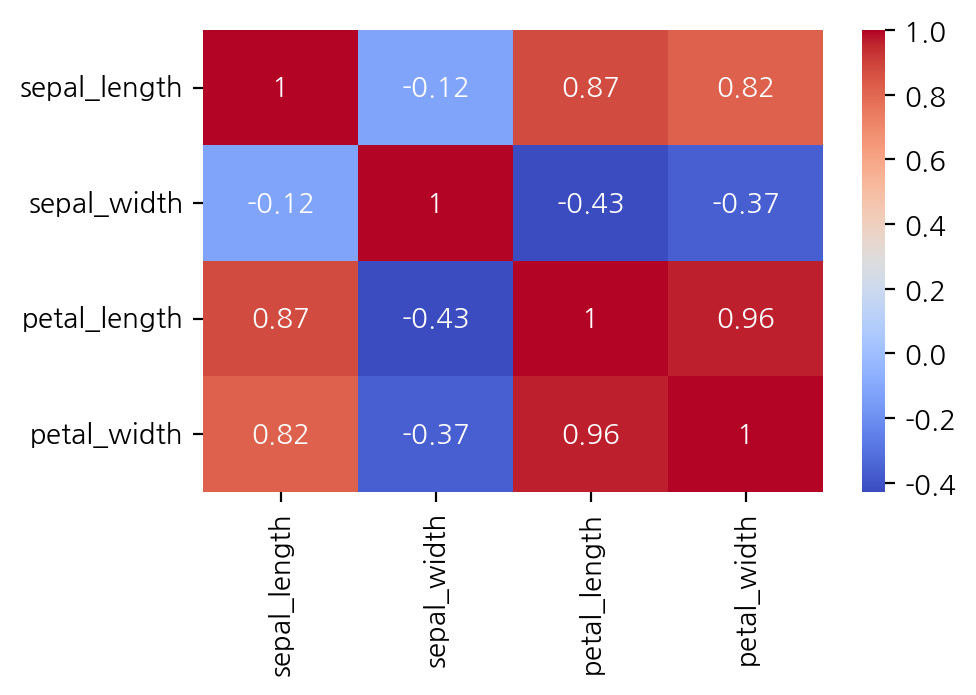

In [ ]:
# cmap='coolwarm'
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

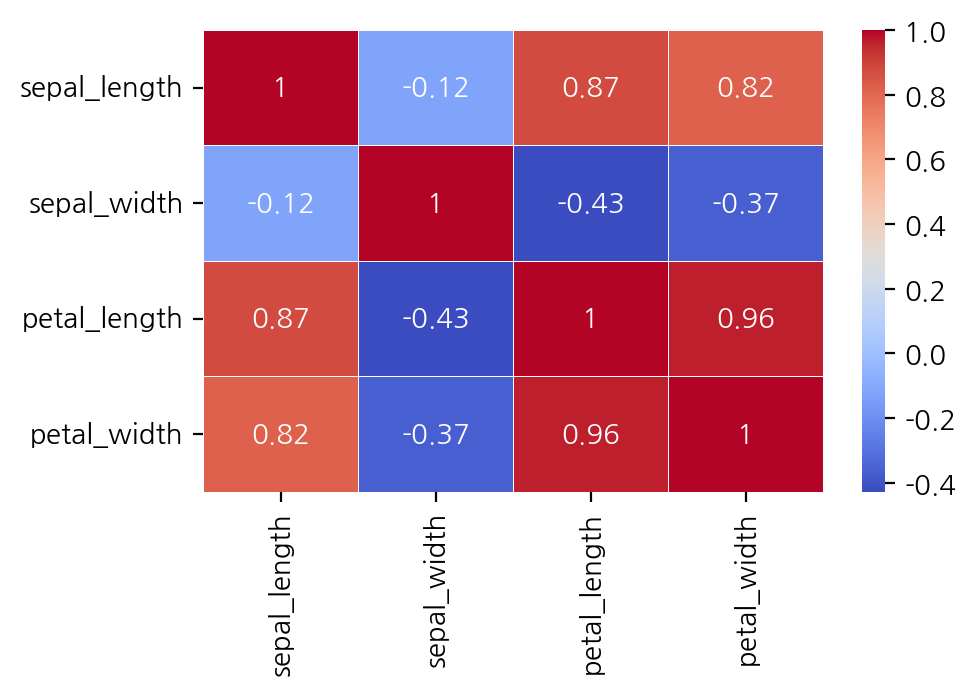

In [ ]:
# lw=.2
sns.heatmap(corr, annot=True, cmap='coolwarm', lw=.2)
plt.show()

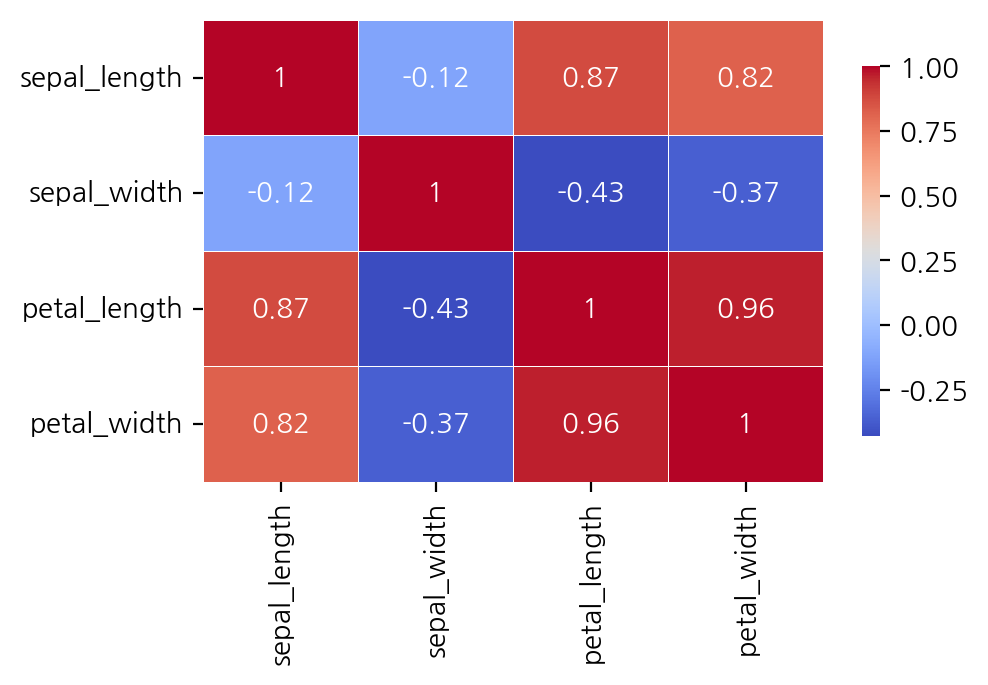

In [ ]:
# cbar_kws 사용
sns.heatmap(corr, annot=True, cmap='coolwarm', lw=.2,
            cbar_kws={'shrink': .8})
plt.show()

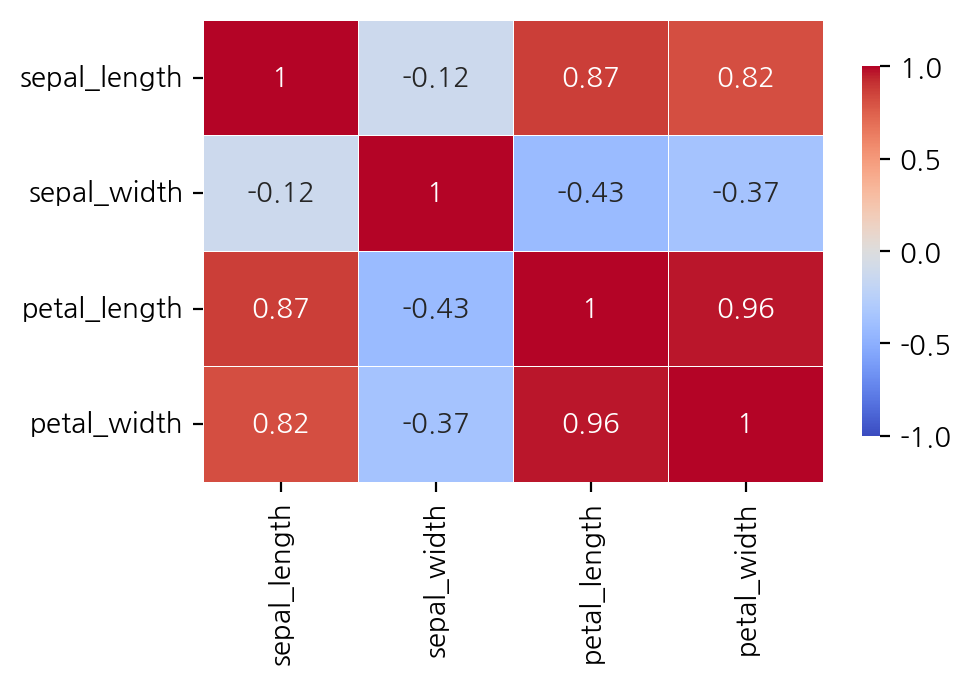

In [ ]:
# vmin, vmax 지정
sns.heatmap(corr, annot=True, cmap='coolwarm', lw=.2,
            cbar_kws={'shrink': .8},
            vmin=-1, vmax=1)
plt.show()

### 히트맵 마스크

In [ ]:
# 상관계수와 같은 모양의 0 행렬 생성
mask = np.zeros_like(corr)
mask

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [ ]:
# 상삼각형 인덱스
np.triu_indices_from(mask)

(array([0, 0, 0, 0, 1, 1, 1, 2, 2, 3]), array([0, 1, 2, 3, 1, 2, 3, 2, 3, 3]))

In [ ]:
# 단일 원소 확인
mask[0, 0]

np.float64(0.0)

In [ ]:
# 여러 원소 확인
mask[[0, 1], [0, 1]]

array([0., 0.])

In [ ]:
# 상삼각형 위치 확인
mask[[0, 0, 0, 0, 1, 1, 1, 2, 2, 3],
     [0, 1, 2, 3, 1, 2, 3, 2, 3, 3]]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
# 상삼각형을 True로 수정
mask[np.triu_indices_from(mask)] = True
mask

array([[1., 1., 1., 1.],
       [0., 1., 1., 1.],
       [0., 0., 1., 1.],
       [0., 0., 0., 1.]])

In [ ]:
# 첫 행과 마지막 열 제거
new_mask = mask[1:, :-1]
new_mask

array([[0., 1., 1.],
       [0., 0., 1.],
       [0., 0., 0.]])

In [ ]:
# 상관계수 행렬도 같은 범위로 자르기
corr.iloc[1:, :-1]

,sepal_length,sepal_width,petal_length
sepal_width,-0.118,1.000,-0.428
petal_length,0.872,-0.428,1.000
petal_width,0.818,-0.366,0.963


In [ ]:
# 기존 corr와 자른 corr 비교
display_side_by_side(corr, corr.iloc[1:, :-1])

sepal_length 
 sepal_width 
 petal_length 
 petal_width 
 
 
 
 
 sepal_length 
 1.000 
 -0.118 
 0.872 
 0.818 
 
 
 sepal_width 
 -0.118 
 1.000 
 -0.428 
 -0.366 
 
 
 petal_length 
 0.872 
 -0.428 
 1.000 
 0.963 
 
 
 petal_width 
 0.818 
 -0.366 
 0.963 
 1.000 
 
 
      
 
 
 
 sepal_length 
 sepal_width 
 petal_length 
 
 
 
 
 sepal_width 
 -0.118 
 1.000 
 -0.428 
 
 
 petal_length 
 0.872 
 -0.428 
 1.000 
 
 
 petal_width 
 0.818 
 -0.366 
 0.963

In [ ]:
# corr_new 생성
corr_new = corr.iloc[1:, :-1]
corr_new

,sepal_length,sepal_width,petal_length
sepal_width,-0.118,1.000,-0.428
petal_length,0.872,-0.428,1.000
petal_width,0.818,-0.366,0.963


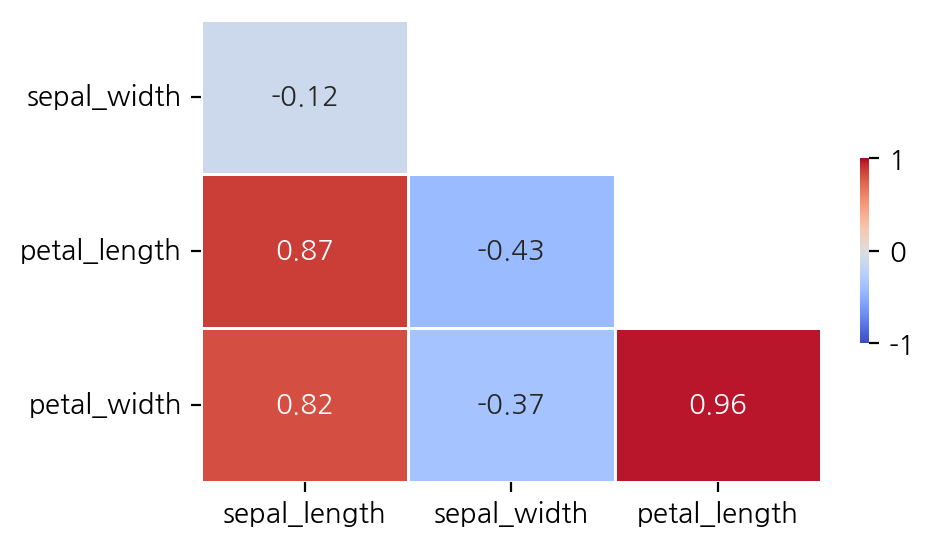

In [ ]:
# 최종 삼각 히트맵
sns.heatmap(corr_new, annot=True, cmap='coolwarm', mask=new_mask,
            vmin=-1, vmax=1,
            cbar_kws={'shrink': .4},
            lw=.5)

plt.show()

### iris pairplot

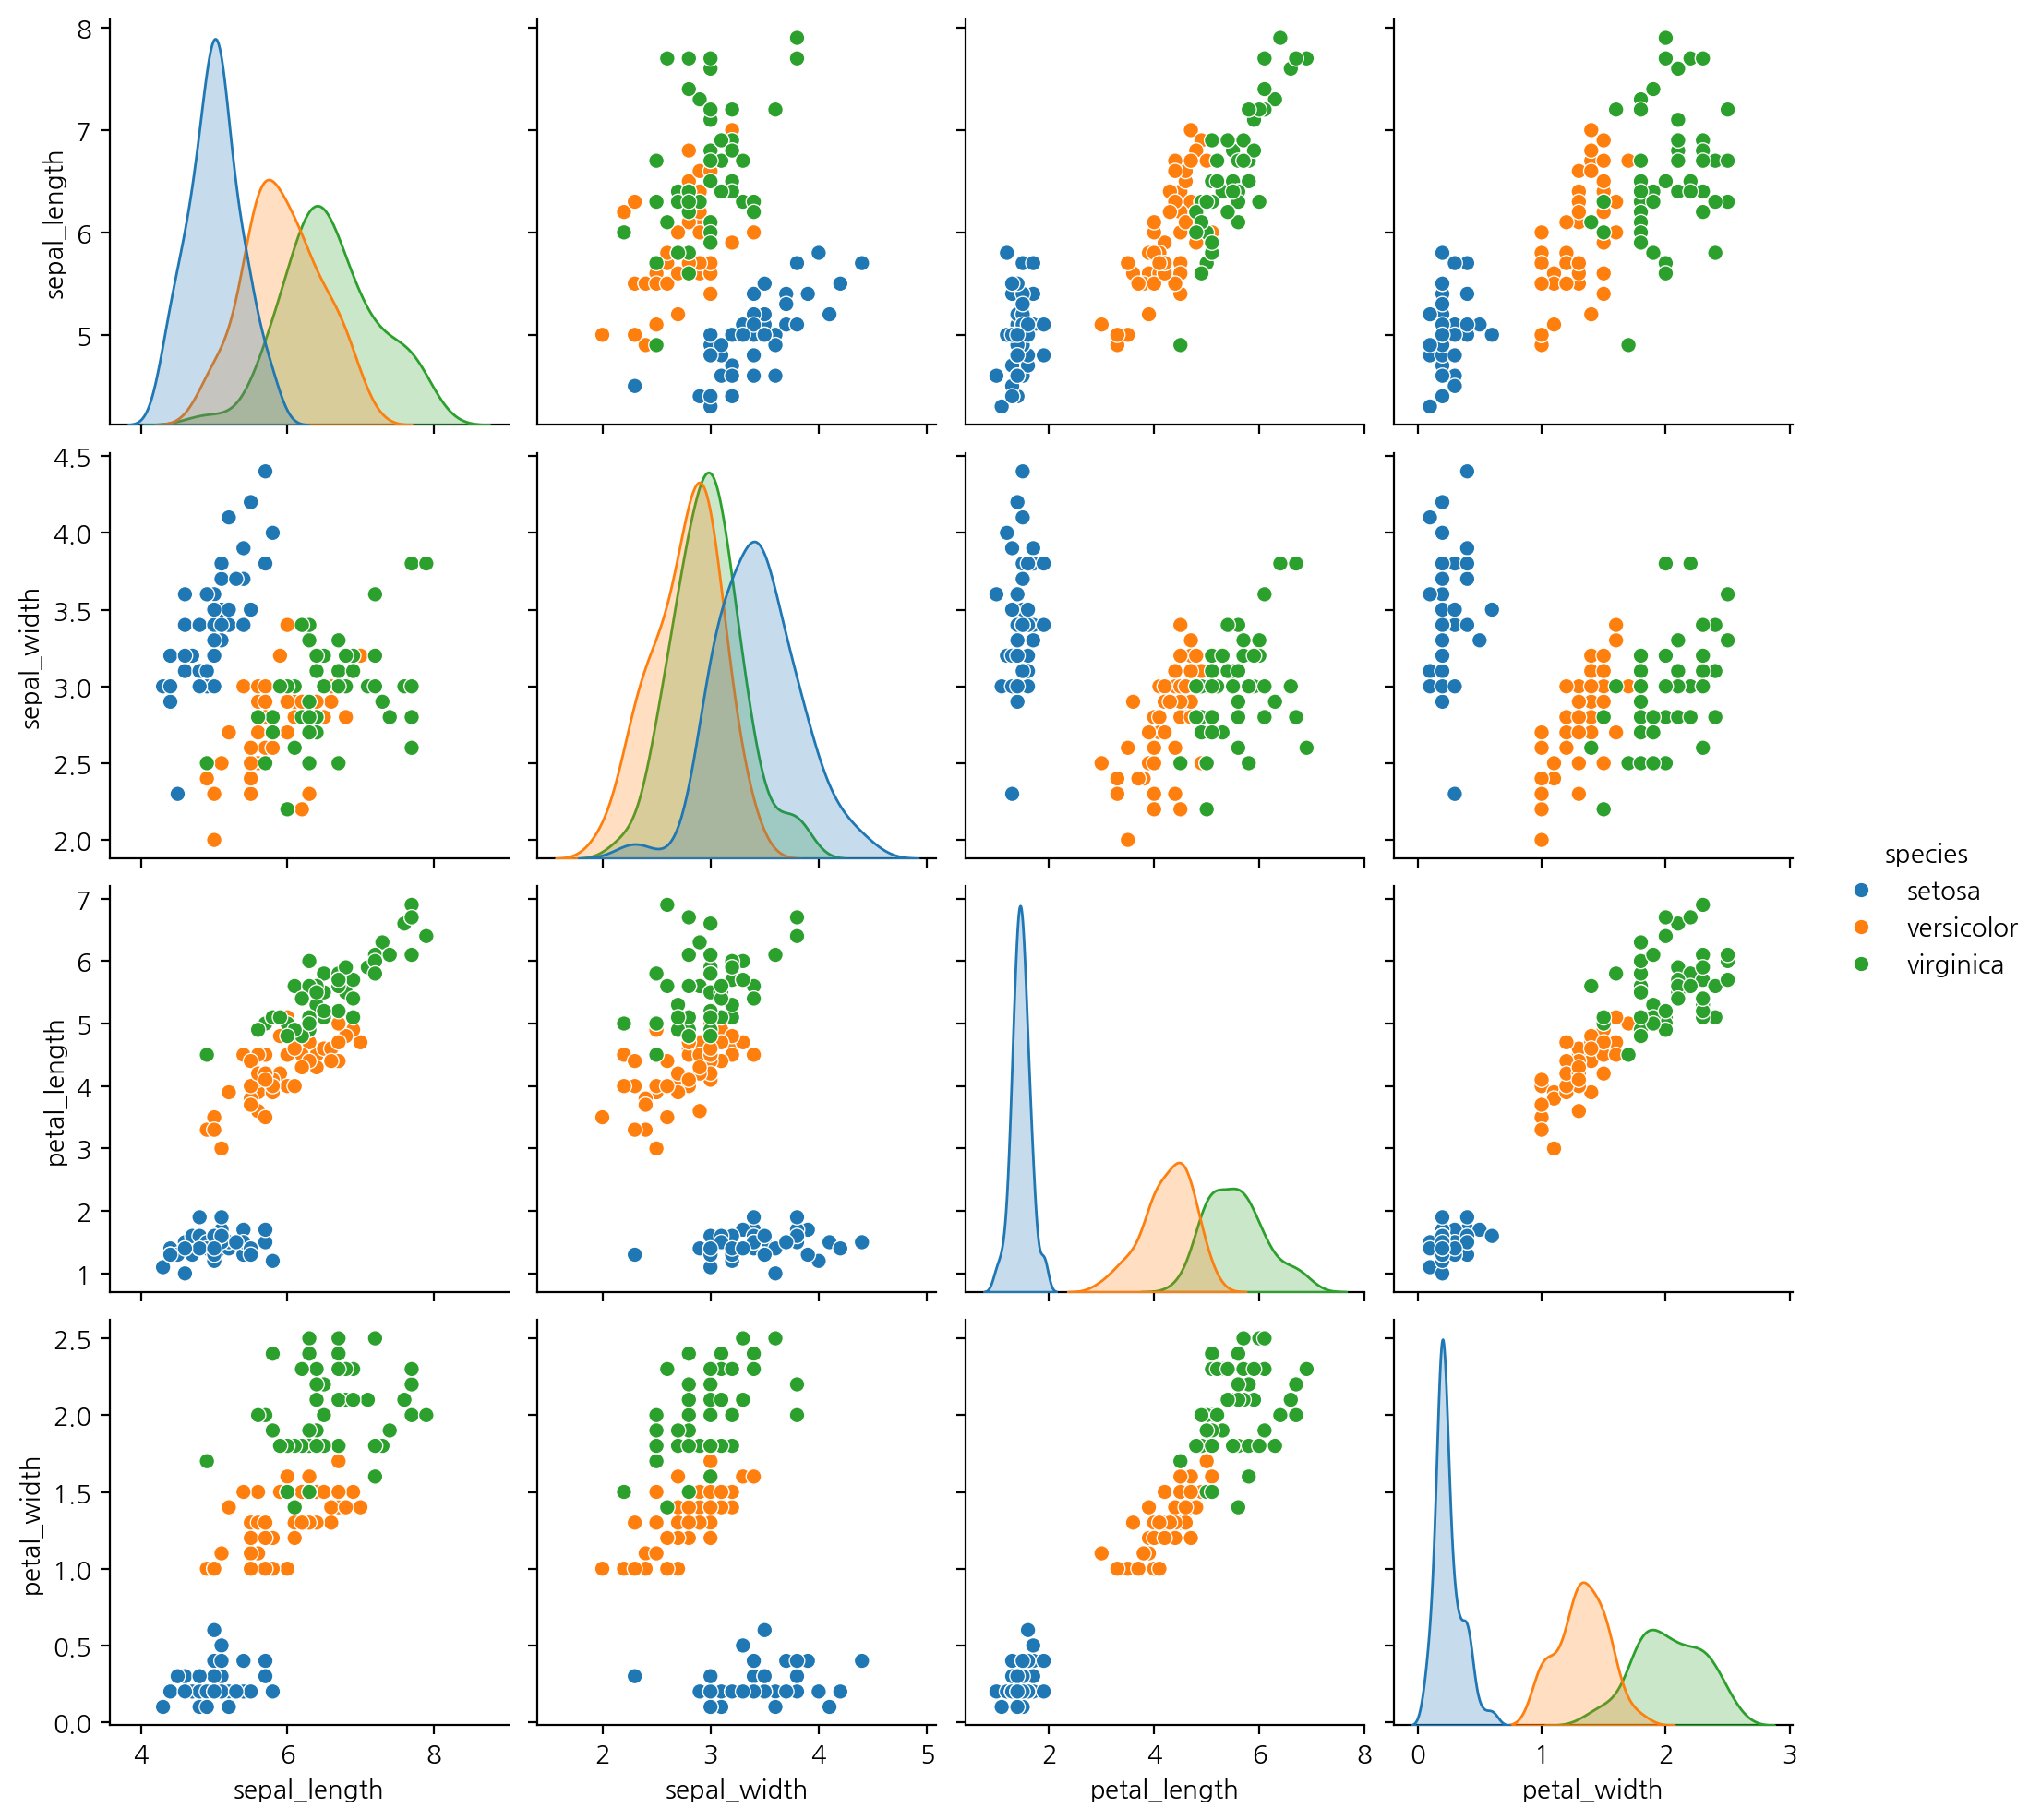

In [ ]:
# 품종별 pairplot
sns.pairplot(iris, hue='species')
plt.show()

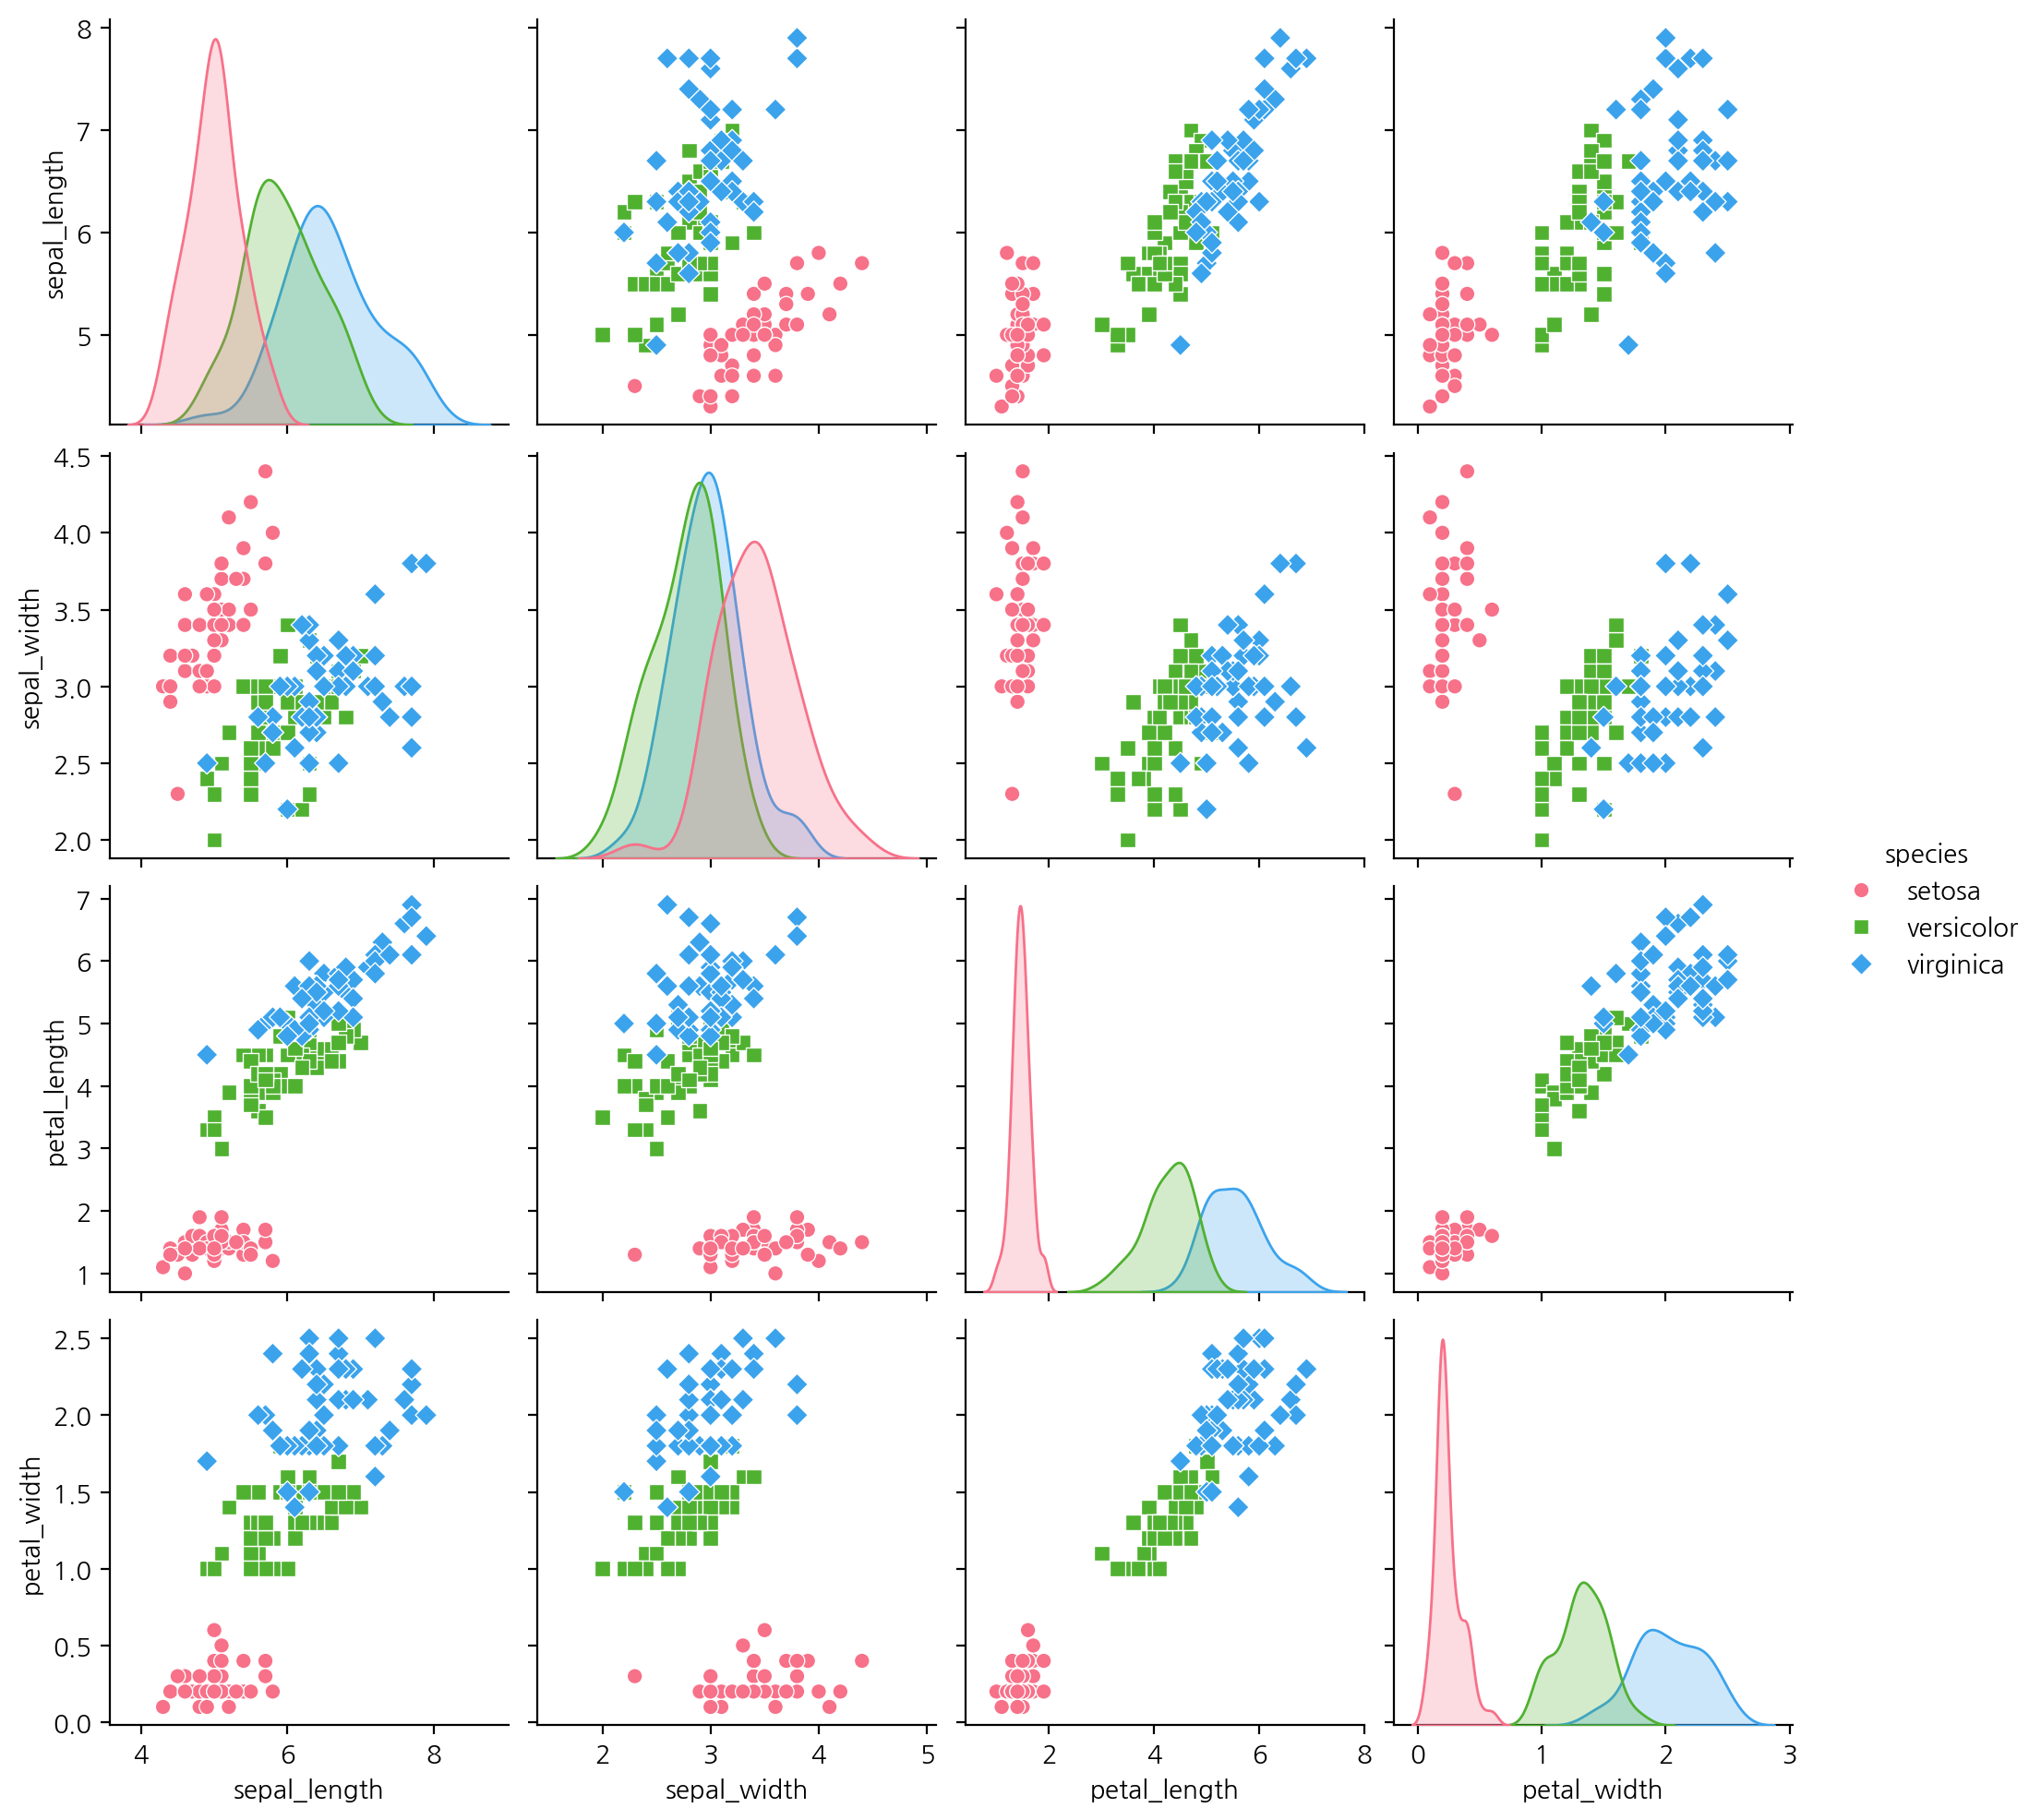

In [ ]:
# 색상과 마커 지정
sns.pairplot(iris, hue='species',
             palette="husl",
             markers=['o', 's', 'D'])
plt.show()

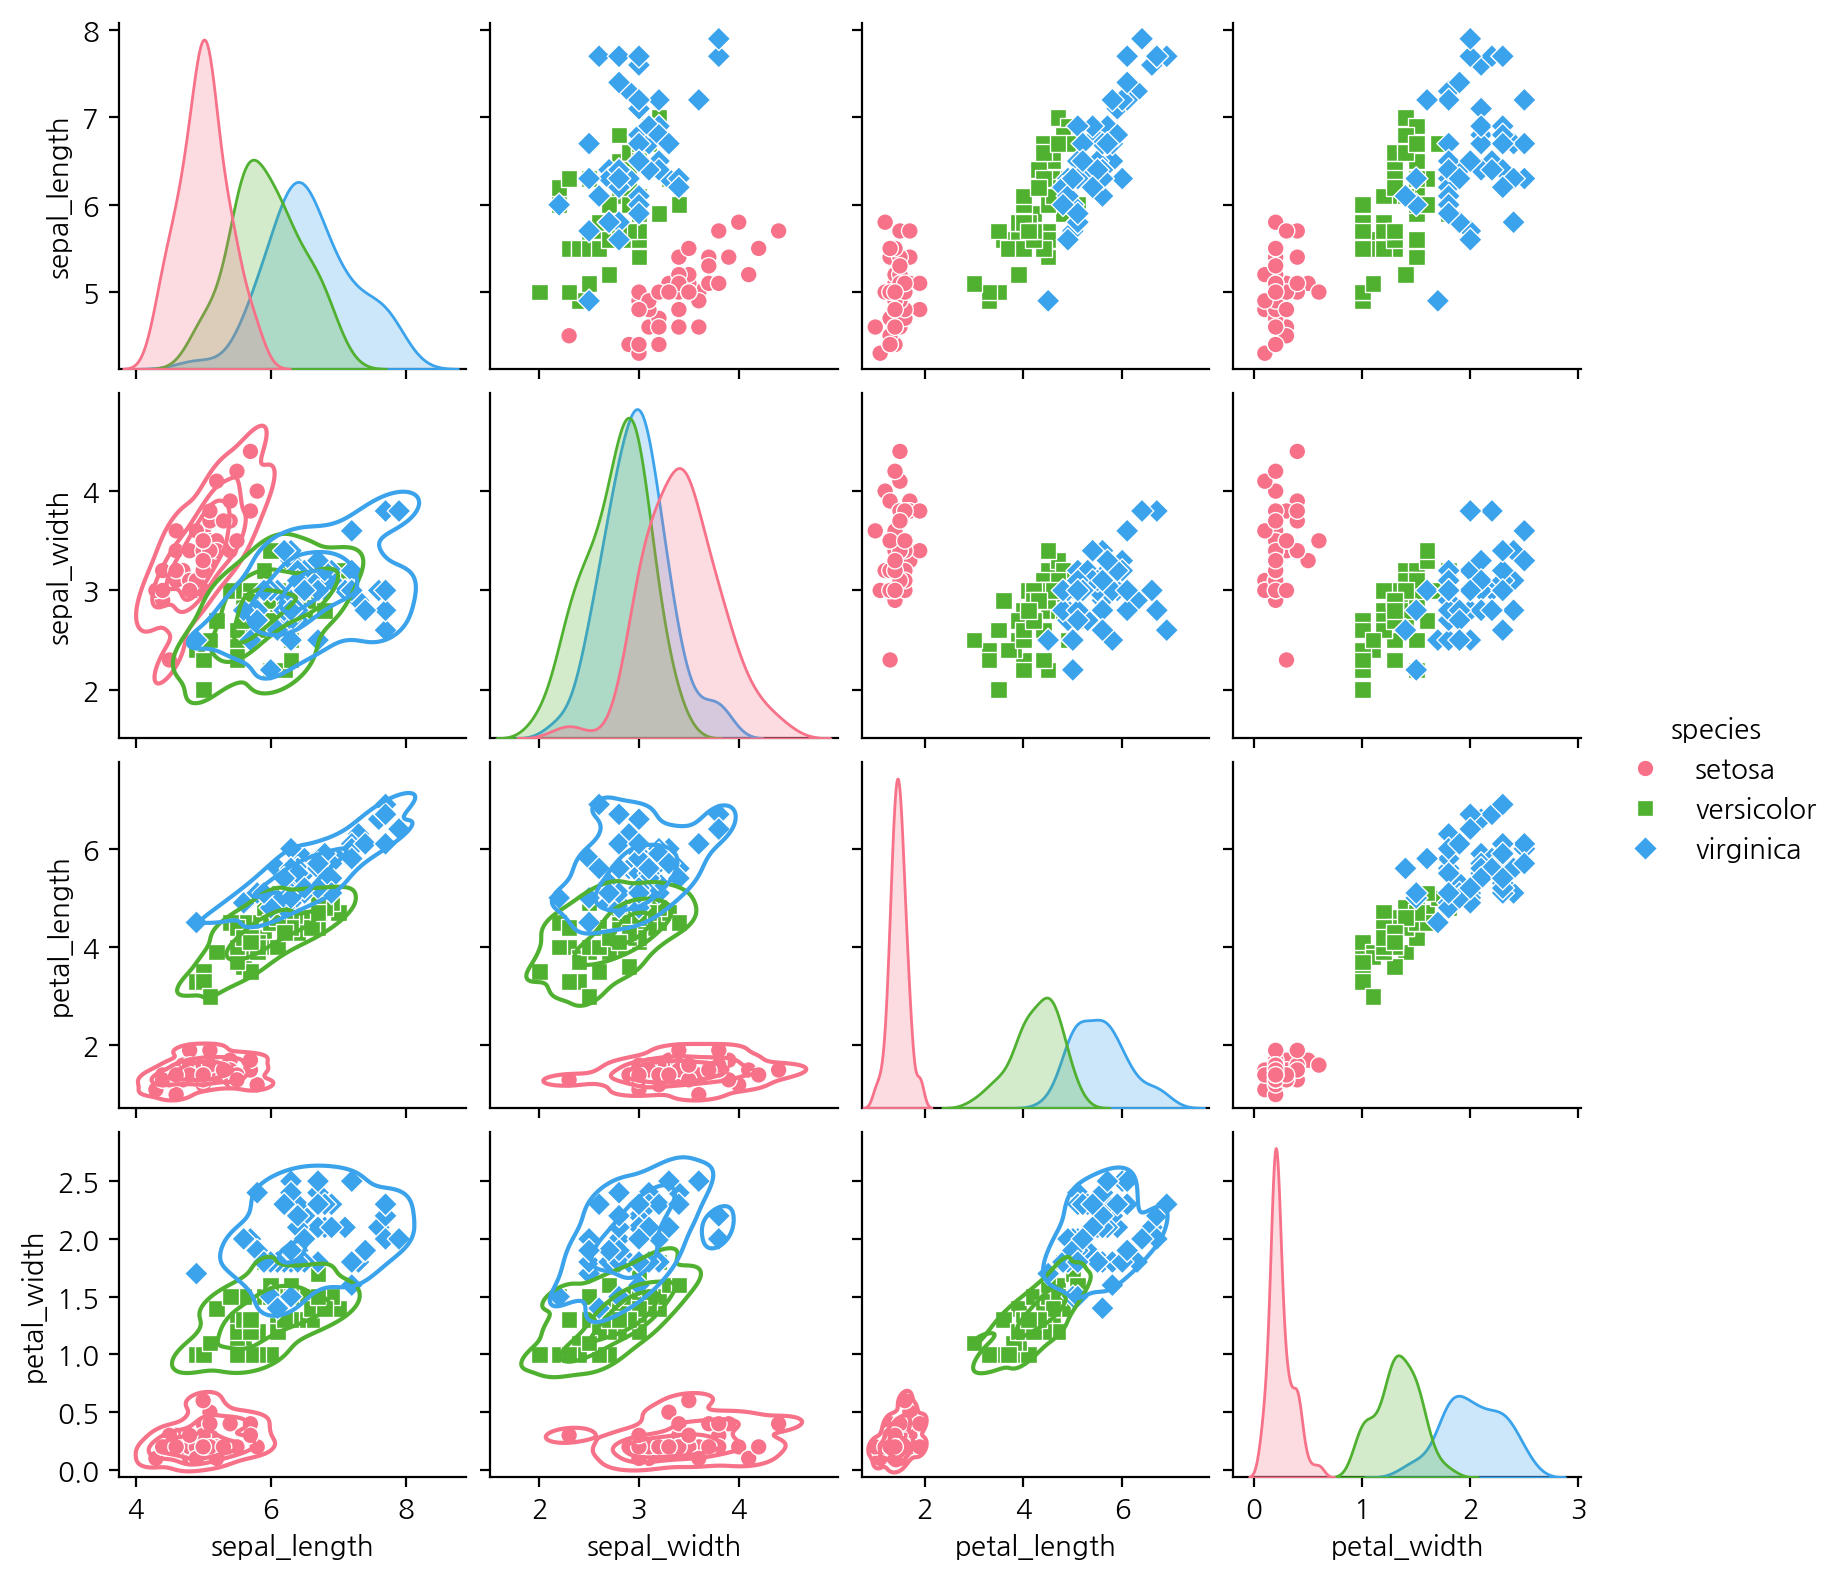

In [ ]:
# PairGrid 객체 활용
g = sns.pairplot(iris, hue="species",
                 palette="husl",
                 height=2.0,
                 markers=["o", "s", "D"])

g.map_lower(sns.kdeplot, levels=4, color=".2")
plt.show()

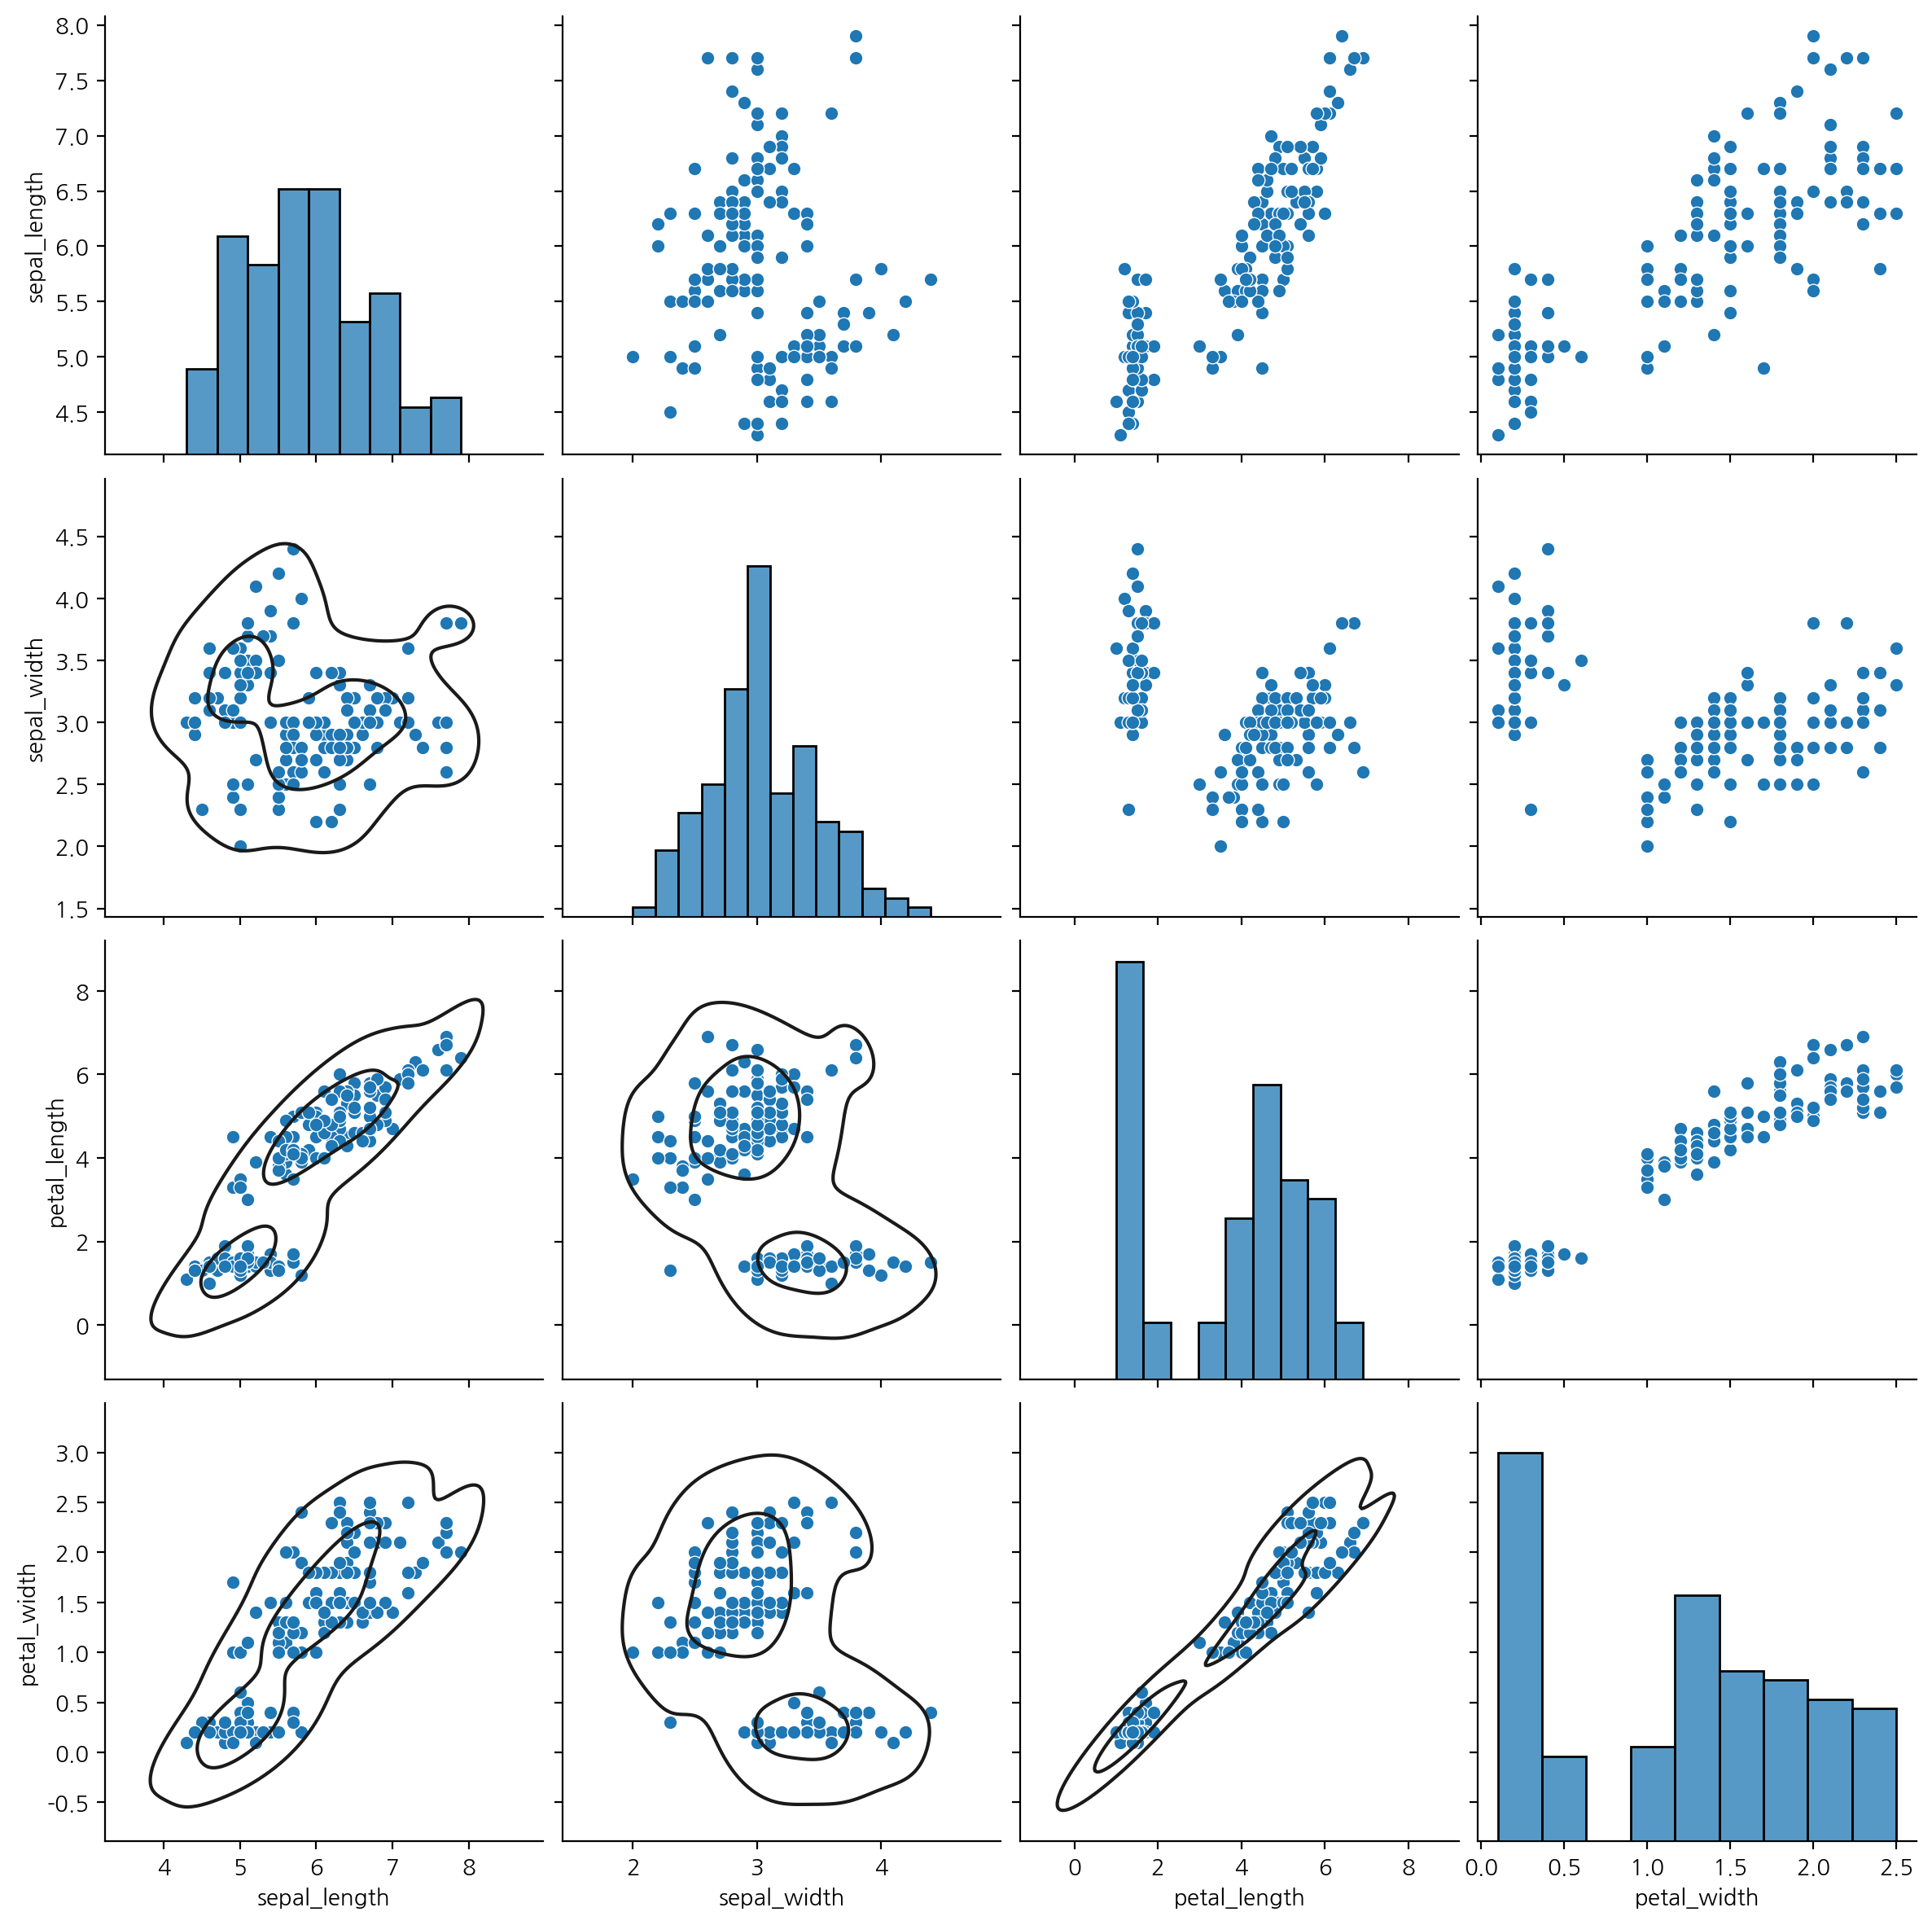

In [ ]:
# hue 없이 kdeplot 추가
g = sns.pairplot(iris, height=3)
g.map_lower(sns.kdeplot, levels=3, color=".1")
plt.show()